# AttributionMethods: ODAM, CAM, IG на model.22

Сравниваем несколько detector-target attribution методов для `class_only` цели на `model.22`:

- `segmentig`: существующий SegmentIG `[0;0.1]`;
- `odam`: Grad-ODAM в формуле официальной реализации `ReLU(sum_c grad * activation)`;
- `layercam`: выбранный CAM-family baseline, spatial-sensitive без global average pooling;
- `full_layerig`: полный Layer IG / IG-ODAM-style baseline на интервале `[0;1]`.

Все scalar-метрики считаются тем же способом, что в `BinMetrics`: alignment/top-k/product/bin/handcrafted признаки против `Δ = activation(patched)-activation(clean)`. Для каждого метода строятся таблицы и графики для binary success/fail classification и для регрессионной похожести с `drop`.

## Почему именно LayerCAM из CAM-family

Обычный Grad-CAM и Grad-CAM++ сворачивают градиенты в channel weights через spatial pooling. Для object detection это часто размывает instance-specific сигнал и хуже подходит к нашей задаче, где патч распространяется по конкретным spatial позициям и каналам. `LayerCAM` использует positive gradients локально, то есть сохраняет spatial sensitivity на `model.22`. Поэтому он ближе к нейронным метрикам `C x H x W`, чем pooled Grad-CAM.

## Setup и общий cache

In [1]:
from pathlib import Path
import os
import sys
import tempfile

_plot_cache = Path(tempfile.gettempdir()) / "patch_success_plot_cache"
_mpl_cache = _plot_cache / "matplotlib"
_xdg_cache = _plot_cache / "xdg"
_mpl_cache.mkdir(parents=True, exist_ok=True)
_xdg_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_cache))
os.environ.setdefault("XDG_CACHE_HOME", str(_xdg_cache))

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from patch_success_analysis.notebook_setup import ensure_new_experiments_cwd, make_coco_people_patch_success_experiment
from patch_success_analysis import attribution_suite, regression_metrics

cwd = ensure_new_experiments_cwd()
layer_name = "model.22"
attack_config, config, exp = make_coco_people_patch_success_experiment(
    target_layer=layer_name,
    n_steps=8,
    alpha_batch_size=8,
    metrics_batch_size=256,
)
assert config.target_mode == "class_only"
cache = exp.build_or_load_cache(force=False)
print(f"cwd={cwd}")
print(f"device={attack_config.device}")
print(f"target_layer={config.target_layer}, target_mode={config.target_mode}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(cache.to_summary())

cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
device=mps
target_layer=model.22, target_mode=class_only
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
{'cache_key': 'e91cdfc4a2c4e20d', 'config': {'dataset_path': ['../datasets/COCO_people'], 'patch_path': '../data/patch.png', 'model_path': 'yolo11s.pt', 'output_dir': 'new_experiments/outputs/patch_success_analysis', 'imgsz': 640, 'device': 'mps', 'target_class_name': 'person', 'conf': 0.01, 'success_thresh': 0.3, 'seed': 17, 'pool_size': 7200, 'n_success': 3000, 'n_fail': 3000, 'apply_patch_after_letterbox': True, 'patch_xy': (0, 0)}, 'balanced_total': 5650, 'balanced_success': 3000, 'balanced_fail': 2650, 'pool_total': 7200, 'pool_success': 4550, 'pool_fail': 2650, 'pool_failed_images': 0, 'failed_paths': []}


## Расчёт / загрузка method suite

In [2]:
force_attribution_method_suite_recompute = False
max_examples = None  # поставь меньше для smoke-run, None использует весь attack cache
top_percent = 5.0

suite = attribution_suite.compute_or_load_attribution_method_suite(
    exp,
    layer_name=layer_name,
    max_examples=max_examples,
    top_percent=top_percent,
    force=force_attribution_method_suite_recompute,
)
rows_df = pd.DataFrame(suite["rows"])
all_quality = suite["all_quality"]
all_regression = suite["all_regression"]

print(f"suite cache: {suite['cache_path']}")
print(f"loaded_from_cache={suite['loaded_from_cache']}")
print(f"rows={len(rows_df)}, skipped={len(suite.get('skipped', []))}")
display(rows_df[["path", "success", "drop", "conf_clean", "conf_patch", "layer_maps_loaded_from_cache", "method_maps_loaded_from_cache"]].head())

/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/patch_success_analysis/attribution_suite.py:306: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'new_experiments/outputs/patch_success_analysis/figures/attribution_methods/segmentig_metric_segmentig_hand_rank_ratio_top5_top25.png' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  quality.loc[quality["metric"] == name, "figure_path"] = str(path)
/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/patch_success_analysis/attribution_suite.py:306: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'new_experiments/outputs/patch_success_analysis/figures/attribution_methods/odam_metric_odam_align_cosine.png' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  quality.loc[quality["metric"] == n

suite cache: new_experiments/outputs/patch_success_analysis/cache/attribution_method_suite_92d6f1c6d9645614.pkl
loaded_from_cache=False
rows=5646, skipped=4


,path,success,drop,conf_clean,conf_patch,layer_maps_loaded_from_cache,method_maps_loaded_from_cache
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,True,False
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576,True,False
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.876263,0.000000,True,False
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.926853,0.557409,True,False
4,../datasets/COCO_people/04480_train2017_image1...,False,0.004722,0.900169,0.895448,True,False


## Общая сводка методов

,method,classification_metrics,regression_metrics,best_accuracy,best_roc_auc,best_regression_main_score,best_abs_spearman
2,layercam,203,203,0.673220,0.717315,0.402989,0.353633
1,odam,203,203,0.659051,0.698937,0.386759,0.341009
0,segmentig,203,203,0.640985,0.669002,0.360788,0.274222
3,full_layerig,203,203,0.637442,0.675928,0.363994,0.270477


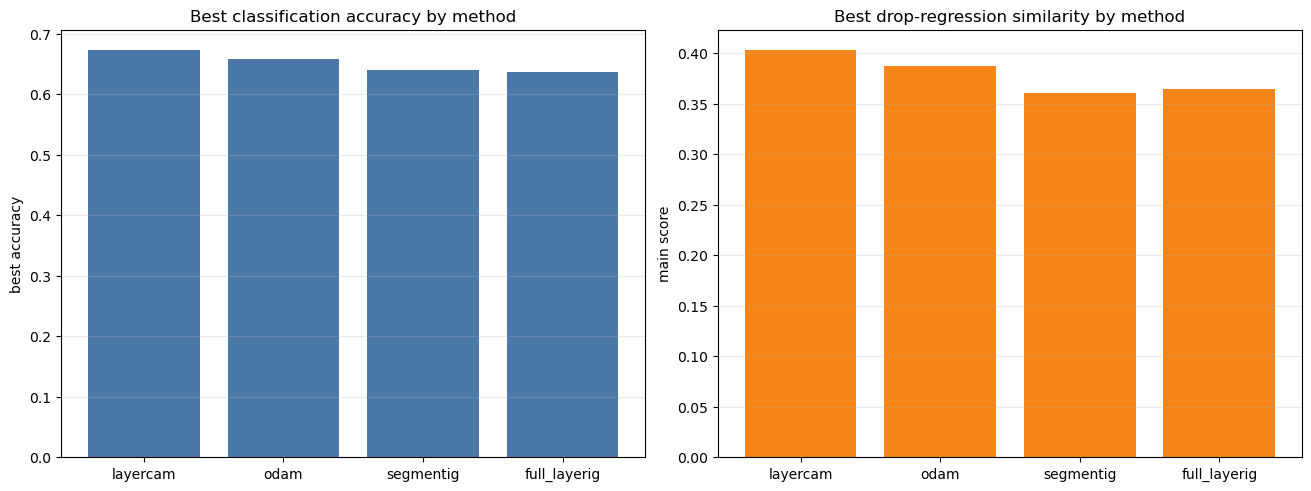

In [3]:
method_summary_rows = []
for method in attribution_suite.METHODS:
    q = suite["quality_by_method"][method]
    r = suite["regression_by_method"][method]
    method_summary_rows.append({
        "method": method,
        "classification_metrics": len(q),
        "regression_metrics": len(r),
        "best_accuracy": float(q["best_accuracy"].max()) if len(q) else float("nan"),
        "best_roc_auc": float(q["roc_auc"].max()) if len(q) else float("nan"),
        "best_regression_main_score": float(r["main_score"].max()) if len(r) else float("nan"),
        "best_abs_spearman": float(r["abs_spearman"].max()) if len(r) else float("nan"),
    })
method_summary_df = pd.DataFrame(method_summary_rows).sort_values("best_accuracy", ascending=False)
display(method_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].bar(method_summary_df["method"], method_summary_df["best_accuracy"], color="#4C78A8")
axes[0].set_title("Best classification accuracy by method")
axes[0].set_ylabel("best accuracy")
axes[0].grid(axis="y", alpha=0.25)
axes[1].bar(method_summary_df["method"], method_summary_df["best_regression_main_score"], color="#F58518")
axes[1].set_title("Best drop-regression similarity by method")
axes[1].set_ylabel("main score")
axes[1].grid(axis="y", alpha=0.25)
plt.show()

## SegmentIG

,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
0,segmentig_hand_rank_ratio_top5_top25,0.669002,0.640985,0.228035,1,new_experiments/outputs/patch_success_analysis...
1,segmentig_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
2,segmentig_hand_overlap_top5_delta_in_topA,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
3,segmentig_hand_rank_top5_delta_frac,0.667376,0.639391,0.056406,1,new_experiments/outputs/patch_success_analysis...
4,segmentig_align_top_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
5,segmentig_hand_overlap_top5_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
6,segmentig_hand_rank_top6_delta_frac,0.666895,0.637442,0.064968,1,new_experiments/outputs/patch_success_analysis...
7,segmentig_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,new_experiments/outputs/patch_success_analysis...
8,segmentig_hand_overlap_top10_jaccard,0.659817,0.636026,0.054759,1,new_experiments/outputs/patch_success_analysis...
9,segmentig_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,new_experiments/outputs/patch_success_analysis...


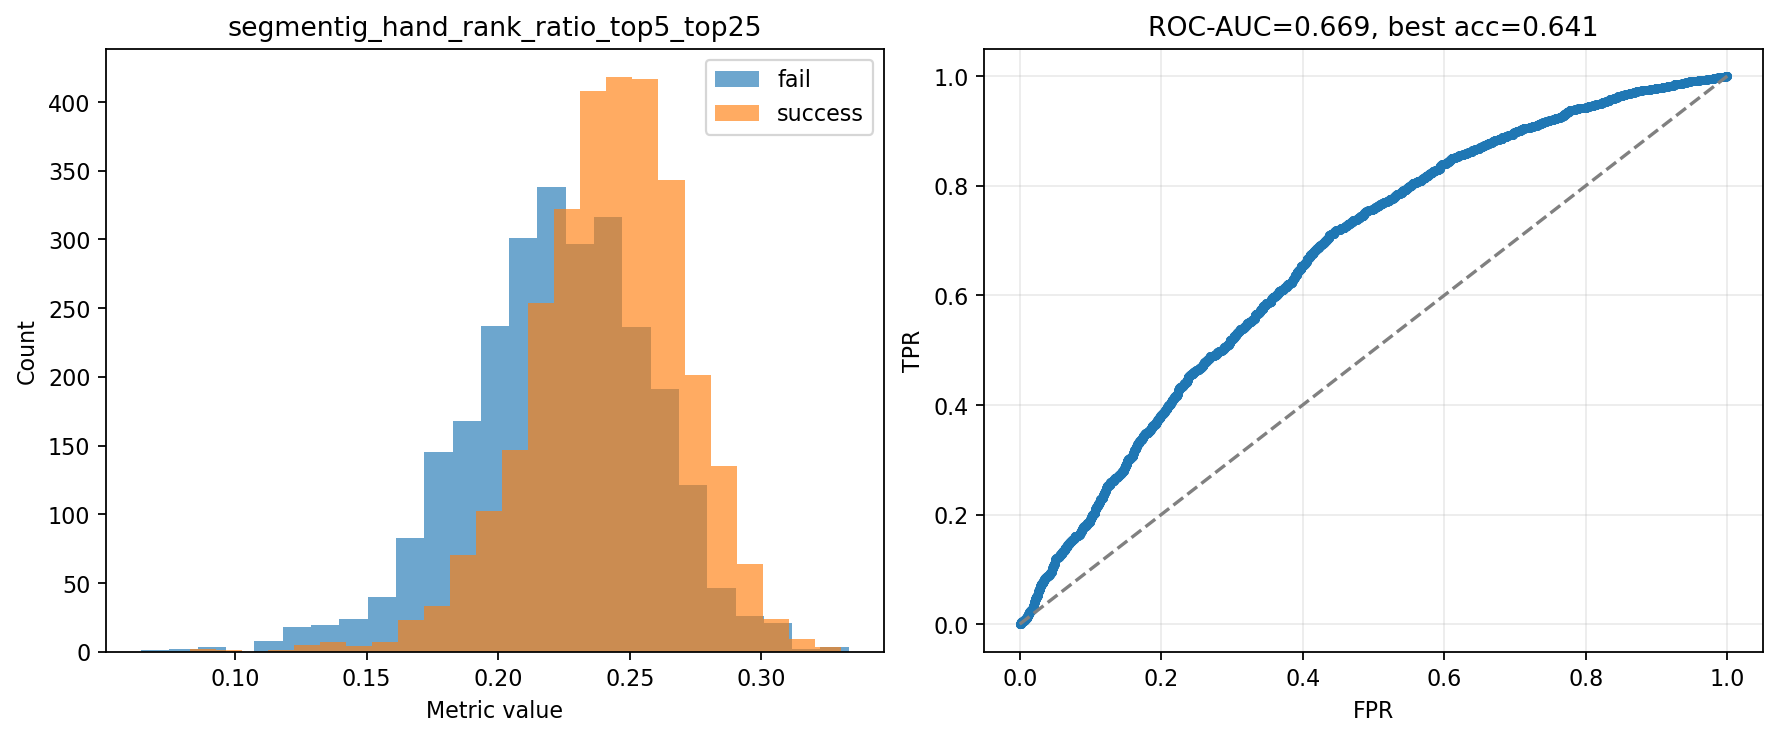

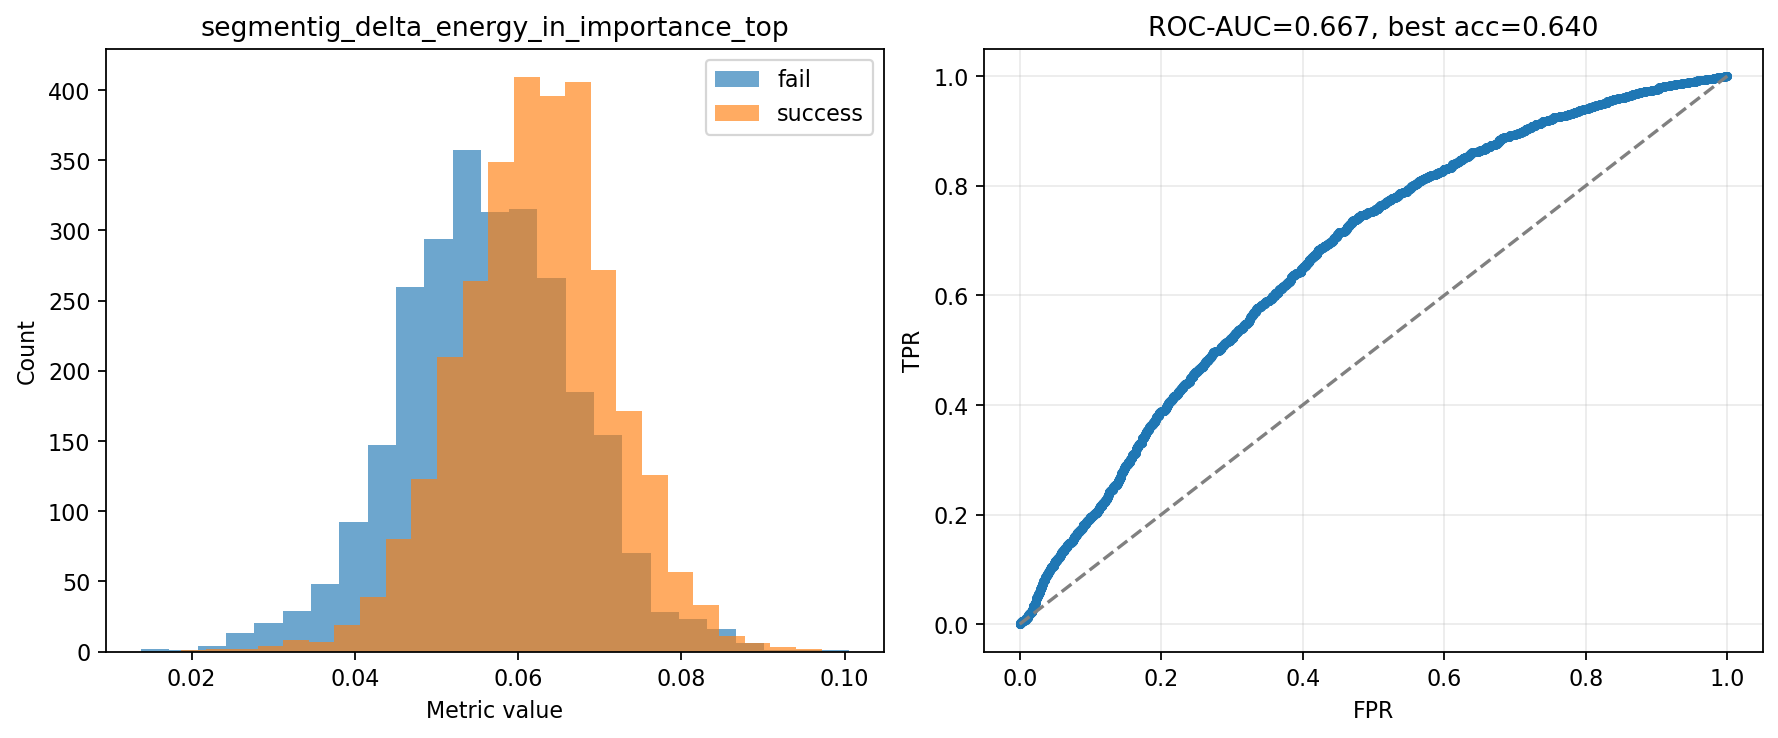

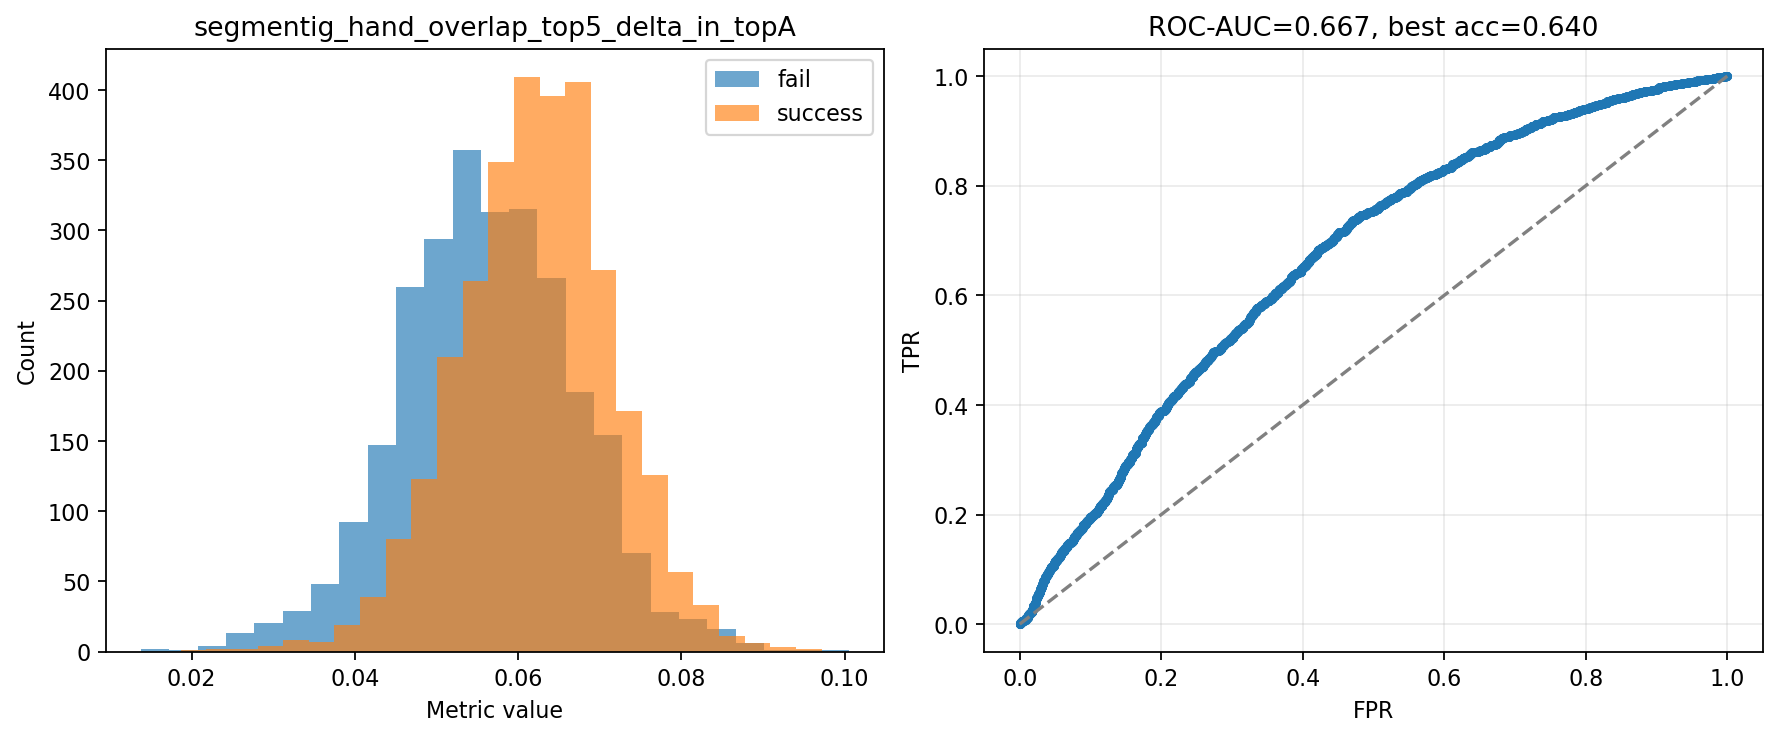

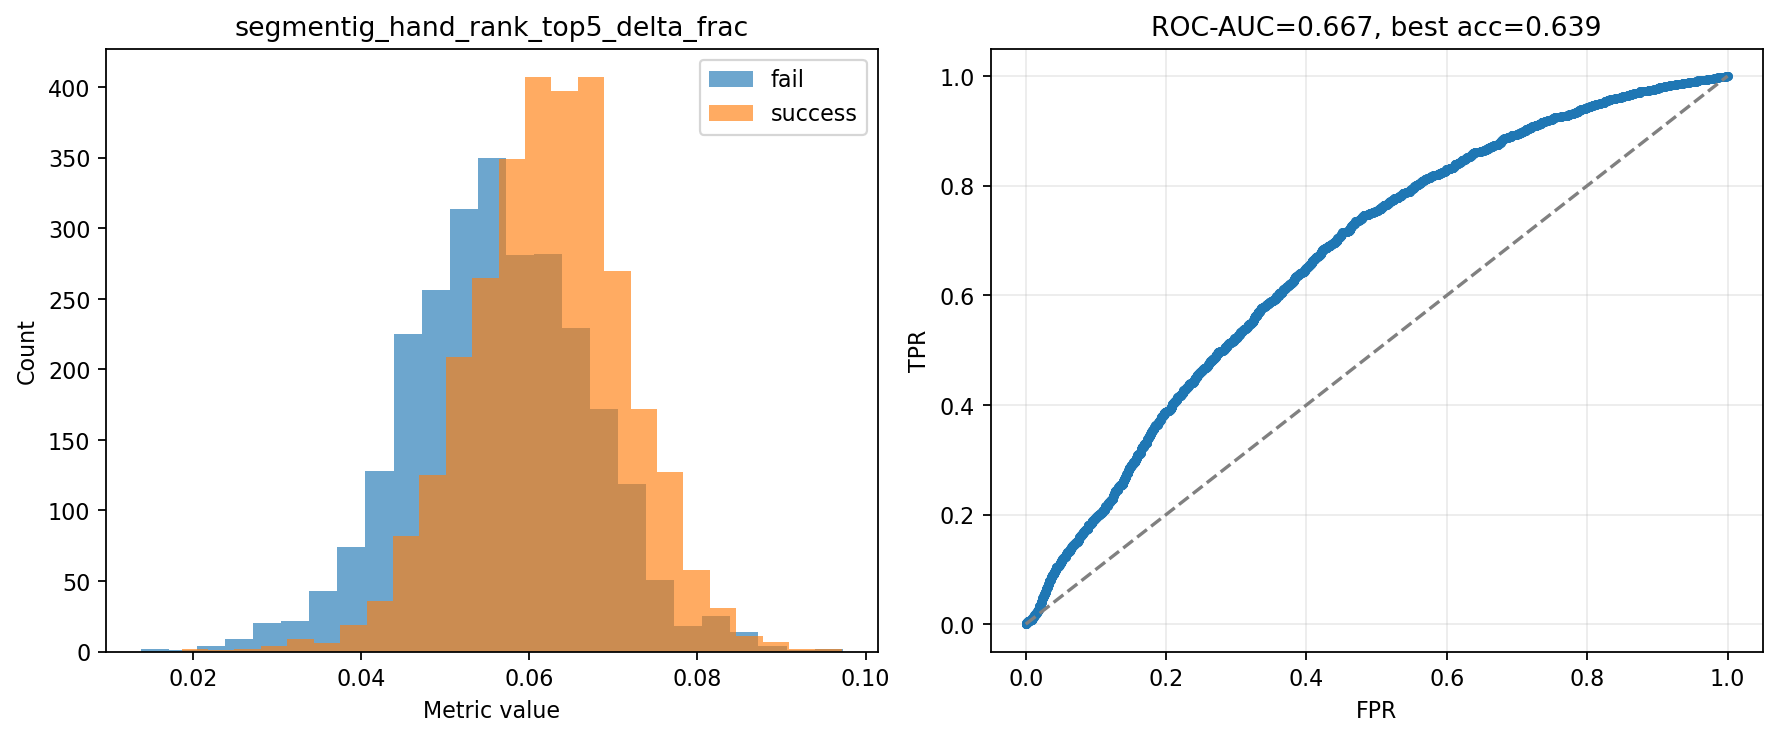

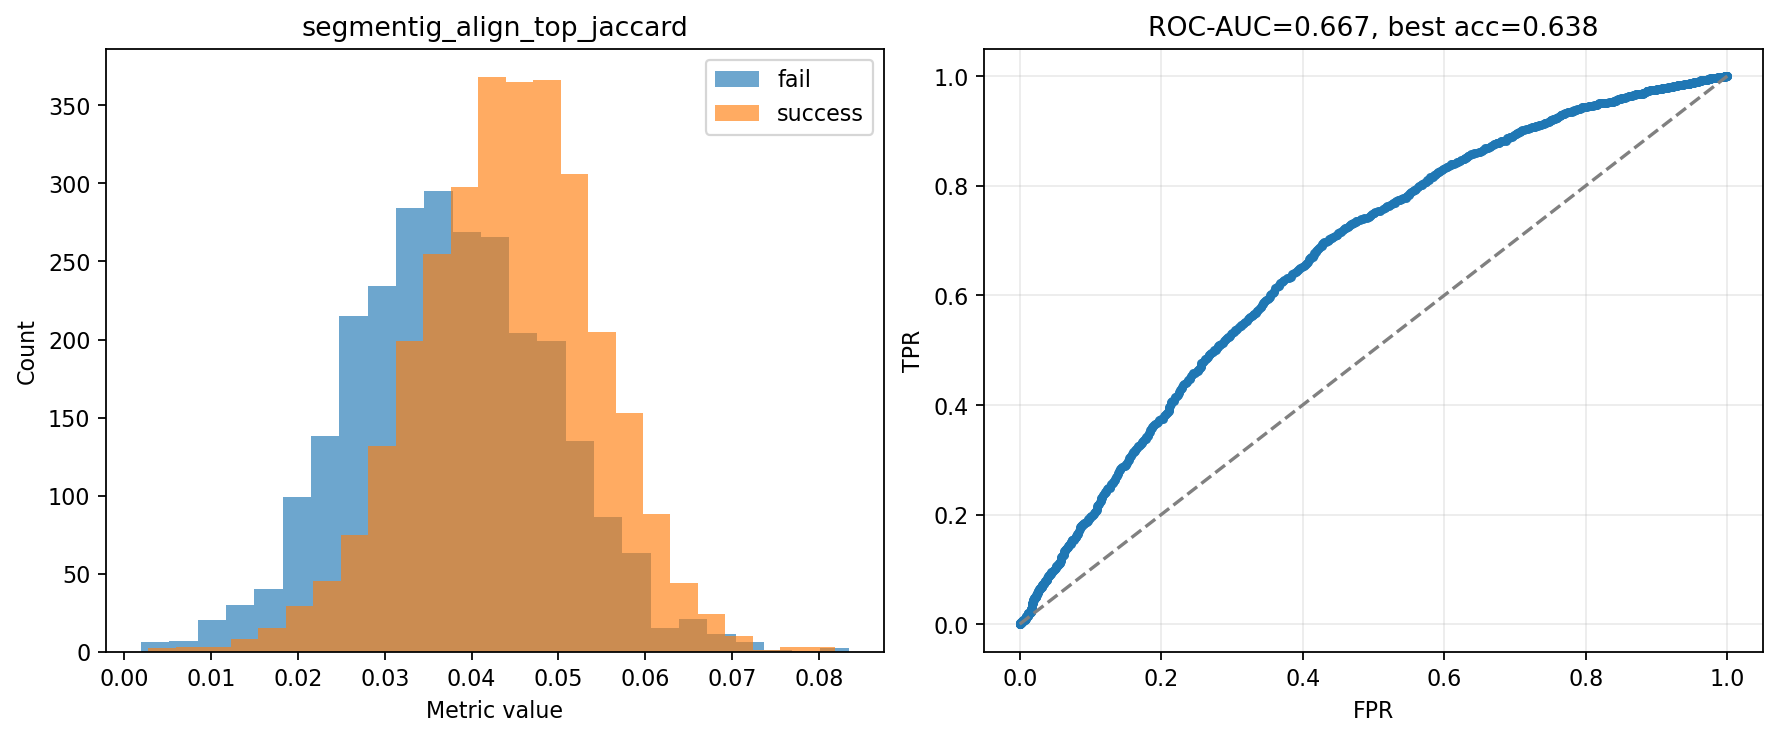

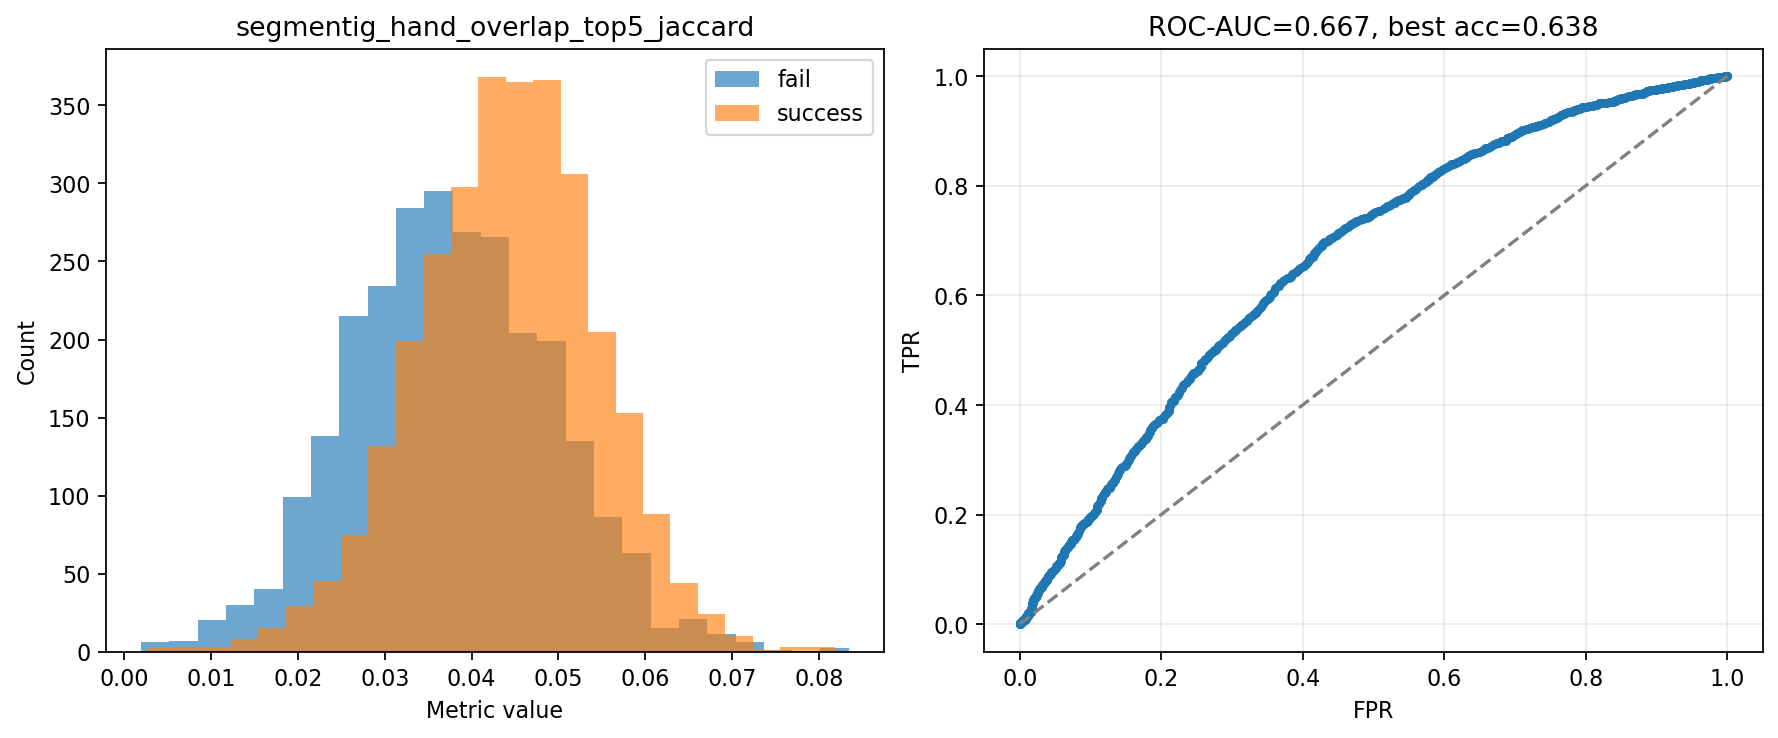

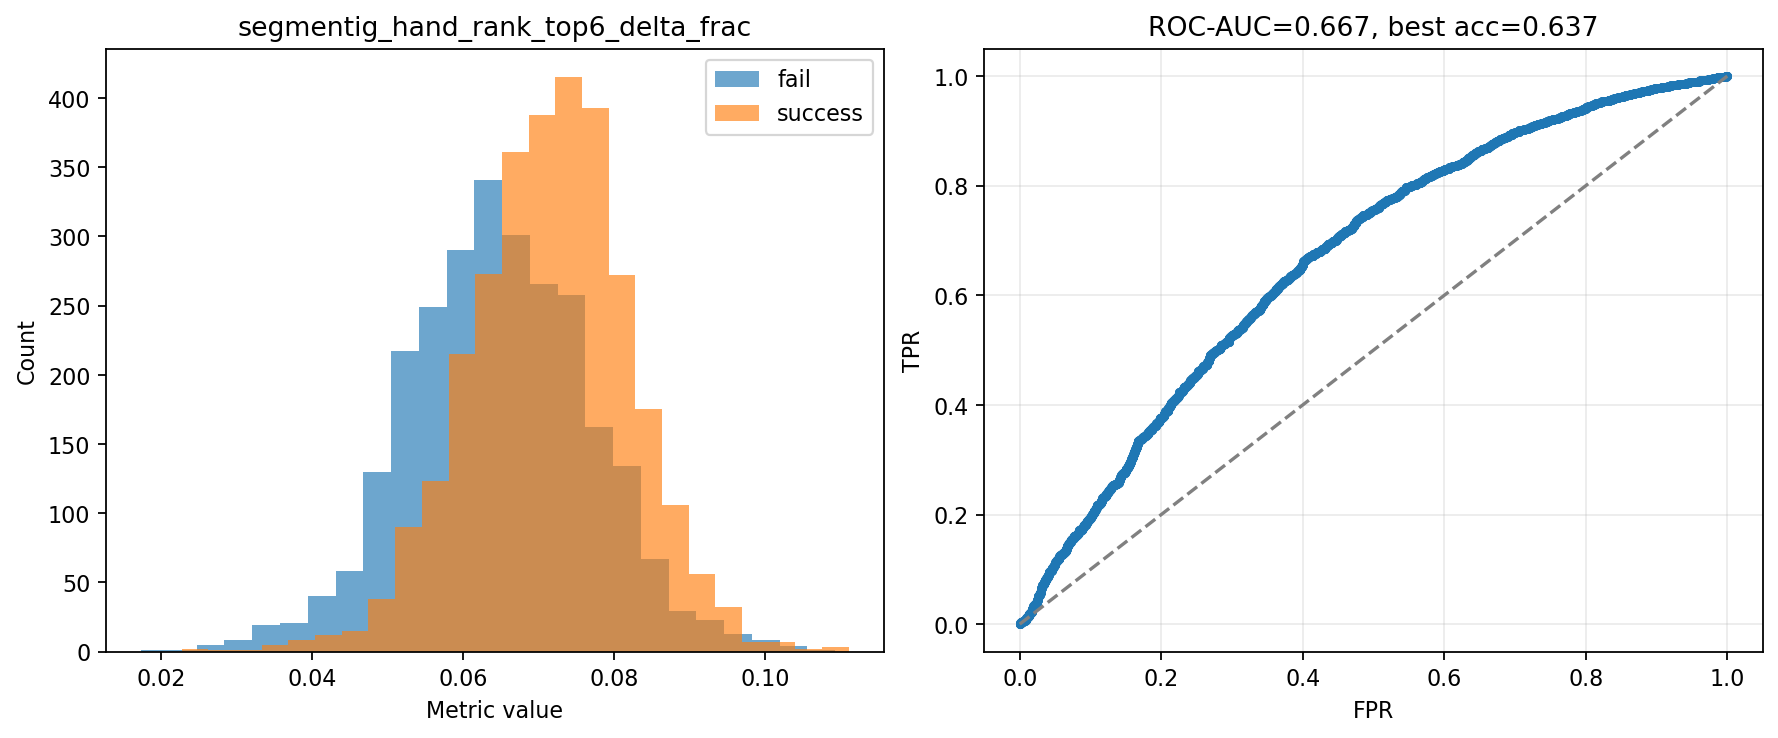

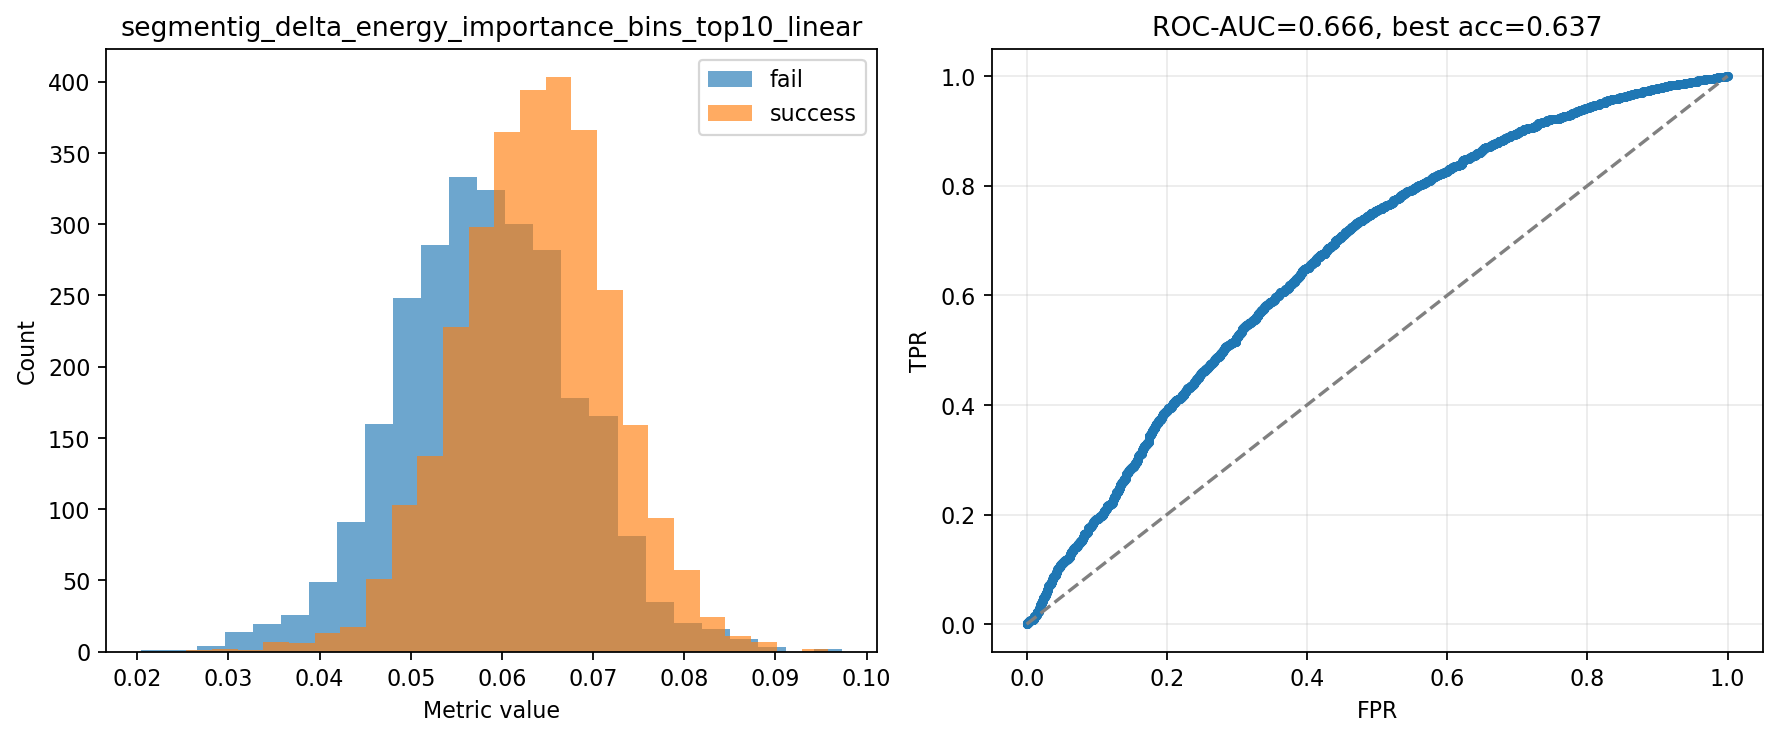

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,segmentig_delta_energy_importance_bins_top10_exp,5646,1.0,0.261860,0.267941,0.187063,0.261860,0.267941,0.187063,0.129218,...,0.339241,12.447714,-0.069903,0.068570,0.285943,0.327375,0.965106,0.988394,0.508878,0.360788
1,segmentig_hand_rank_top10_delta_frac,5646,1.0,0.254346,0.260877,0.181974,0.254346,0.260877,0.181974,0.125461,...,0.339241,7.383584,-0.329880,0.064692,0.286598,0.328056,0.967113,0.959654,0.508359,0.352841
2,segmentig_delta_energy_importance_bins_top50_exp,5646,1.0,0.245350,0.254586,0.176419,0.245350,0.254586,0.176419,0.127522,...,0.339241,8.927102,-0.899512,0.060197,0.288132,0.328843,0.969434,0.975419,0.507760,0.350572
3,segmentig_hand_rank_top6_delta_frac,5646,1.0,0.261970,0.269135,0.187712,0.261970,0.269135,0.187712,0.118595,...,0.339241,7.531546,-0.082172,0.068628,0.285544,0.327365,0.965076,0.907141,0.508886,0.350553
4,segmentig_hand_overlap_top10_delta_in_topA,5646,1.0,0.244556,0.249923,0.173529,0.244556,0.249923,0.173529,0.127679,...,0.339241,7.001472,-0.299982,0.059808,0.288078,0.328911,0.969635,0.976624,0.507708,0.349176
5,segmentig_delta_energy_importance_bins_top10_l...,5646,1.0,0.261631,0.268203,0.187147,0.261631,0.268203,0.187147,0.117811,...,0.339241,9.346709,-0.138714,0.068451,0.285642,0.327396,0.965168,0.901141,0.508862,0.348829
6,segmentig_delta_energy_importance_bins_top25_exp,5646,1.0,0.257021,0.264682,0.184237,0.257021,0.264682,0.184237,0.117433,...,0.339241,9.747040,-0.347488,0.066060,0.286386,0.327816,0.966406,0.898247,0.508542,0.345999
7,segmentig_hand_overlap_top10_jaccard,5646,1.0,0.247775,0.253210,0.176385,0.247775,0.253210,0.176385,0.121977,...,0.339241,9.332327,-0.108370,0.061392,0.287426,0.328634,0.968818,0.933010,0.507919,0.345790
8,segmentig_hand_rank_ratio_top5_top25,5646,1.0,0.268389,0.269266,0.188152,0.268389,0.269266,0.188152,0.112478,...,0.339241,2.709007,-0.197742,0.072033,0.284622,0.326766,0.963311,0.860348,0.509344,0.345222
9,segmentig_delta_energy_in_importance_top,5646,1.0,0.263398,0.269800,0.187943,0.263398,0.269800,0.187943,0.111887,...,0.339241,8.503631,-0.072635,0.069379,0.285466,0.327233,0.964687,0.855830,0.508987,0.343551


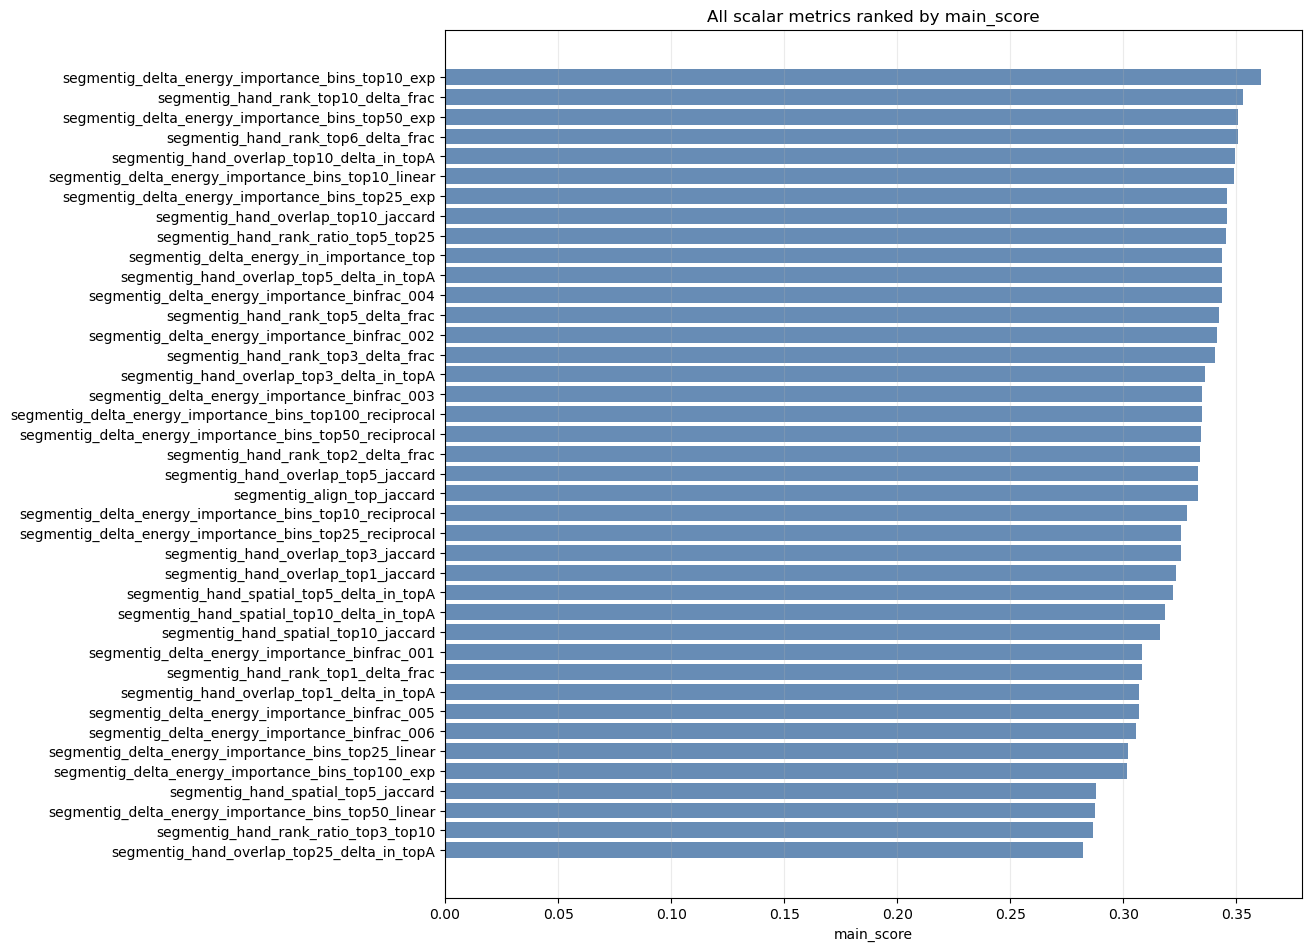

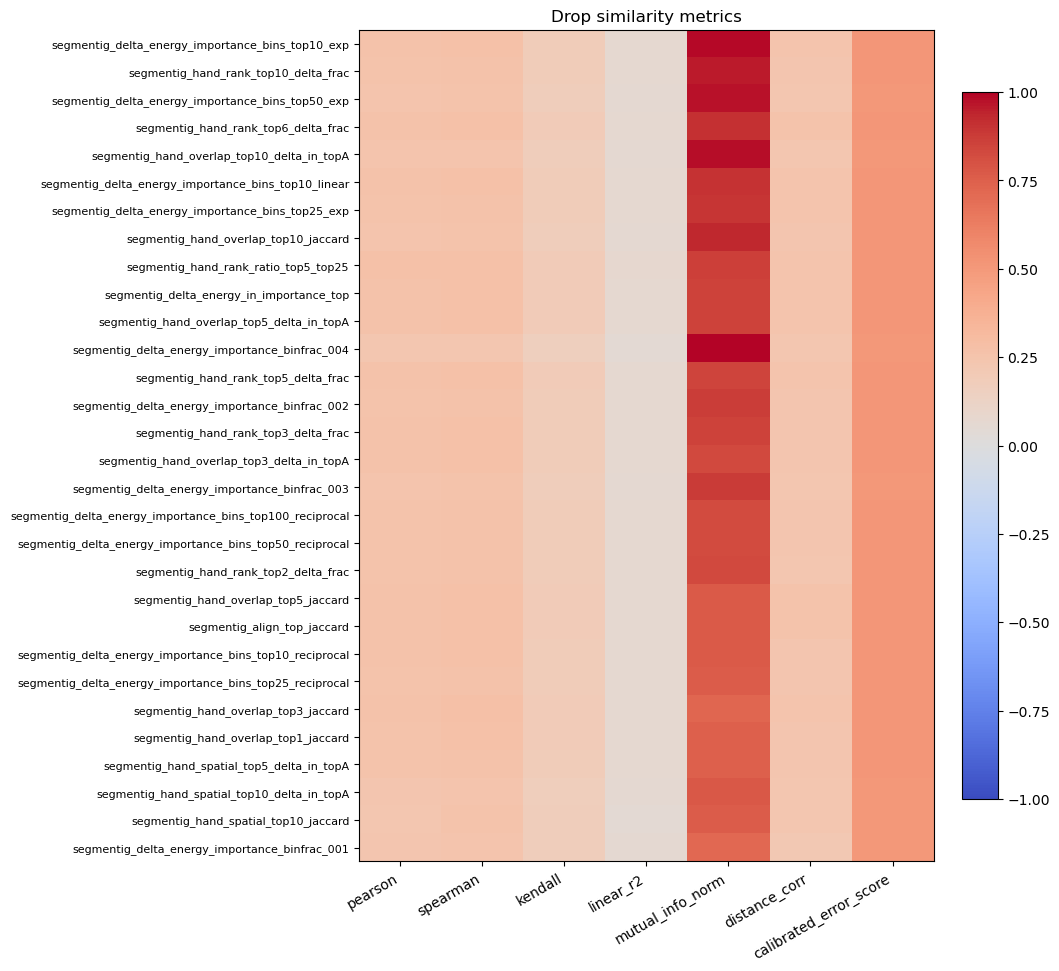

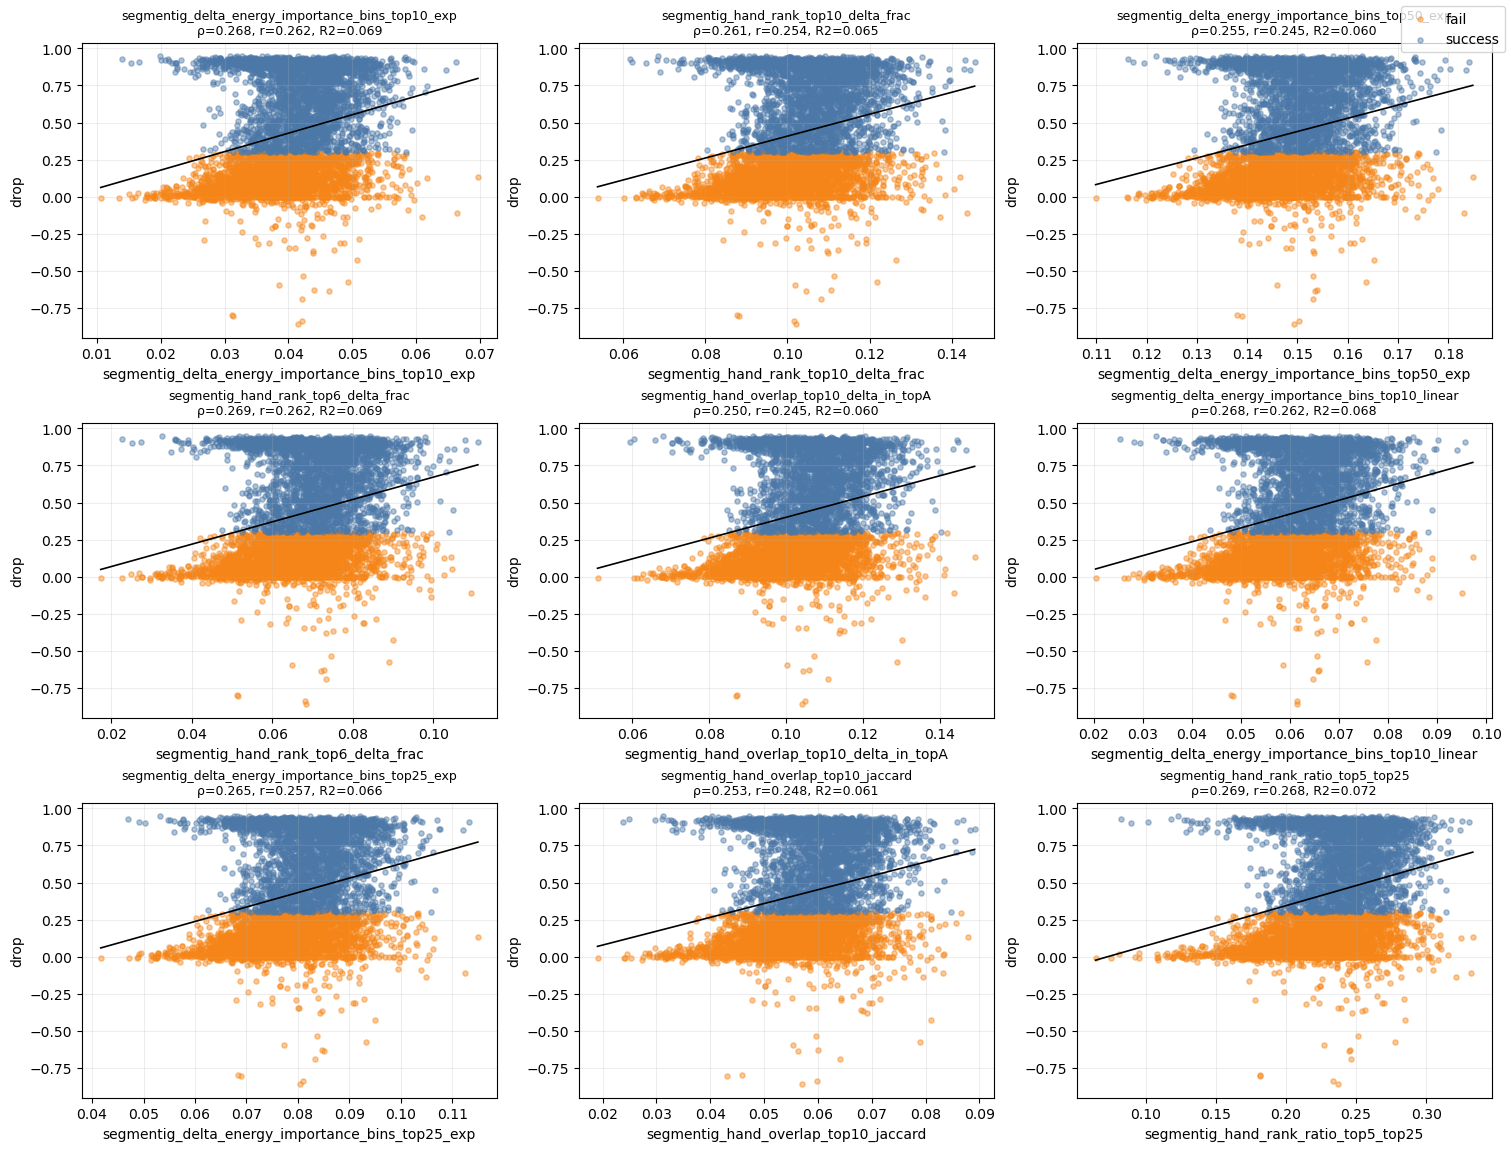

In [4]:
method = "segmentig"
q = suite["quality_by_method"][method]
r = suite["regression_by_method"][method]
display(q.head(30))
for path in q.get("figure_path", pd.Series(dtype=str)).dropna().head(8):
    display(Image(filename=path))
display(r.head(30))
fig = regression_metrics.plot_similarity_score_bars(r.head(40), score_col="main_score")
plt.show()
fig = regression_metrics.plot_similarity_heatmap(r, top_n=30)
plt.show()
fig = regression_metrics.plot_top_metric_scatter(rows_df, r, target_col="drop", top_n=9)
plt.show()

## ODAM

,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
0,odam_align_cosine,0.698937,0.659051,0.095622,1,new_experiments/outputs/patch_success_analysis...
1,odam_hand_flat_abs_cosine,0.698937,0.659051,0.095622,1,new_experiments/outputs/patch_success_analysis...
2,odam_hand_overlap_top1_jaccard,0.683918,0.647361,0.027210,1,new_experiments/outputs/patch_success_analysis...
3,odam_hand_spatial_cosine,0.682482,0.646298,0.245820,1,new_experiments/outputs/patch_success_analysis...
4,odam_delta_importance_product_top10_power_0p25,0.683481,0.643642,0.017227,1,new_experiments/outputs/patch_success_analysis...
5,odam_delta_importance_product_top5_power_0p25,0.683705,0.643287,0.016244,1,new_experiments/outputs/patch_success_analysis...
6,odam_hand_rank_ratio_top5_top25,0.670663,0.642756,0.221951,1,new_experiments/outputs/patch_success_analysis...
7,odam_hand_overlap_top3_jaccard,0.676577,0.642402,0.034126,1,new_experiments/outputs/patch_success_analysis...
8,odam_delta_importance_product_top3_power_0p25,0.683064,0.641339,0.013157,1,new_experiments/outputs/patch_success_analysis...
9,odam_align_top_jaccard,0.669755,0.639568,0.038777,1,new_experiments/outputs/patch_success_analysis...


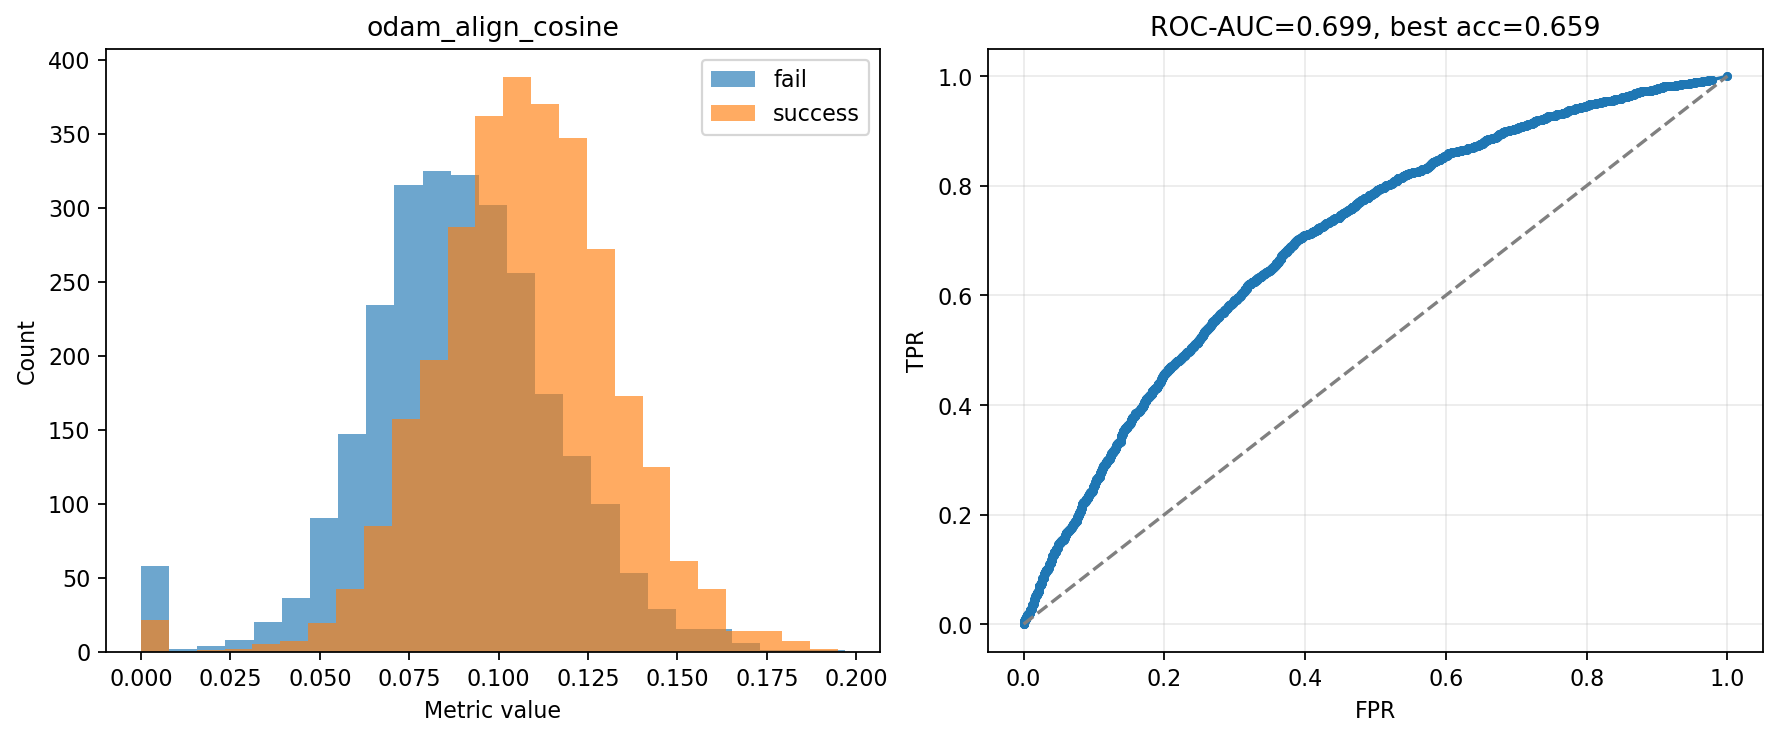

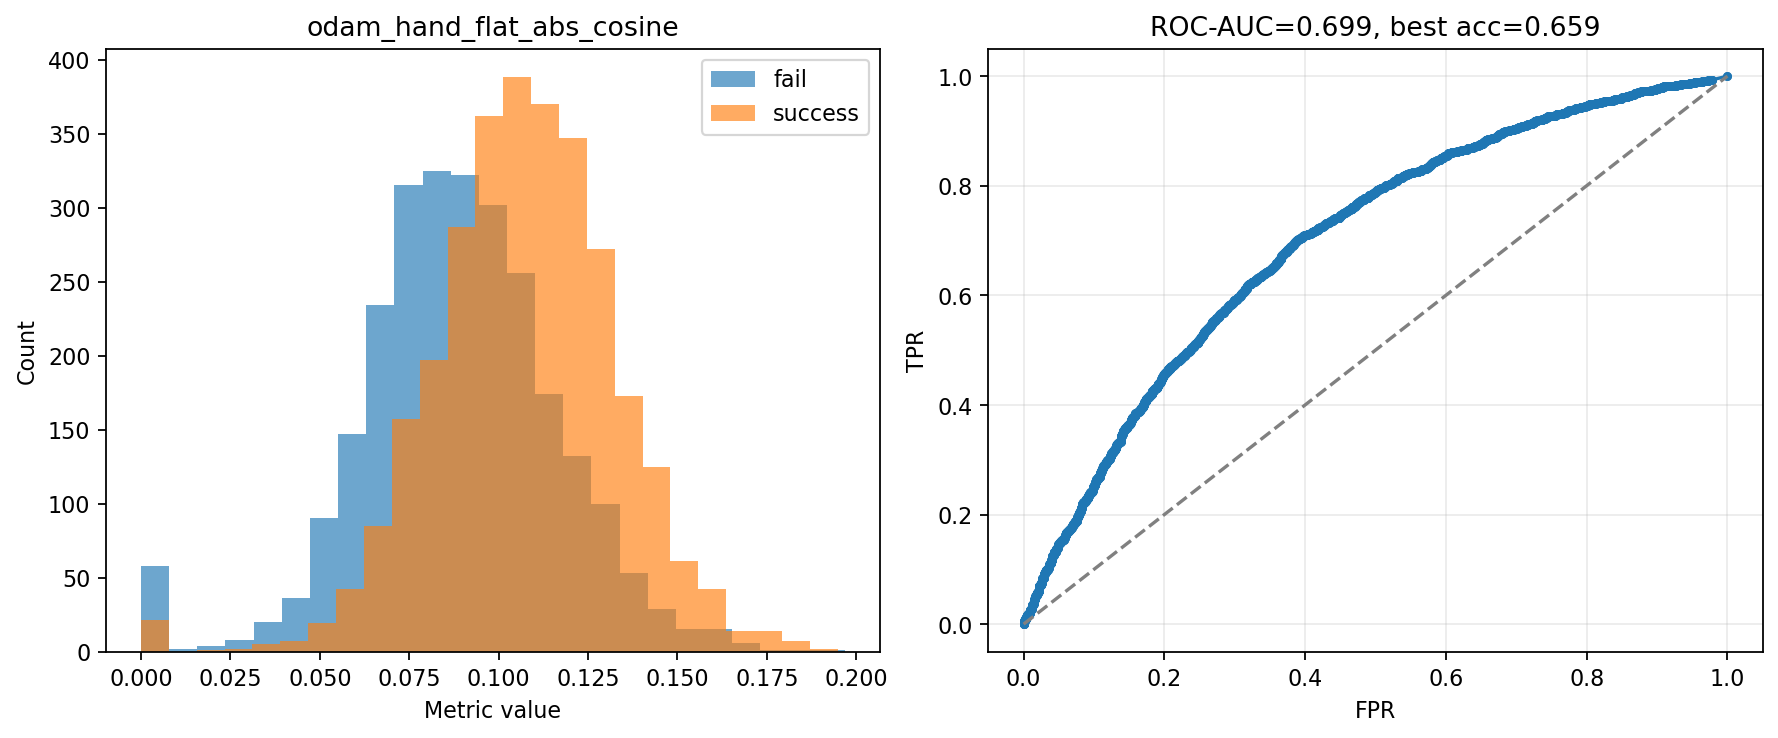

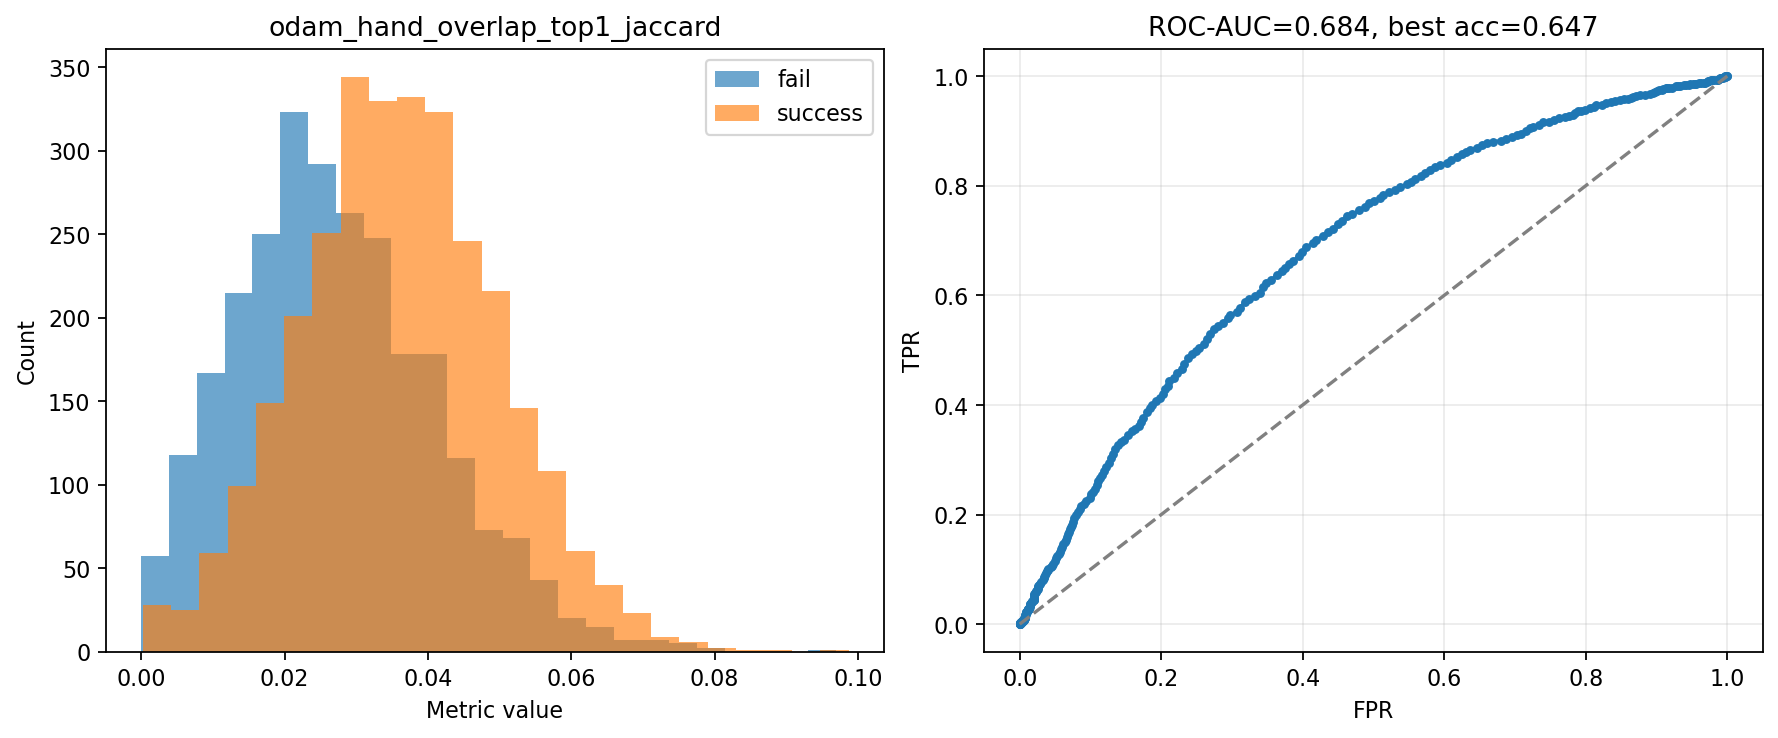

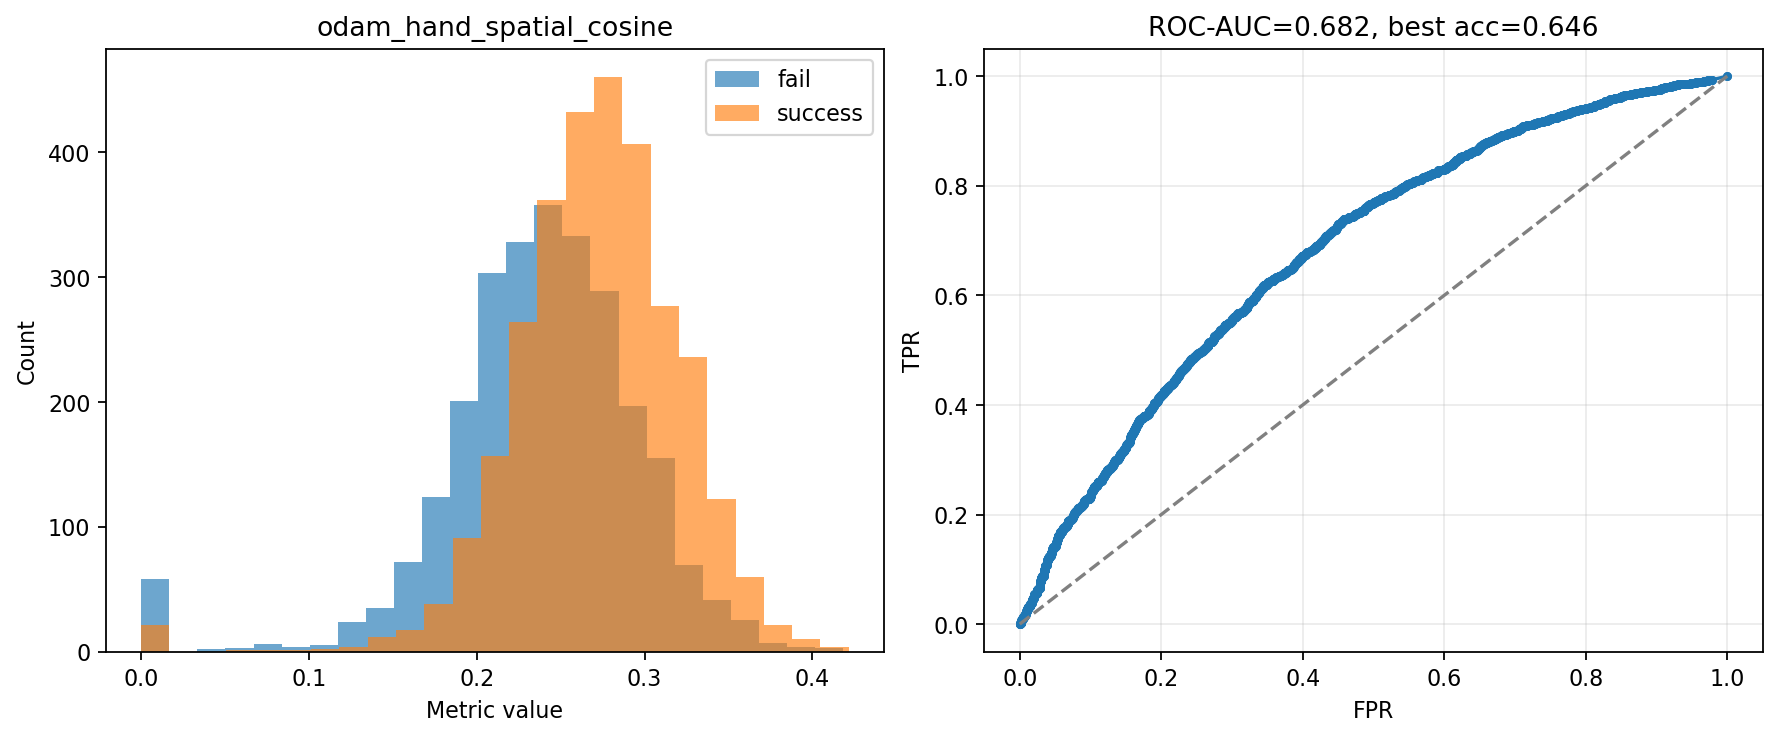

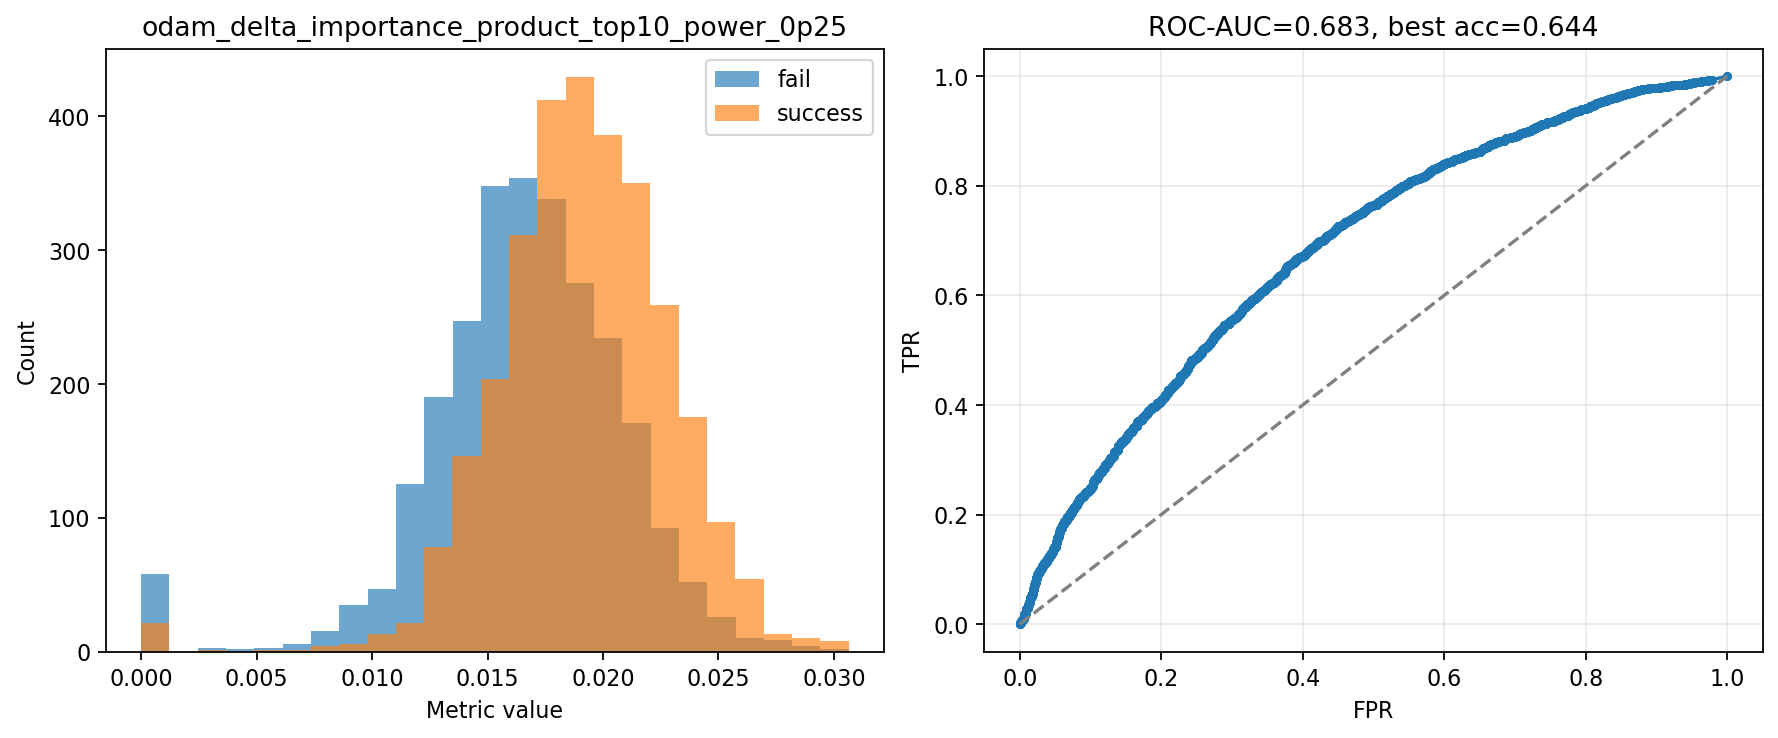

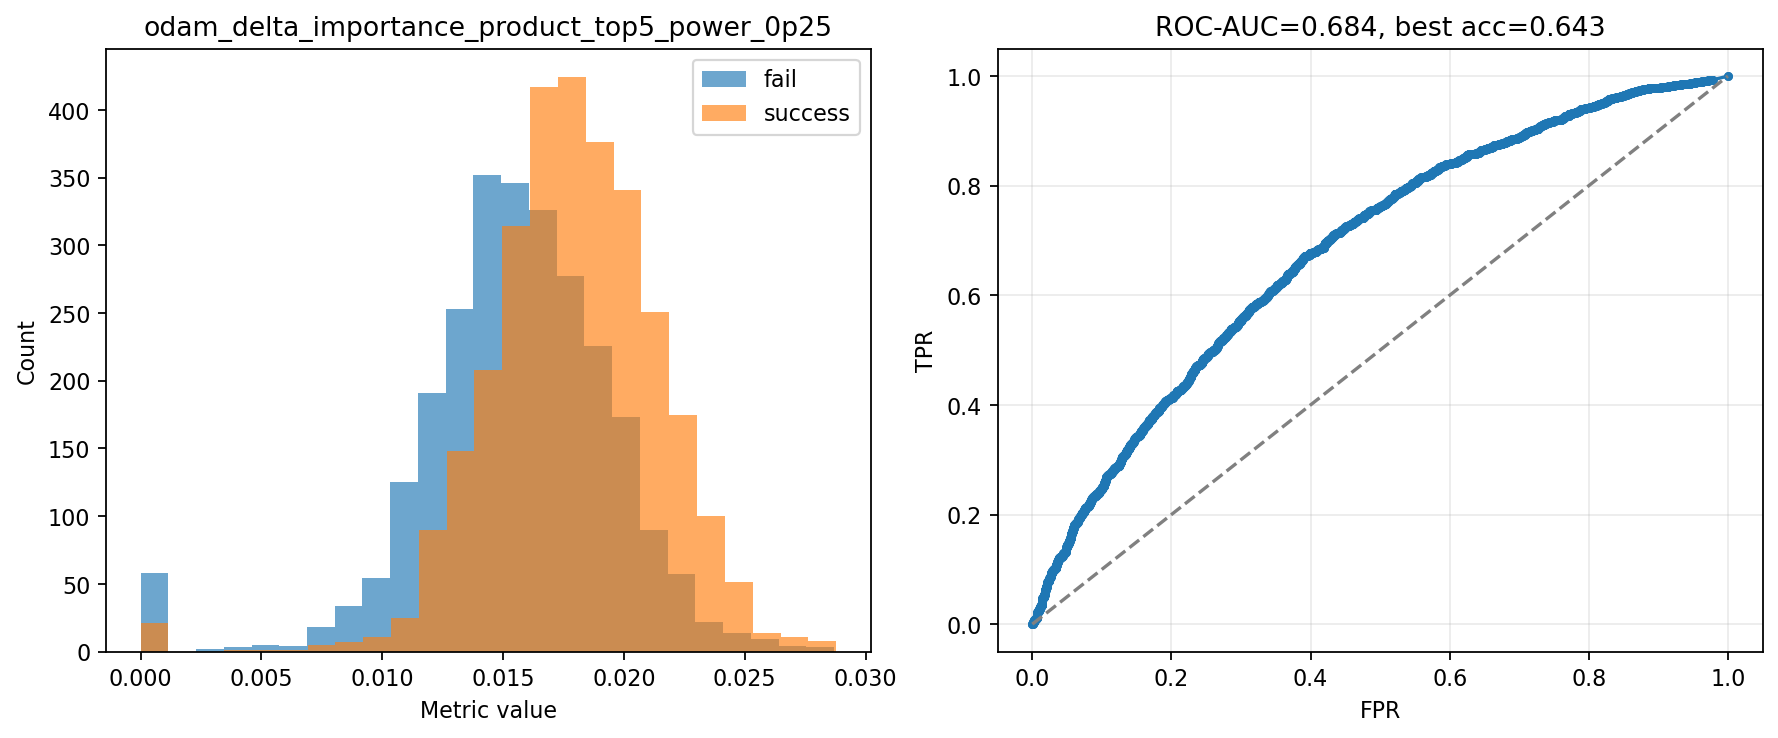

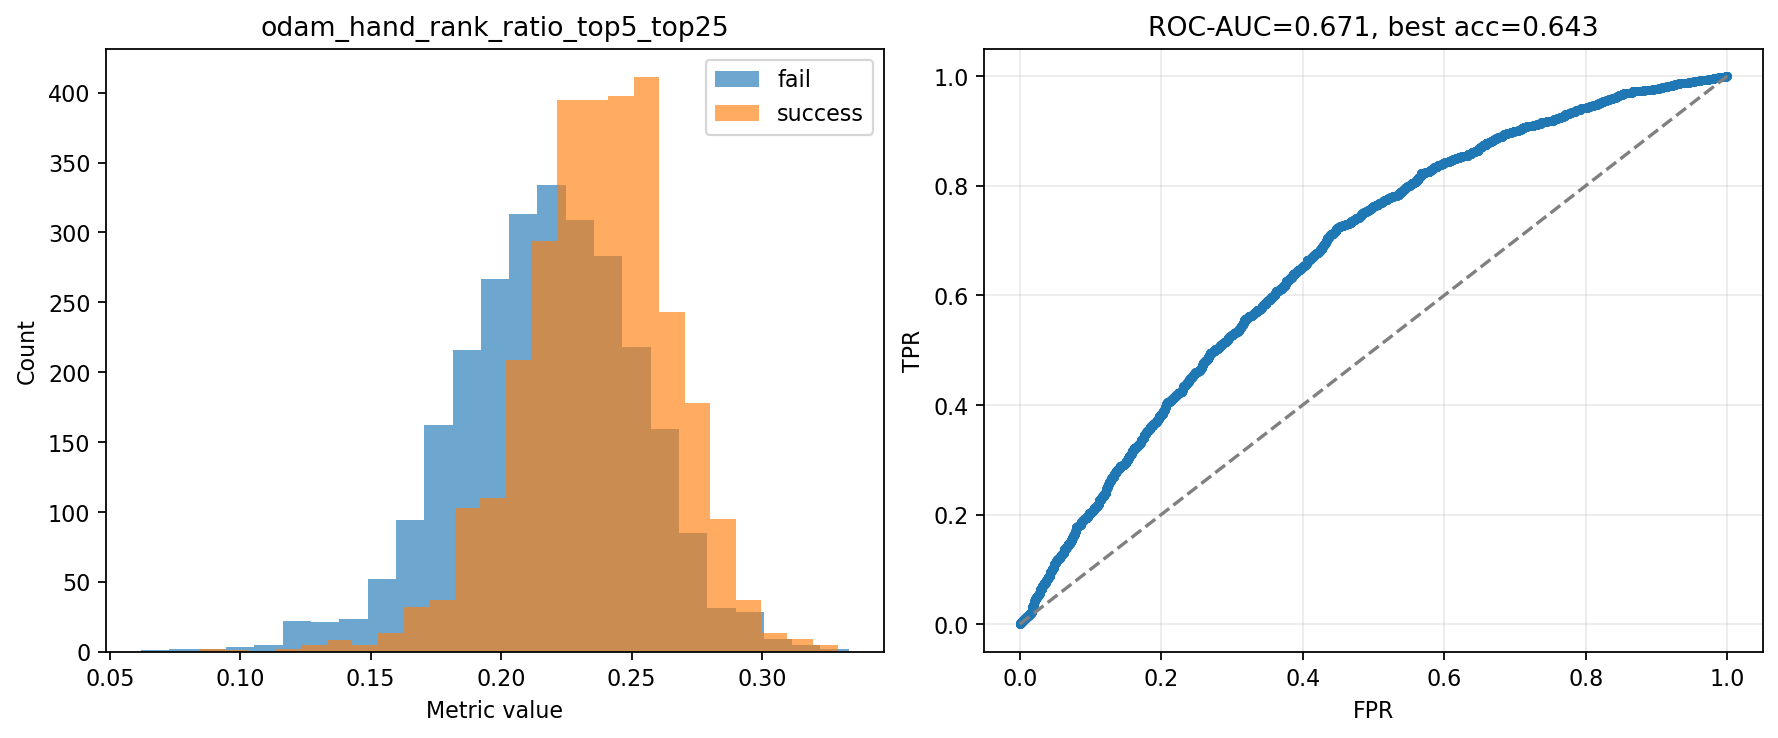

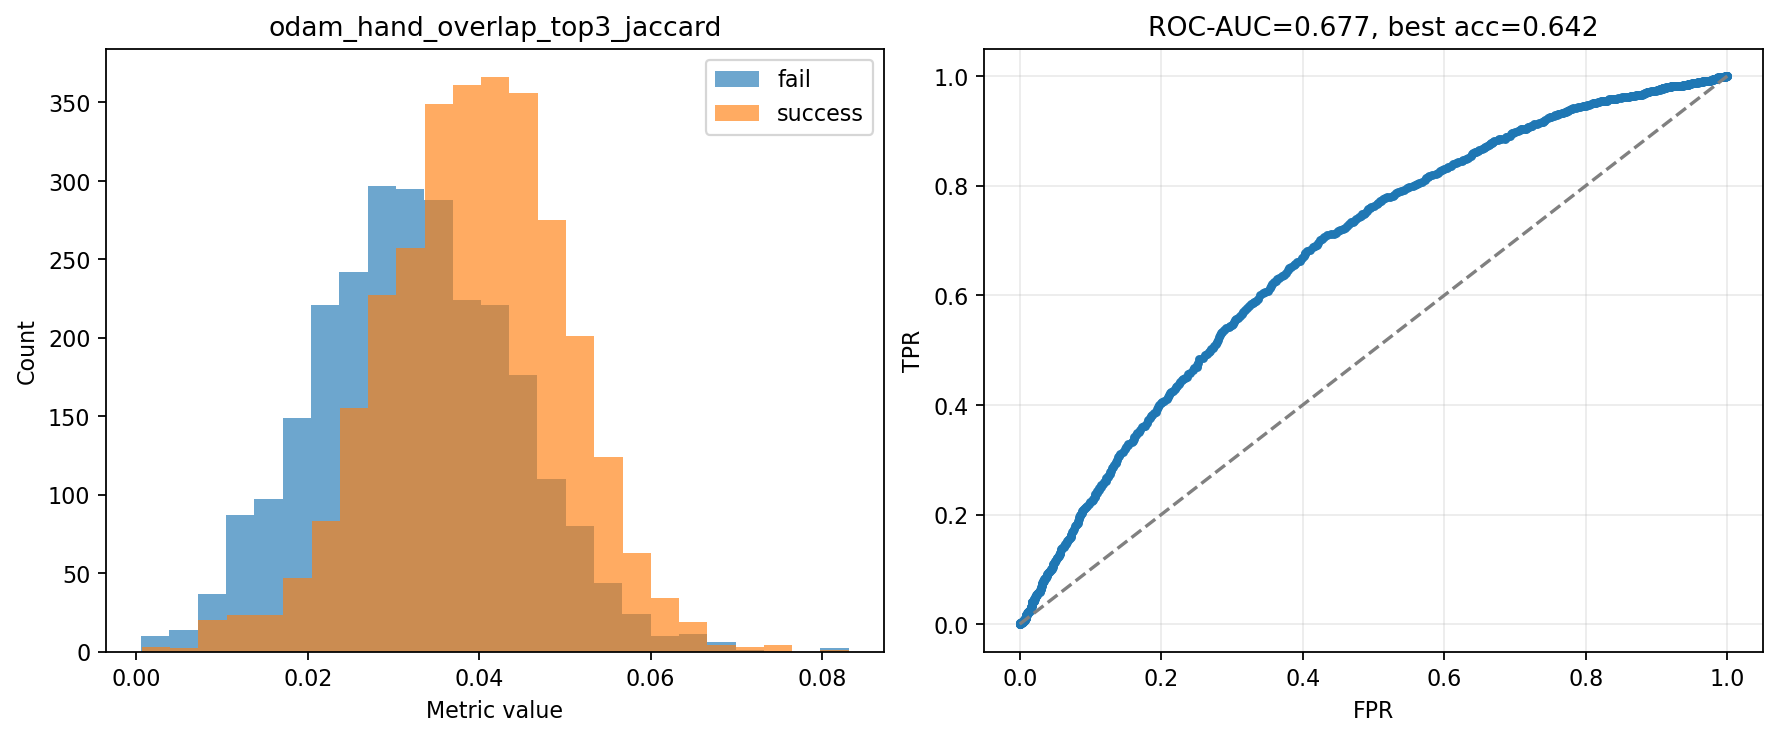

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,odam_align_cosine,5646,1.0,0.318566,0.341009,0.238360,0.318566,0.341009,0.238360,0.122455,...,0.339241,3.837077,0.054440,0.101484,0.278764,0.321539,0.947901,0.875268,0.513373,0.386759
1,odam_hand_flat_abs_cosine,5646,1.0,0.318566,0.341009,0.238360,0.318566,0.341009,0.238360,0.122451,...,0.339241,3.837077,0.054440,0.101484,0.278764,0.321539,0.947901,0.875235,0.513373,0.386754
2,odam_hand_overlap_top1_jaccard,5646,1.0,0.300530,0.321203,0.224396,0.300530,0.321203,0.224396,0.115873,...,0.339241,7.025360,0.207993,0.090318,0.281592,0.323530,0.953772,0.828217,0.511830,0.367393
3,odam_hand_rank_ratio_top5_top25,5646,1.0,0.270616,0.272667,0.190746,0.270616,0.272667,0.190746,0.139906,...,0.339241,2.747109,-0.192590,0.073233,0.284139,0.326554,0.962687,1.000000,0.509506,0.367107
4,odam_delta_importance_product_top10_power_0p25,5646,1.0,0.294288,0.316332,0.220063,0.294288,0.316332,0.220063,0.117567,...,0.339241,23.529460,0.010827,0.086605,0.283066,0.324190,0.955717,0.840328,0.511321,0.365542
5,odam_delta_importance_product_top5_power_0p25,5646,1.0,0.295375,0.316821,0.220437,0.295375,0.316821,0.220437,0.115403,...,0.339241,24.917810,0.014584,0.087246,0.282849,0.324076,0.955381,0.824859,0.511409,0.363699
6,odam_hand_rank_top3_delta_frac,5646,1.0,0.272283,0.281162,0.196215,0.272283,0.281162,0.196215,0.127996,...,0.339241,11.813009,-0.035308,0.074138,0.284478,0.326395,0.962217,0.914875,0.509628,0.358199
7,odam_hand_overlap_top3_delta_in_topA,5646,1.0,0.271629,0.281030,0.196058,0.271629,0.281030,0.196058,0.127965,...,0.339241,11.869268,-0.037887,0.073782,0.284577,0.326458,0.962402,0.914653,0.509580,0.357987
8,odam_hand_spatial_cosine,5646,1.0,0.285205,0.309737,0.216366,0.285205,0.309737,0.216366,0.113401,...,0.339241,1.675952,0.004496,0.081342,0.284270,0.325123,0.958467,0.810549,0.510604,0.357789
9,odam_delta_energy_importance_binfrac_001,5646,1.0,0.270952,0.287261,0.199744,0.270952,0.287261,0.199744,0.125140,...,0.339241,19.705733,0.044330,0.073415,0.285739,0.326522,0.962593,0.894455,0.509530,0.356639


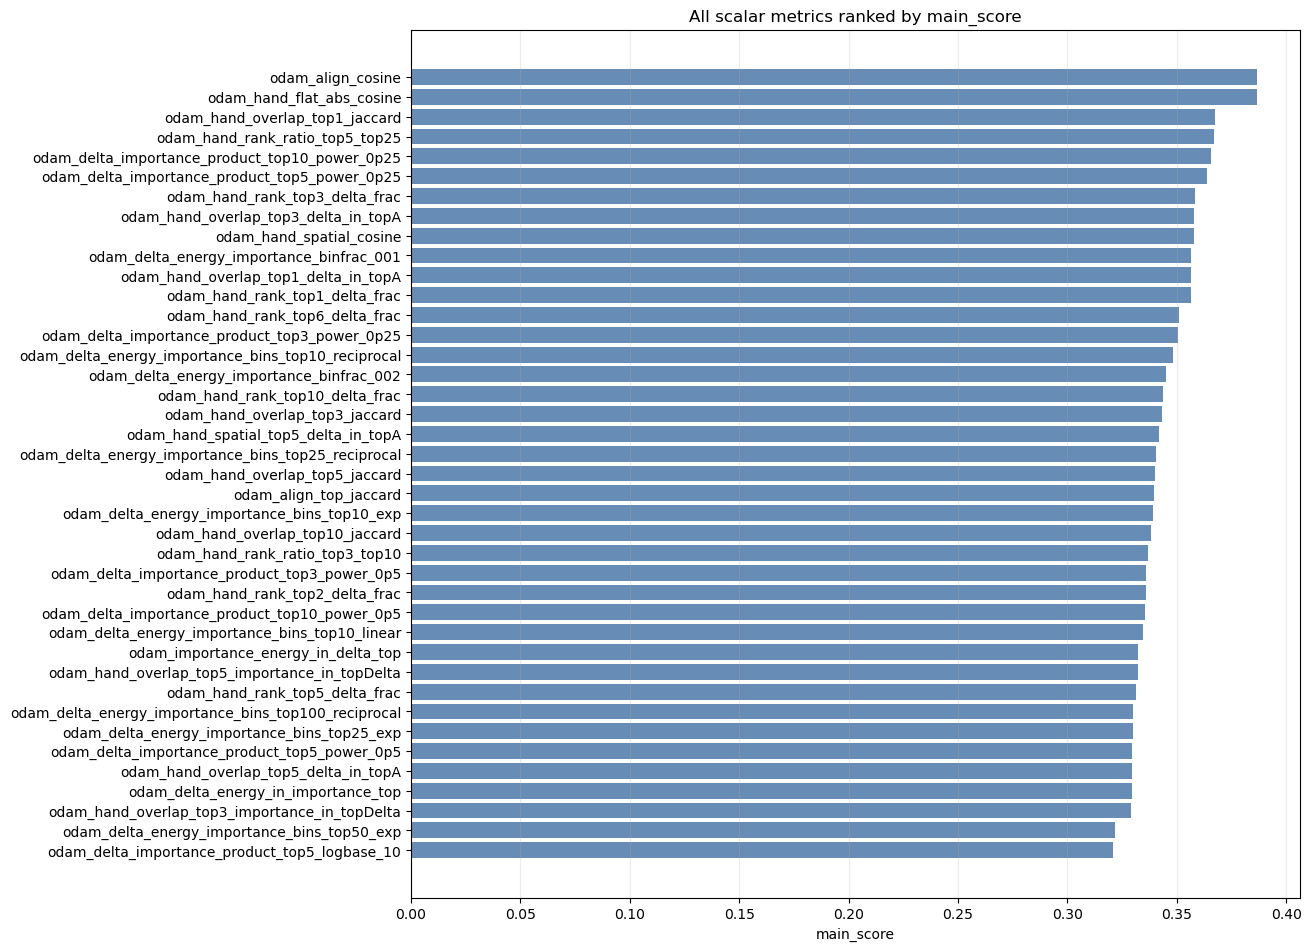

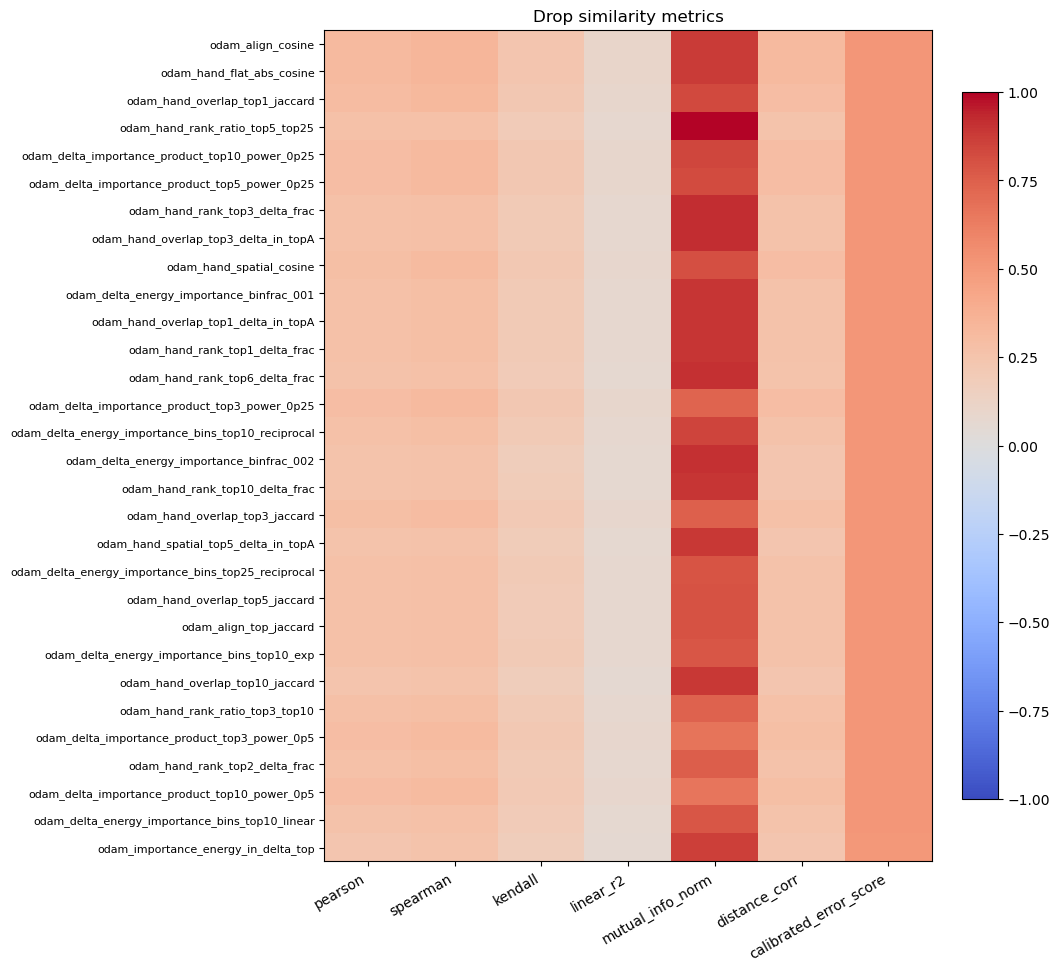

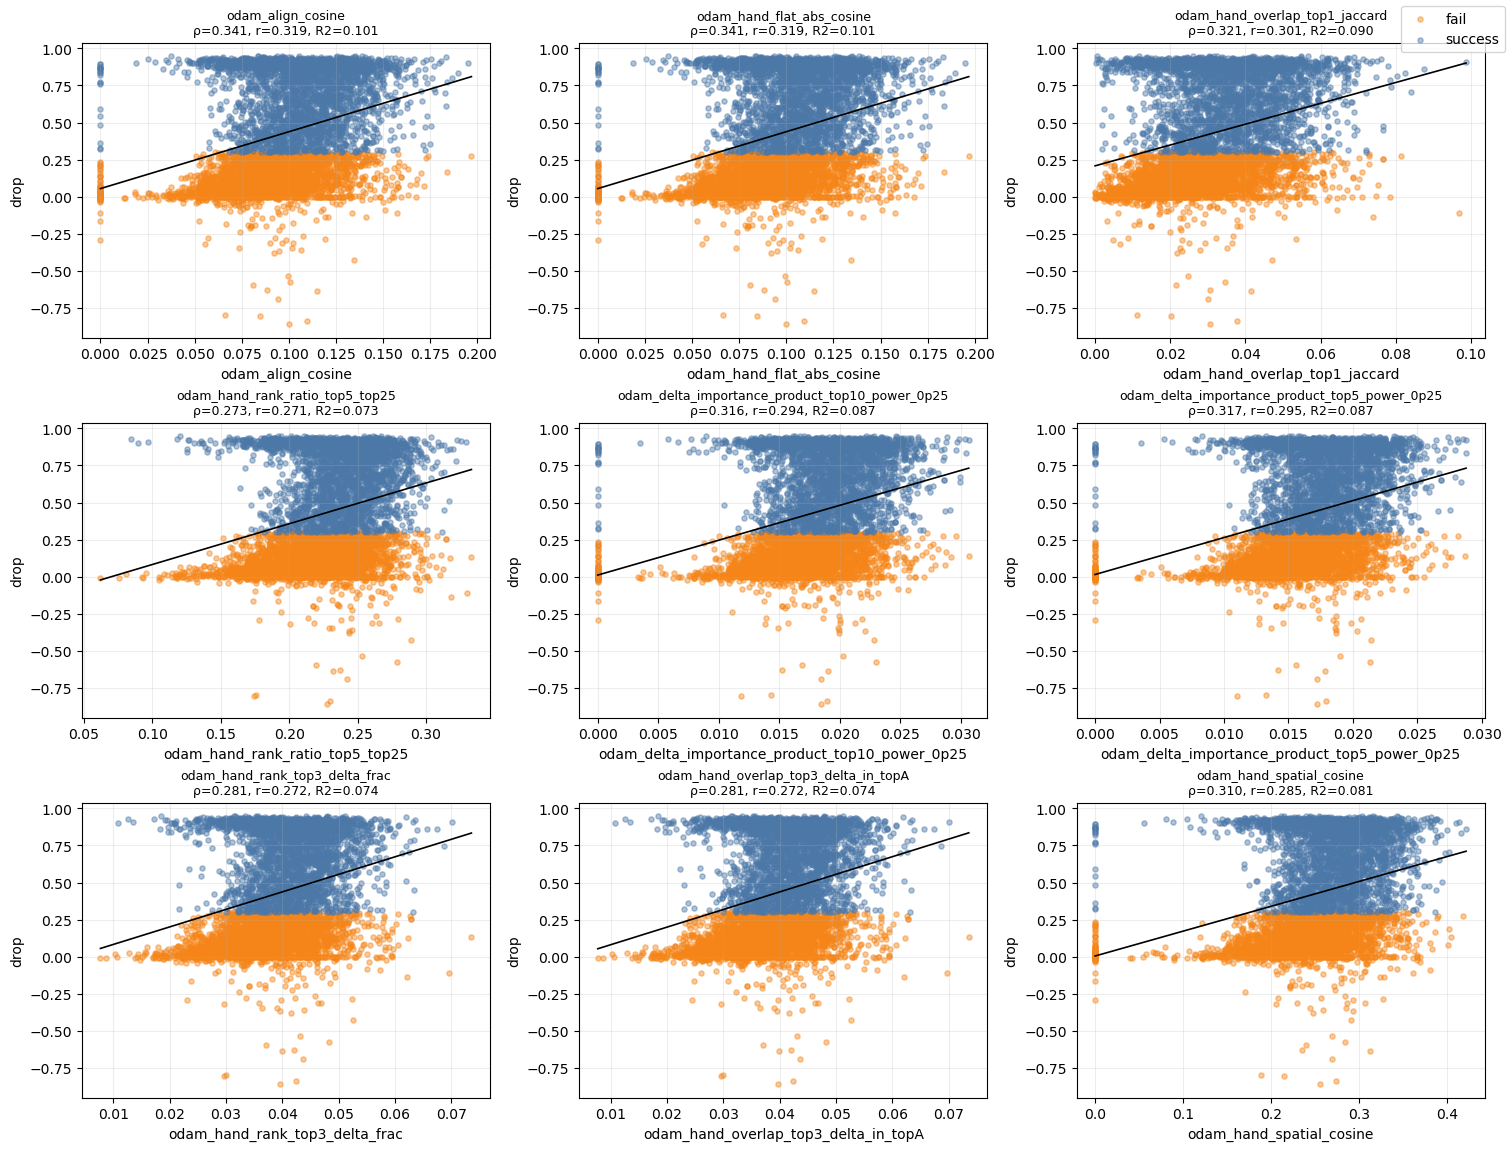

In [5]:
method = "odam"
q = suite["quality_by_method"][method]
r = suite["regression_by_method"][method]
display(q.head(30))
for path in q.get("figure_path", pd.Series(dtype=str)).dropna().head(8):
    display(Image(filename=path))
display(r.head(30))
fig = regression_metrics.plot_similarity_score_bars(r.head(40), score_col="main_score")
plt.show()
fig = regression_metrics.plot_similarity_heatmap(r, top_n=30)
plt.show()
fig = regression_metrics.plot_top_metric_scatter(rows_df, r, target_col="drop", top_n=9)
plt.show()

## LayerCAM

,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
0,layercam_hand_signed_correct_minus_wrong,0.713254,0.673220,0.851913,1,new_experiments/outputs/patch_success_analysis...
1,layercam_hand_signed_correct_mass_ratio,0.713233,0.673220,0.925957,1,new_experiments/outputs/patch_success_analysis...
2,layercam_hand_signed_pos_down_mass,0.717315,0.671277,0.931727,1,new_experiments/outputs/patch_success_analysis...
3,layercam_align_cosine,0.703595,0.661176,0.074093,1,new_experiments/outputs/patch_success_analysis...
4,layercam_hand_flat_abs_cosine,0.703595,0.661176,0.074093,1,new_experiments/outputs/patch_success_analysis...
5,layercam_hand_overlap_top1_jaccard,0.689302,0.647538,0.019793,1,new_experiments/outputs/patch_success_analysis...
6,layercam_hand_overlap_top1_importance_in_topDelta,0.676074,0.645767,0.118586,1,new_experiments/outputs/patch_success_analysis...
7,layercam_hand_spatial_cosine,0.683971,0.643996,0.233386,1,new_experiments/outputs/patch_success_analysis...
8,layercam_delta_importance_product_top5_power_0p25,0.680386,0.642402,0.009506,1,new_experiments/outputs/patch_success_analysis...
9,layercam_delta_importance_product_top10_power_...,0.680386,0.642402,0.009506,1,new_experiments/outputs/patch_success_analysis...


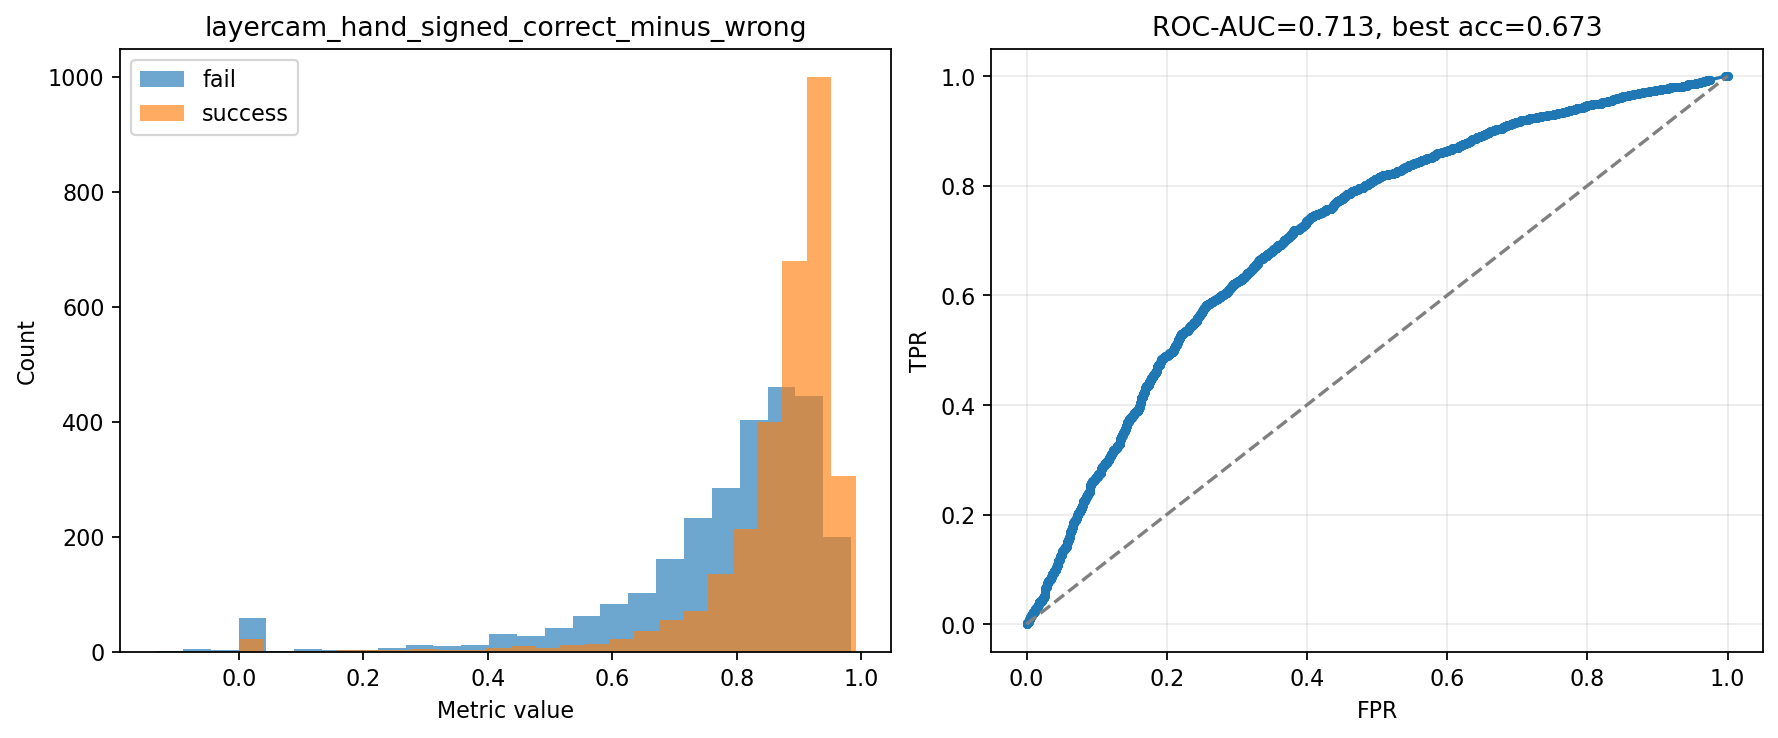

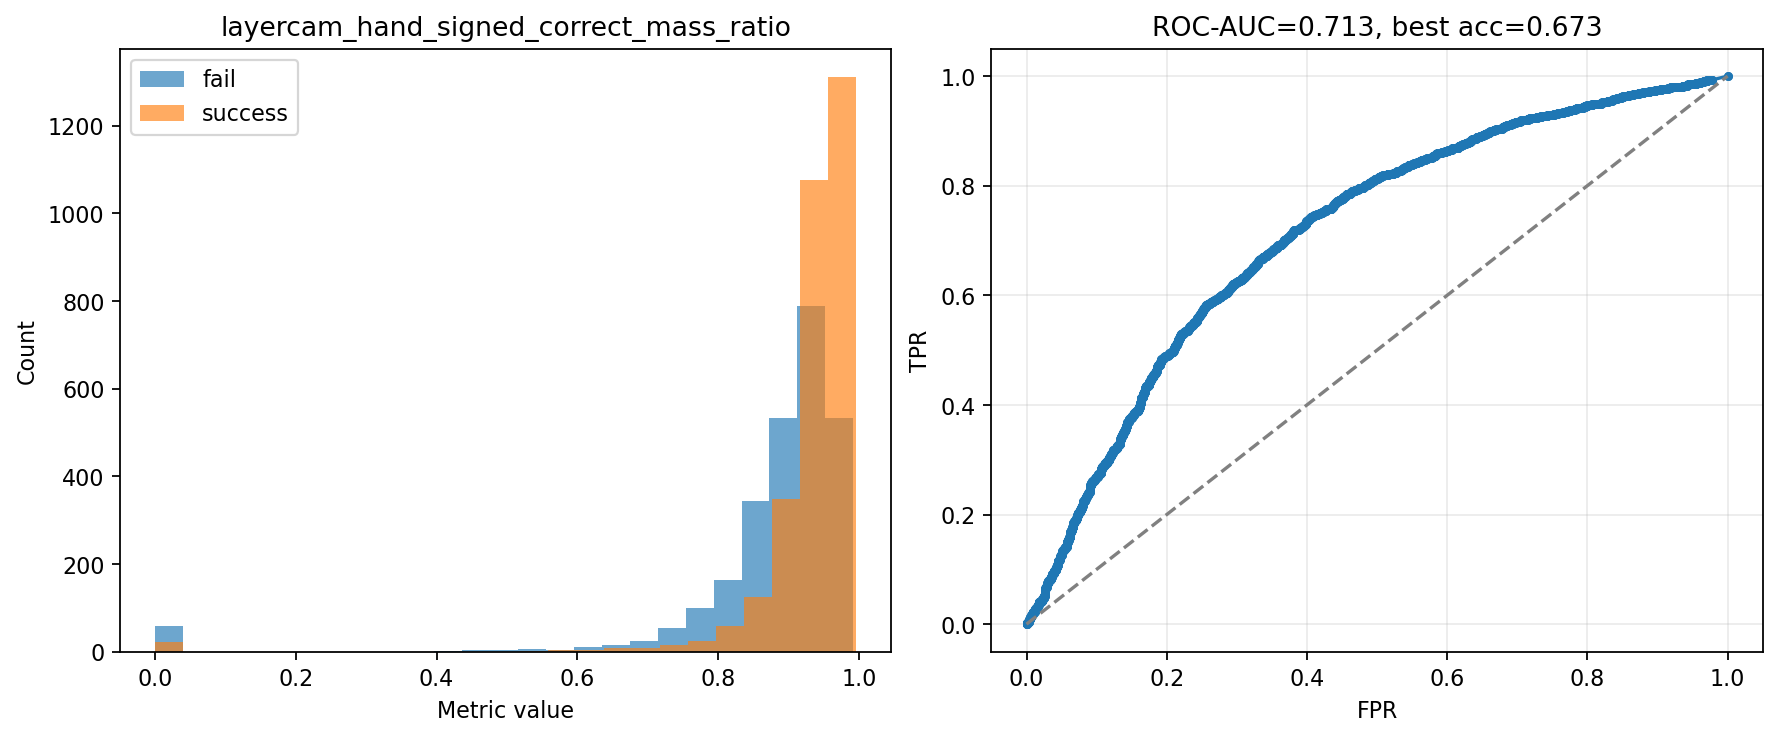

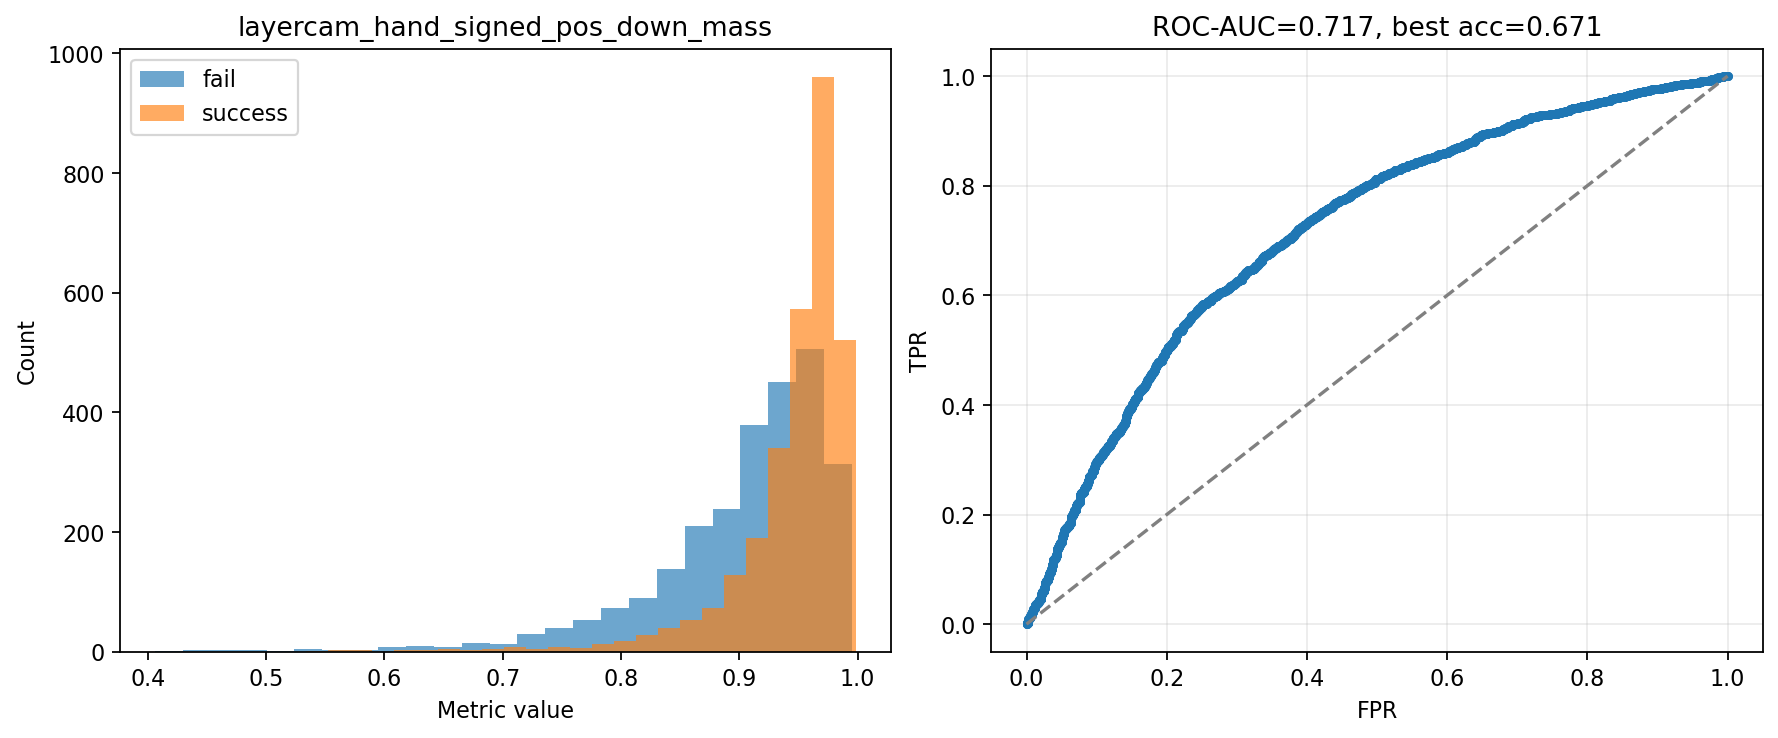

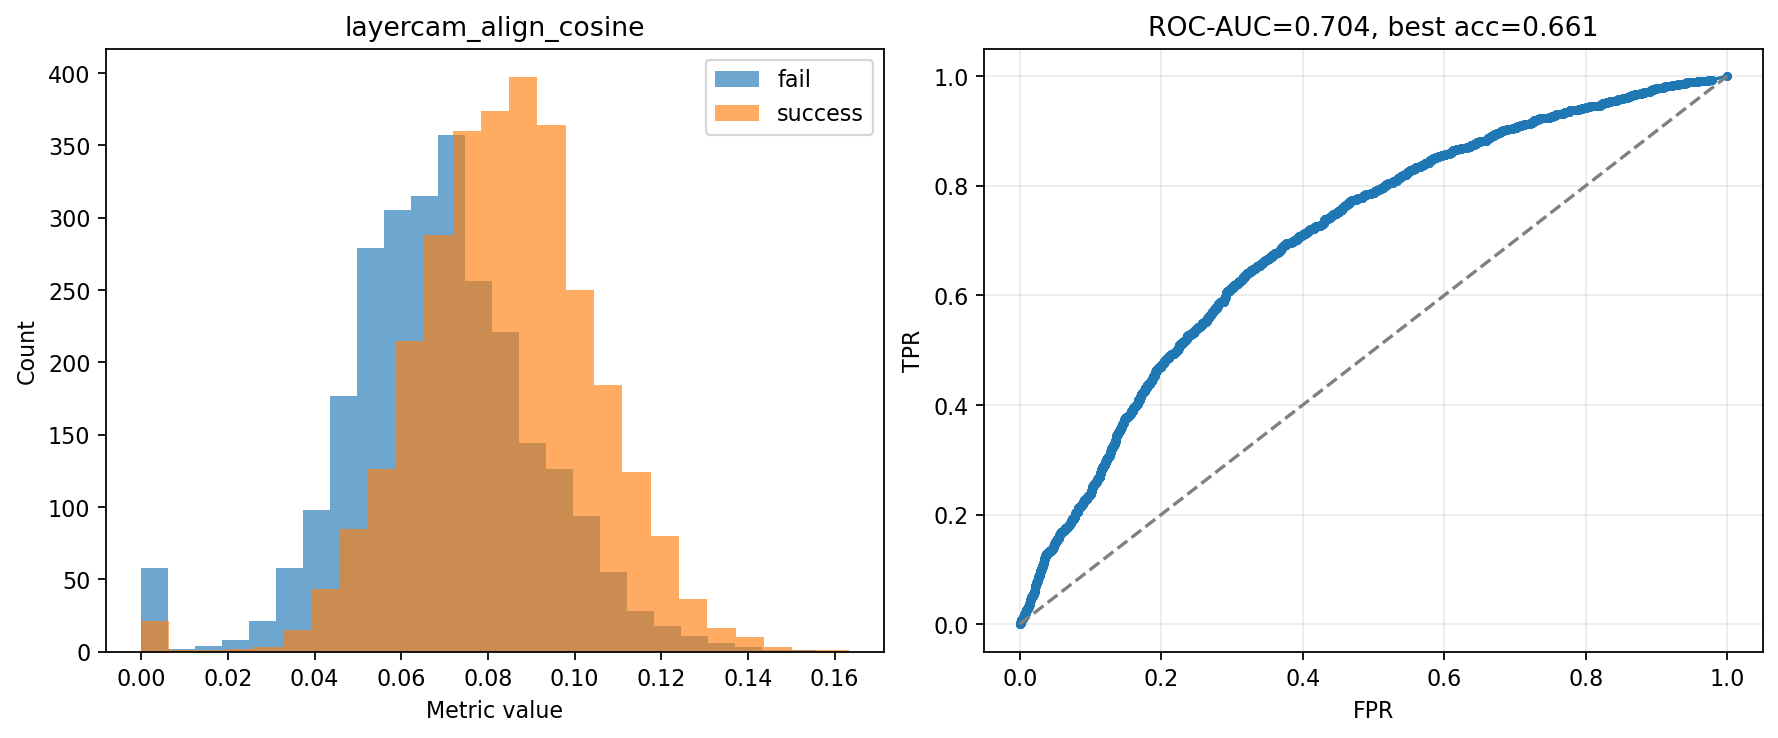

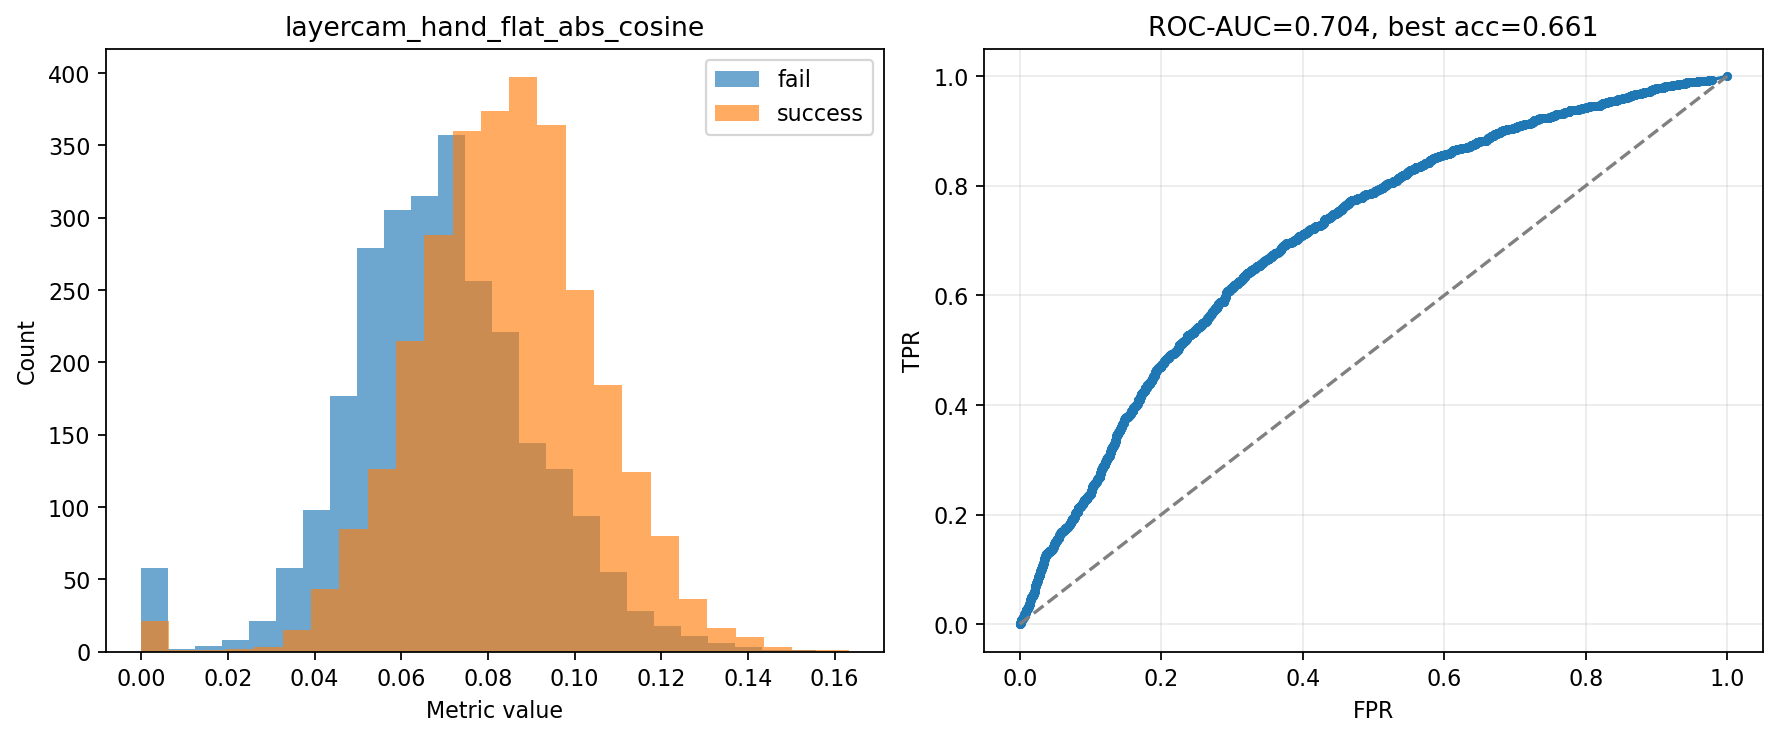

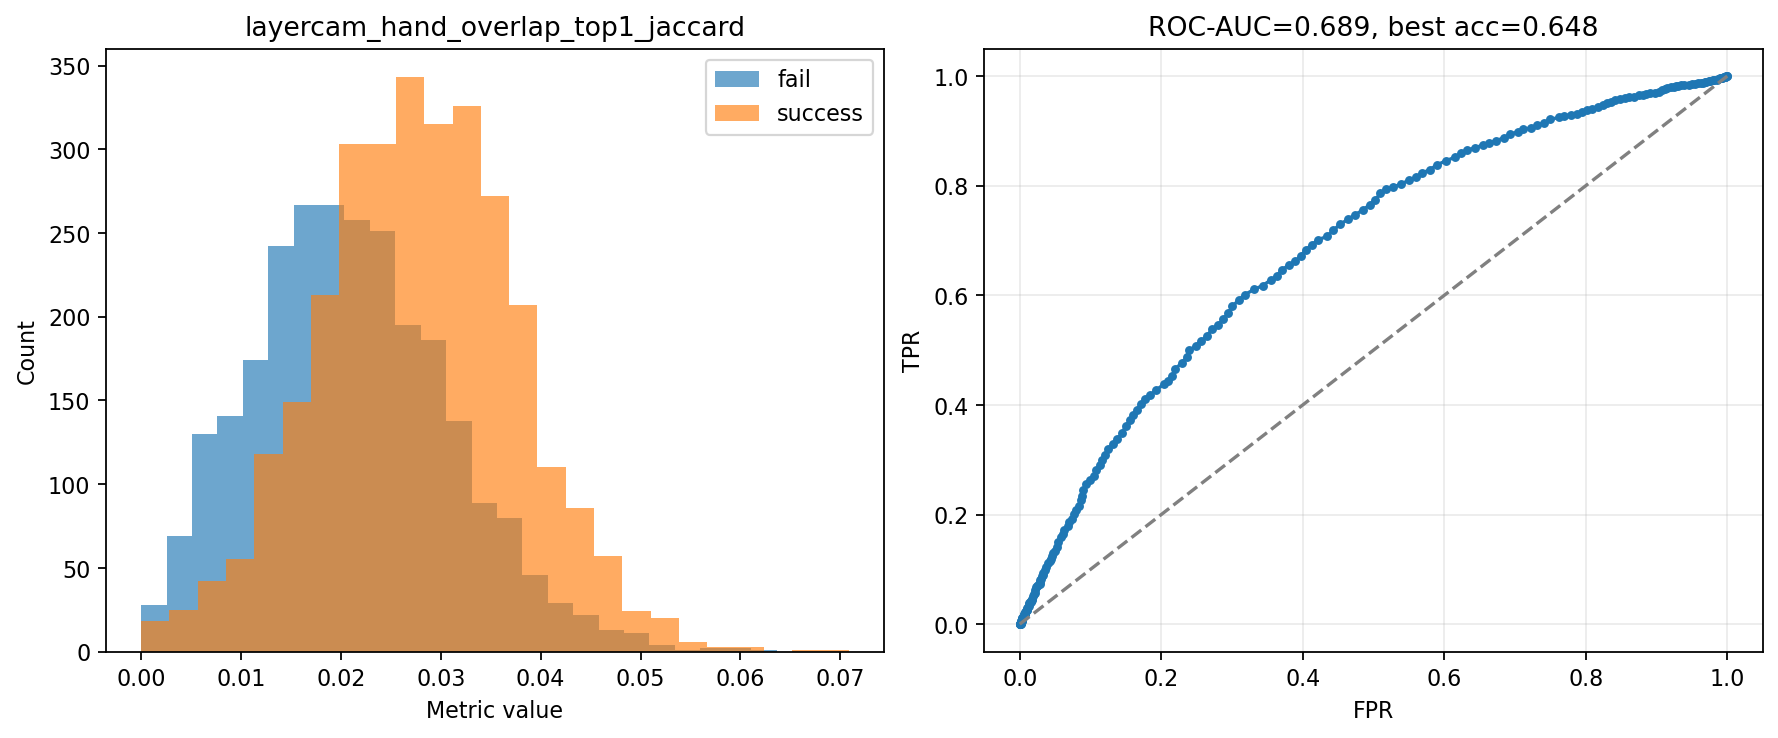

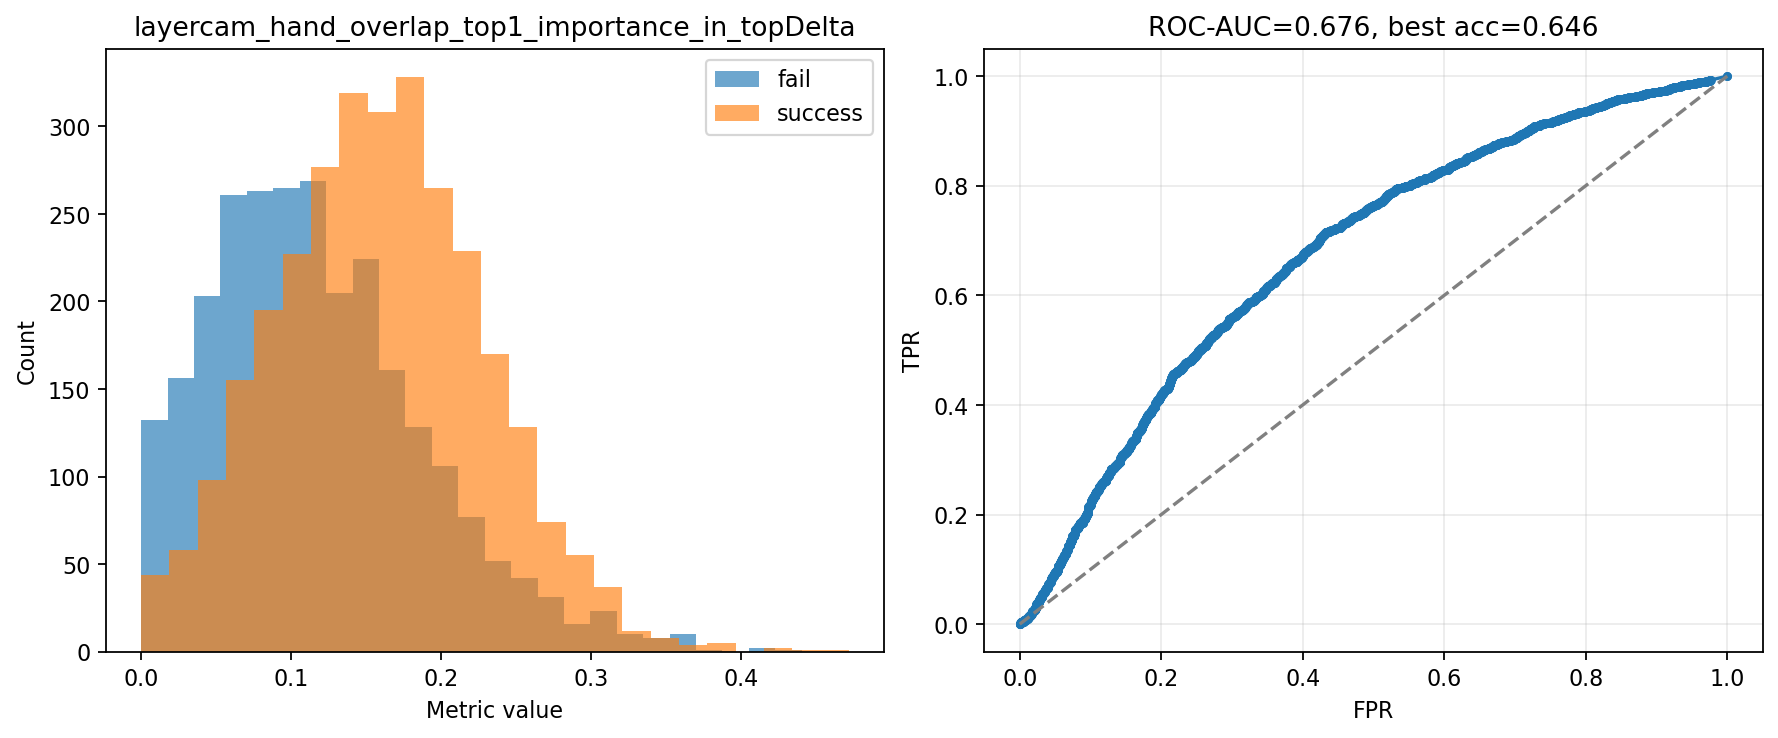

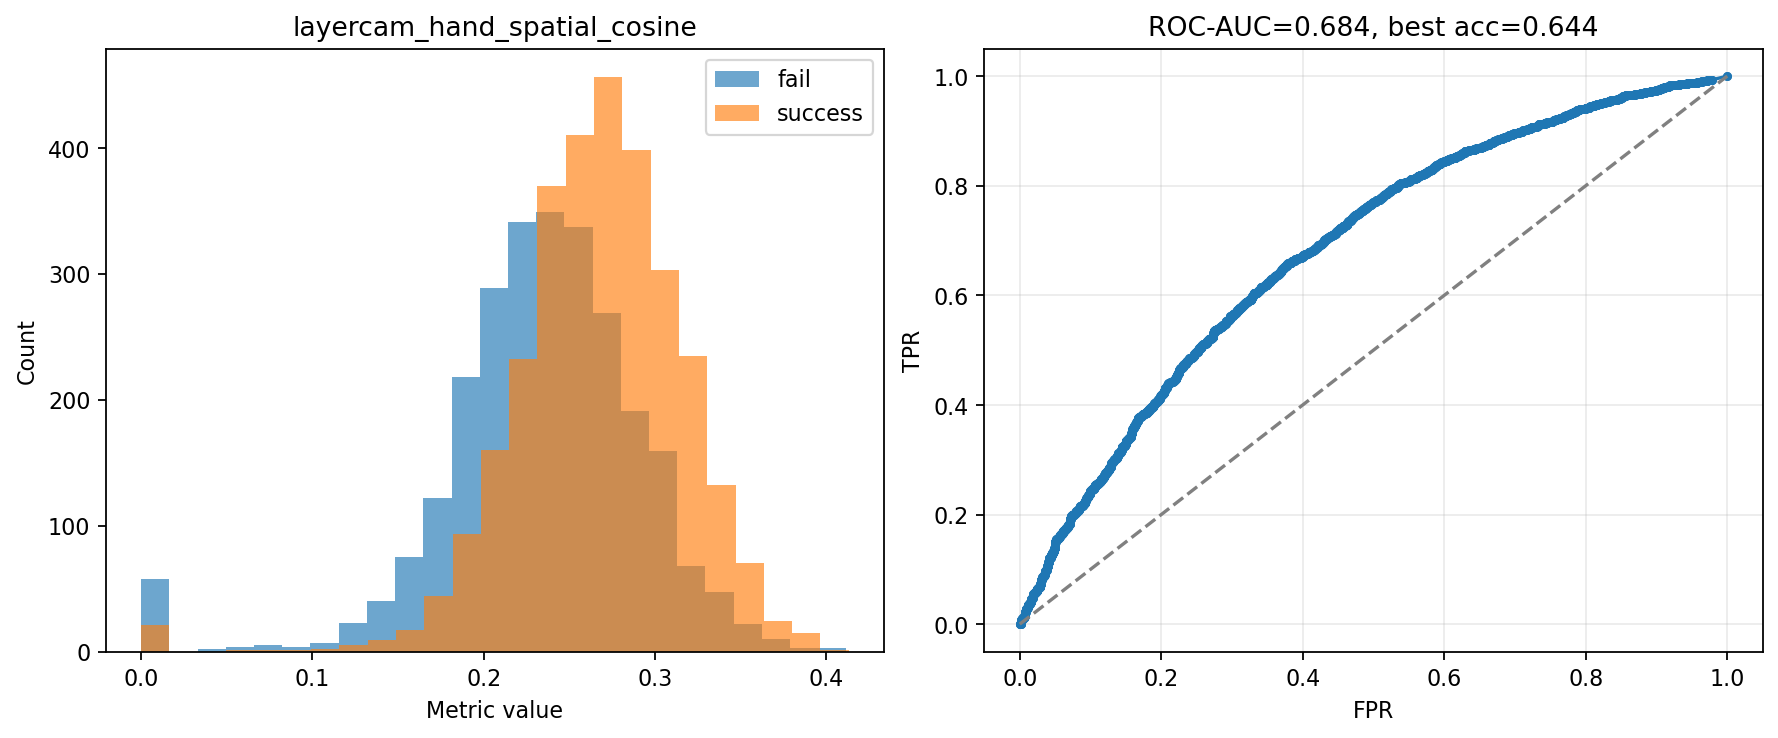

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,layercam_hand_signed_pos_down_mass,5567,0.986008,0.307226,0.352504,0.251071,0.307226,0.352504,0.251071,0.164236,...,0.339241,1.541608,-0.991712,0.094388,0.280148,0.322070,0.951636,0.943461,0.512390,0.402989
1,layercam_hand_signed_correct_minus_wrong,5646,1.000000,0.284964,0.348021,0.247594,0.284964,0.348021,0.247594,0.174078,...,0.339241,0.596410,-0.059493,0.081205,0.285579,0.325147,0.958538,1.000000,0.510585,0.398201
2,layercam_hand_signed_correct_mass_ratio,5646,1.000000,0.218044,0.347963,0.247545,0.218044,0.347963,0.247545,0.174076,...,0.339241,0.588602,-0.100344,0.047543,0.295597,0.331049,0.975939,0.999984,0.506089,0.380336
3,layercam_align_cosine,5646,1.000000,0.328620,0.353633,0.247669,0.328620,0.353633,0.247669,0.121697,...,0.339241,4.899369,0.056736,0.107991,0.277355,0.320372,0.944462,0.699096,0.514281,0.368937
4,layercam_hand_flat_abs_cosine,5646,1.000000,0.328620,0.353633,0.247669,0.328620,0.353633,0.247669,0.121688,...,0.339241,4.899369,0.056736,0.107991,0.277355,0.320372,0.944462,0.699043,0.514281,0.368930
5,layercam_hand_overlap_top1_jaccard,5646,1.000000,0.314222,0.331631,0.232119,0.314222,0.331631,0.232119,0.119654,...,0.339241,10.245020,0.181108,0.098735,0.279452,0.322030,0.949350,0.687360,0.512992,0.354687
6,layercam_delta_importance_product_signed,5646,1.000000,0.302342,0.326997,0.226141,0.302342,0.326997,0.226141,0.120254,...,0.339241,276.086250,0.221589,0.091411,0.282428,0.323336,0.953200,0.690805,0.511980,0.348804
7,layercam_hand_signed_sum_norm_delta,5646,1.000000,0.302342,0.326997,0.226141,0.302342,0.326997,0.226141,0.120241,...,0.339241,276.086250,0.221589,0.091411,0.282428,0.323336,0.953200,0.690728,0.511980,0.348793
8,layercam_hand_spatial_cosine,5646,1.000000,0.289233,0.315946,0.220506,0.289233,0.315946,0.220506,0.120246,...,0.339241,1.716603,0.001513,0.083656,0.284020,0.324713,0.957259,0.690757,0.510919,0.344225
9,layercam_delta_importance_product_top5_power_0p25,5646,1.000000,0.291788,0.315129,0.218412,0.291788,0.315129,0.218412,0.111284,...,0.339241,41.564603,0.016892,0.085140,0.283737,0.324450,0.956483,0.639274,0.511121,0.335946


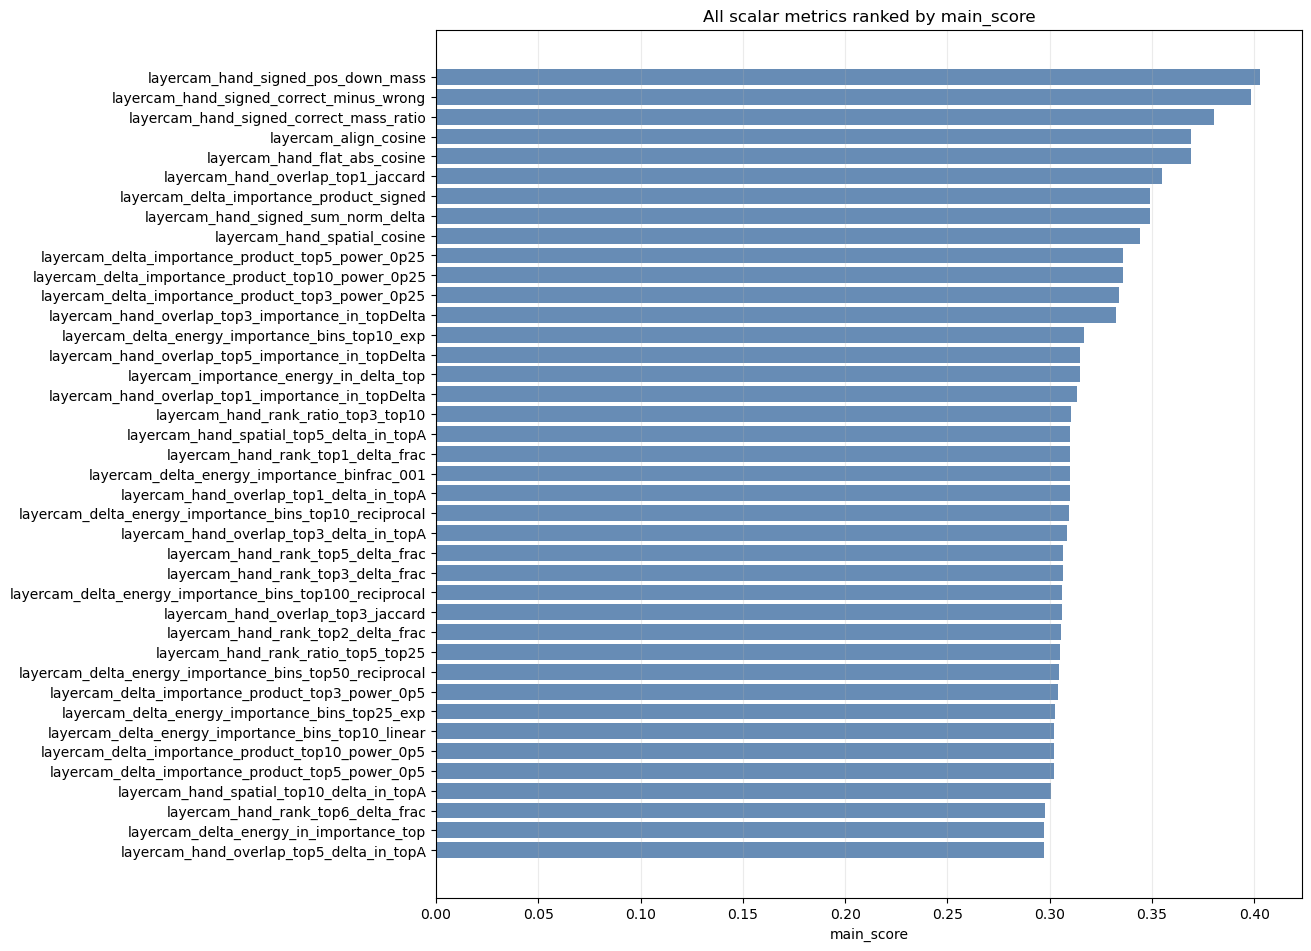

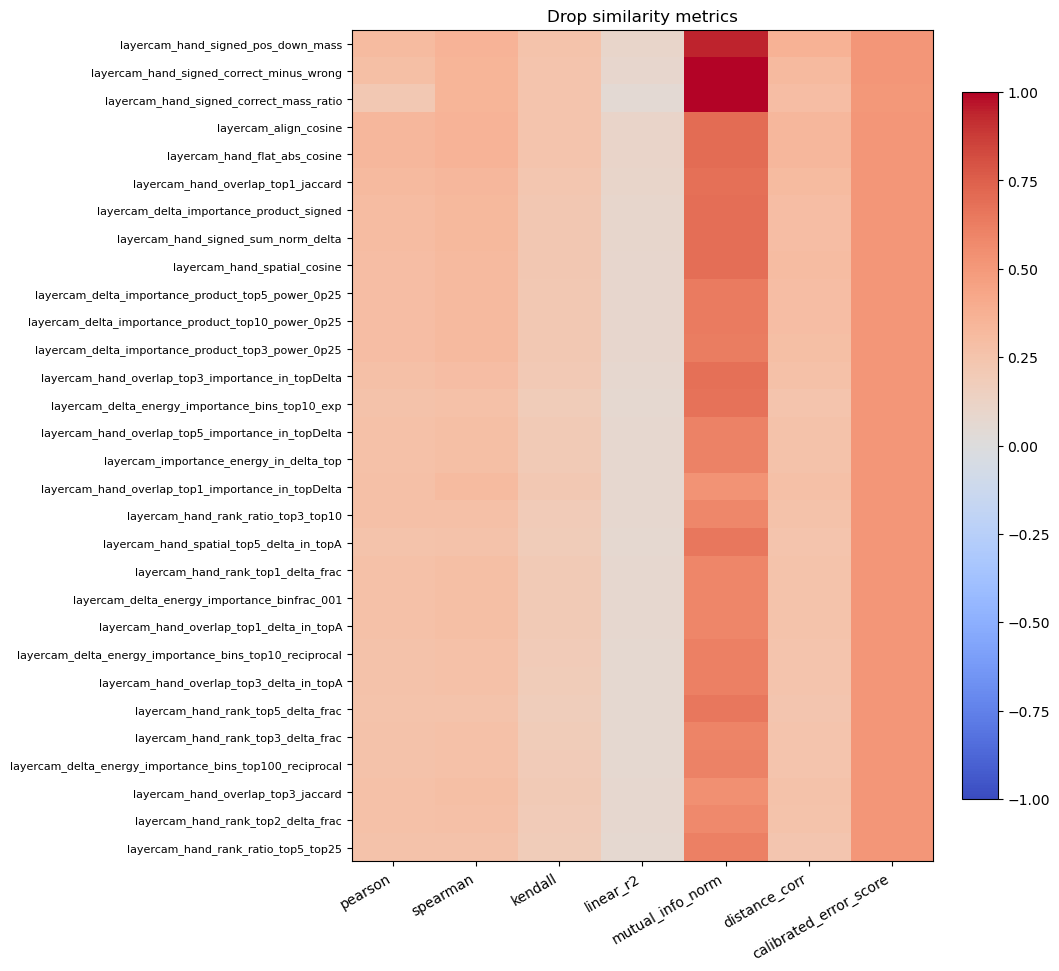

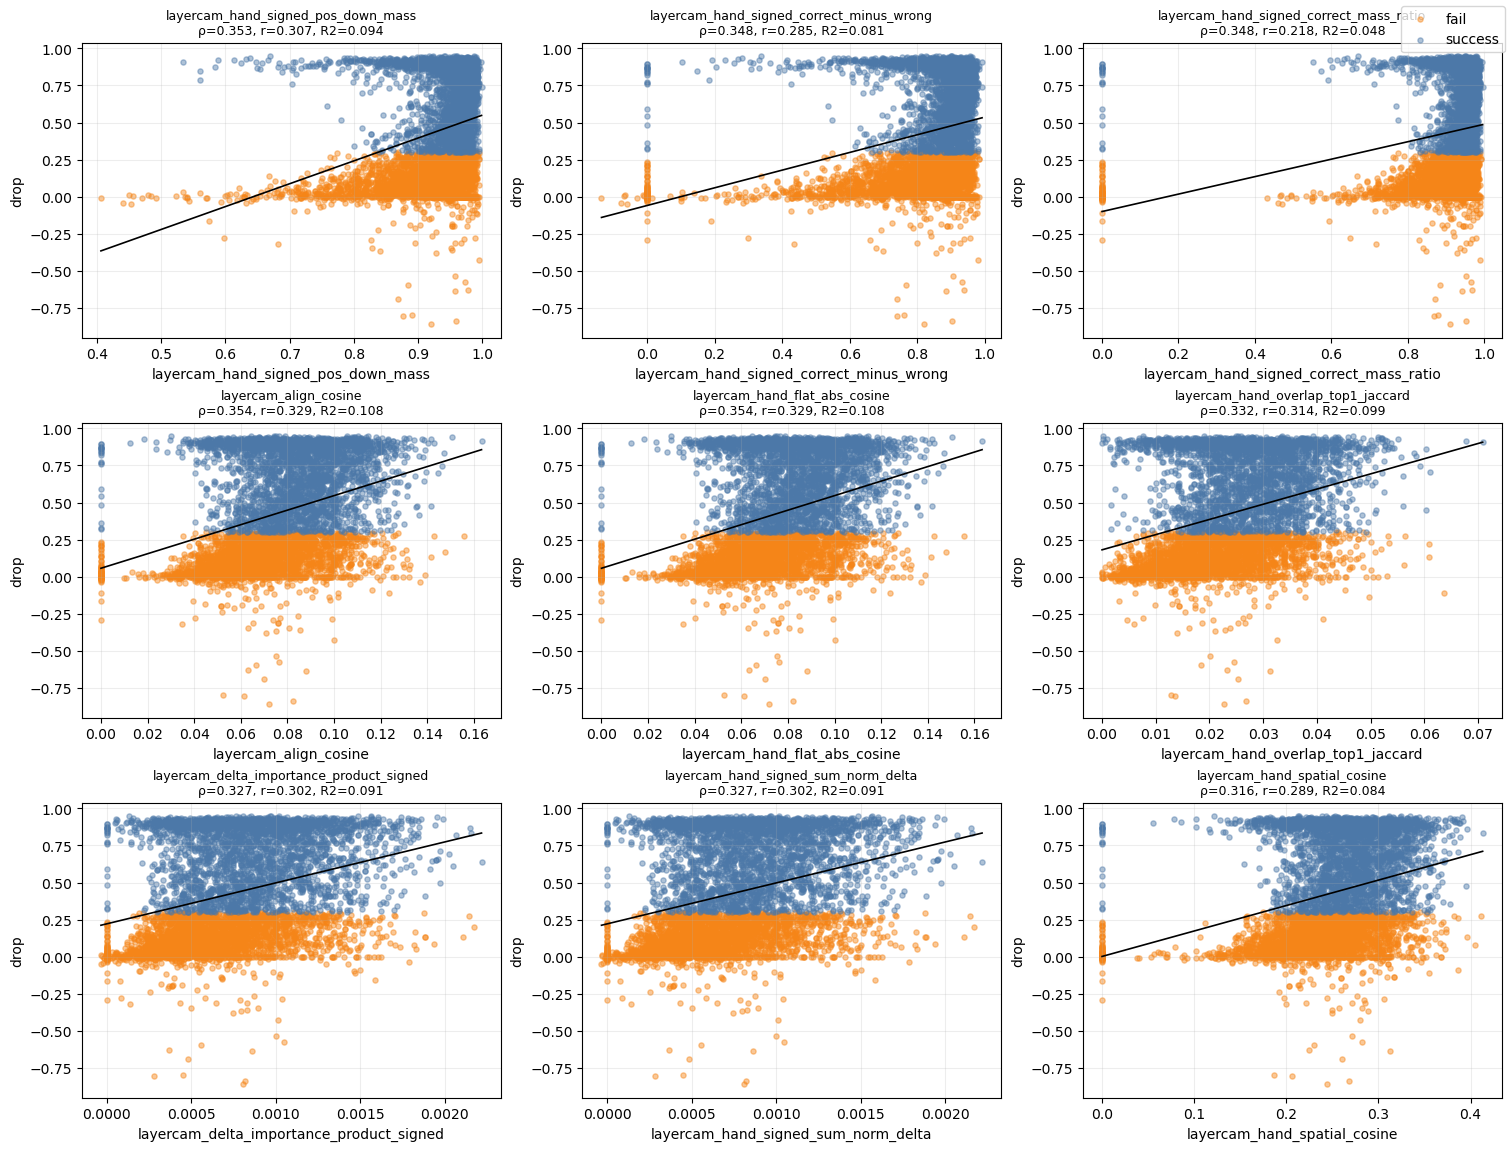

In [6]:
method = "layercam"
q = suite["quality_by_method"][method]
r = suite["regression_by_method"][method]
display(q.head(30))
for path in q.get("figure_path", pd.Series(dtype=str)).dropna().head(8):
    display(Image(filename=path))
display(r.head(30))
fig = regression_metrics.plot_similarity_score_bars(r.head(40), score_col="main_score")
plt.show()
fig = regression_metrics.plot_similarity_heatmap(r, top_n=30)
plt.show()
fig = regression_metrics.plot_top_metric_scatter(rows_df, r, target_col="drop", top_n=9)
plt.show()

## Full LayerIG / IG-ODAM-style

,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
0,full_layerig_hand_rank_top6_delta_frac,0.665317,0.637442,0.064475,1,new_experiments/outputs/patch_success_analysis...
1,full_layerig_delta_energy_importance_binfrac_006,0.675928,0.636203,0.007044,1,new_experiments/outputs/patch_success_analysis...
2,full_layerig_hand_rank_ratio_top5_top25,0.659198,0.634609,0.229309,1,new_experiments/outputs/patch_success_analysis...
3,full_layerig_hand_rank_top10_delta_frac,0.662072,0.634077,0.099771,1,new_experiments/outputs/patch_success_analysis...
4,full_layerig_delta_energy_importance_binfrac_004,0.658173,0.634077,0.008889,1,new_experiments/outputs/patch_success_analysis...
5,full_layerig_delta_energy_importance_binfrac_005,0.670307,0.633546,0.007931,1,new_experiments/outputs/patch_success_analysis...
6,full_layerig_delta_energy_in_importance_top,0.659522,0.633546,0.056708,1,new_experiments/outputs/patch_success_analysis...
7,full_layerig_hand_overlap_top5_delta_in_topA,0.659522,0.633546,0.056708,1,new_experiments/outputs/patch_success_analysis...
8,full_layerig_hand_rank_top5_delta_frac,0.659701,0.633369,0.056708,1,new_experiments/outputs/patch_success_analysis...
9,full_layerig_hand_overlap_top10_jaccard,0.659981,0.633015,0.054624,1,new_experiments/outputs/patch_success_analysis...


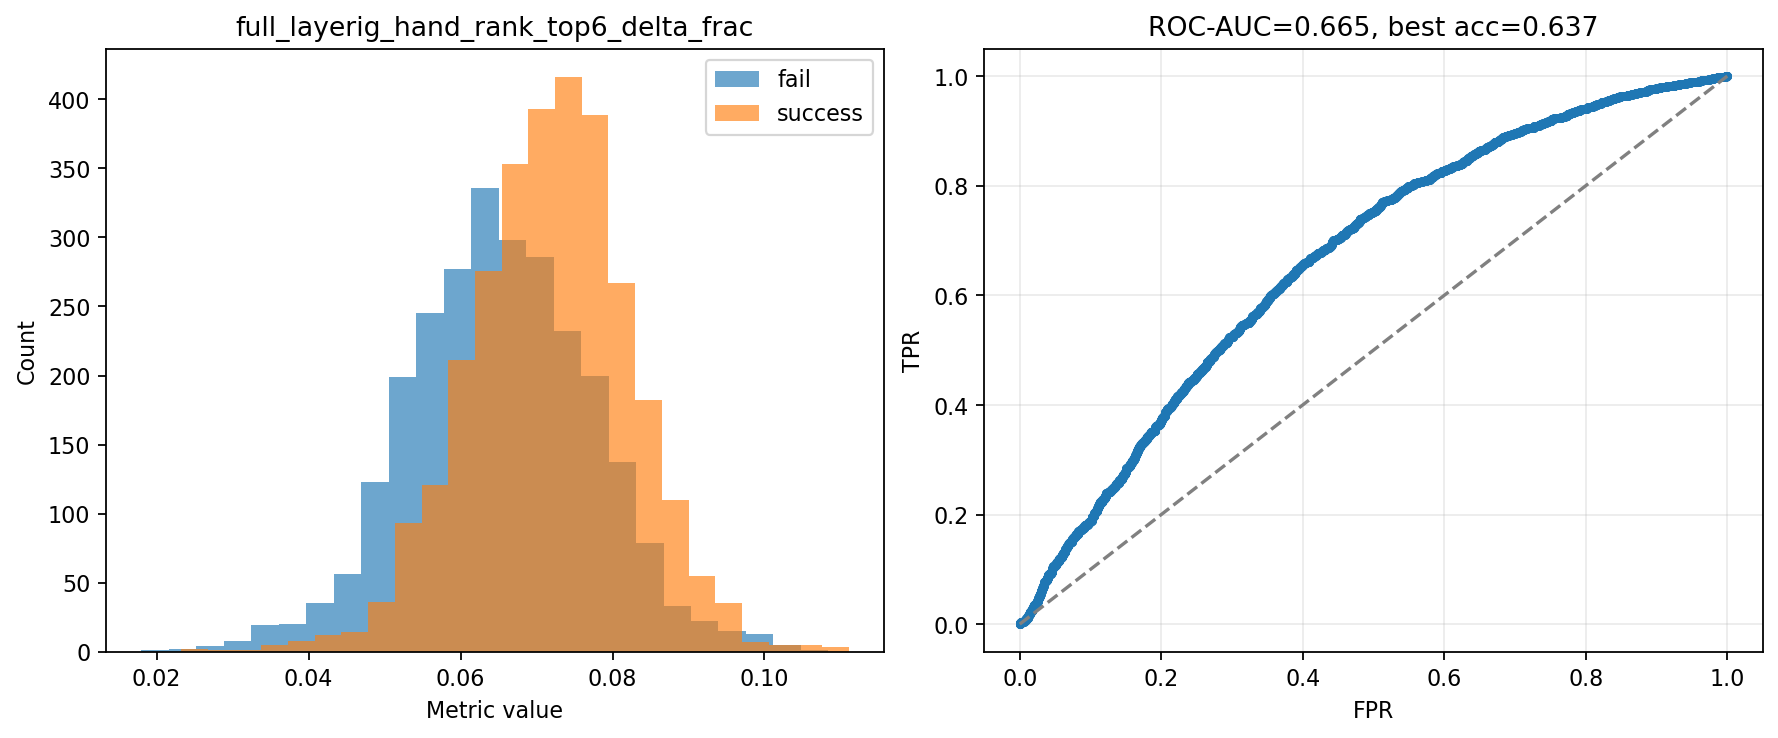

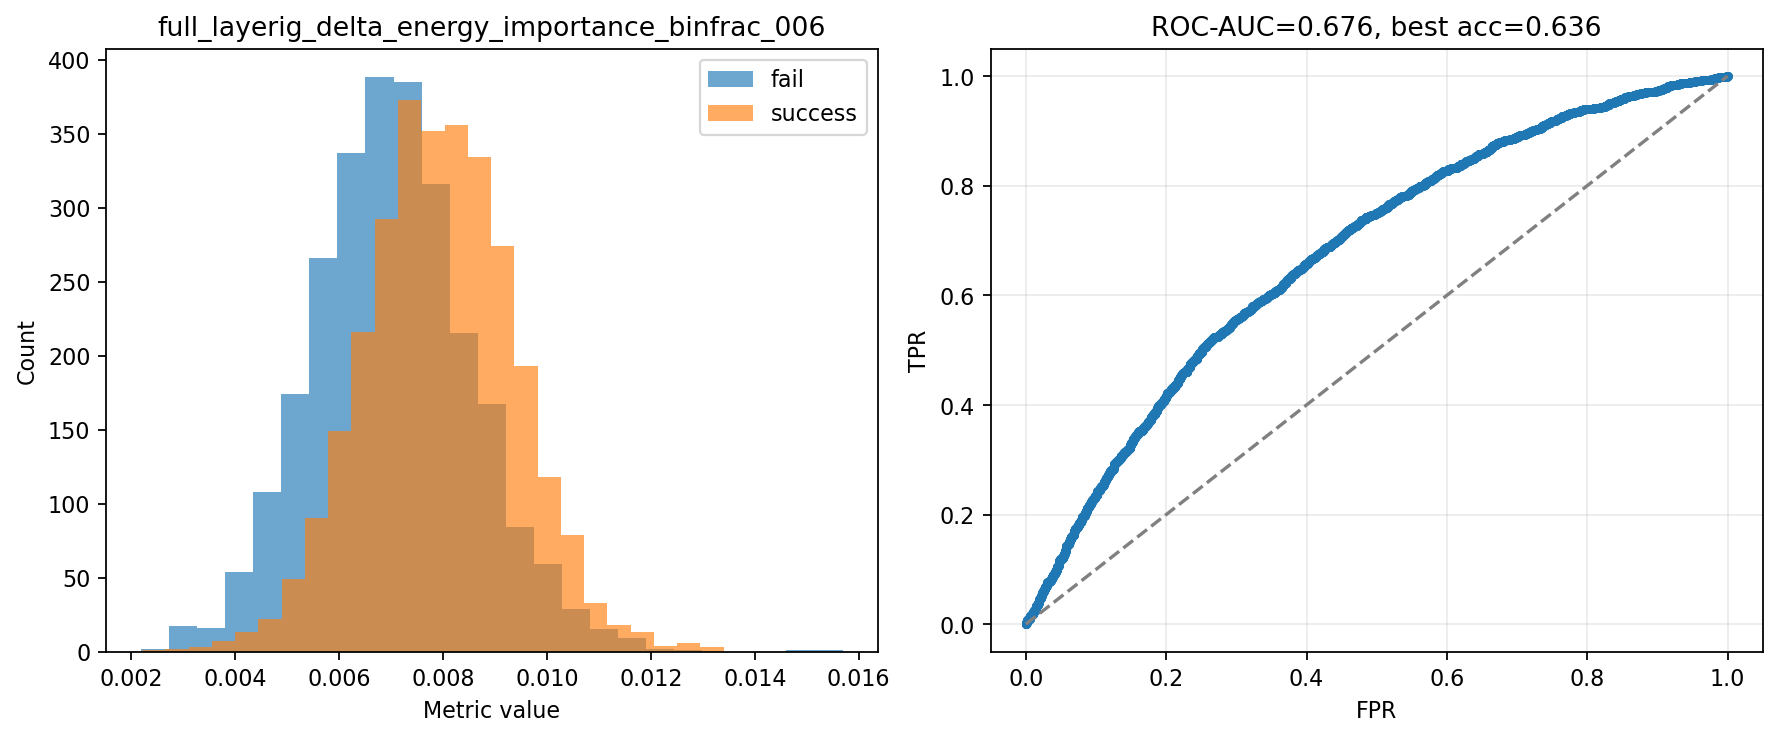

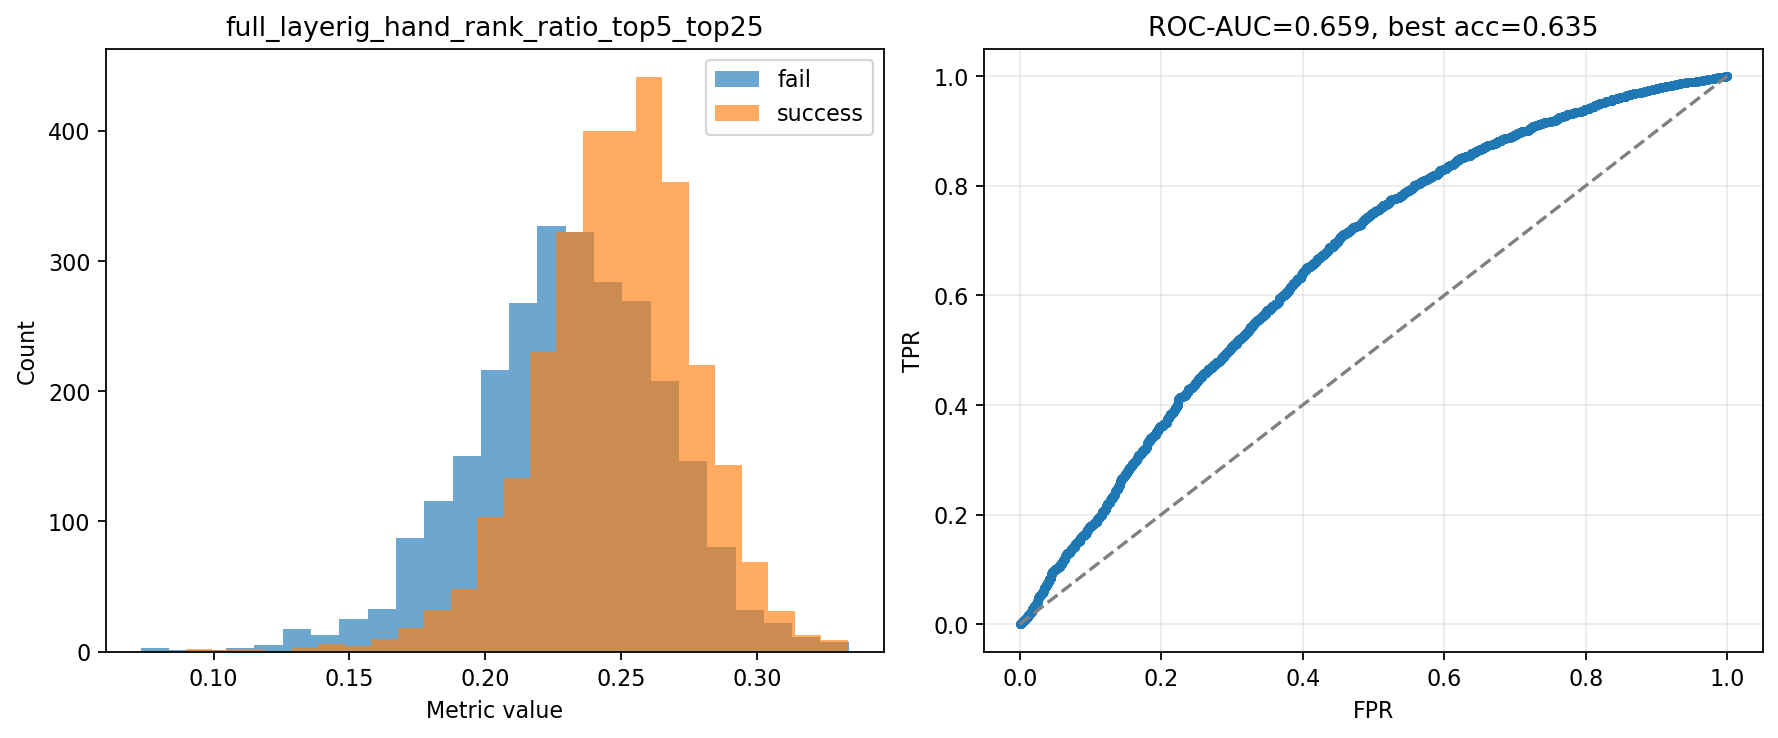

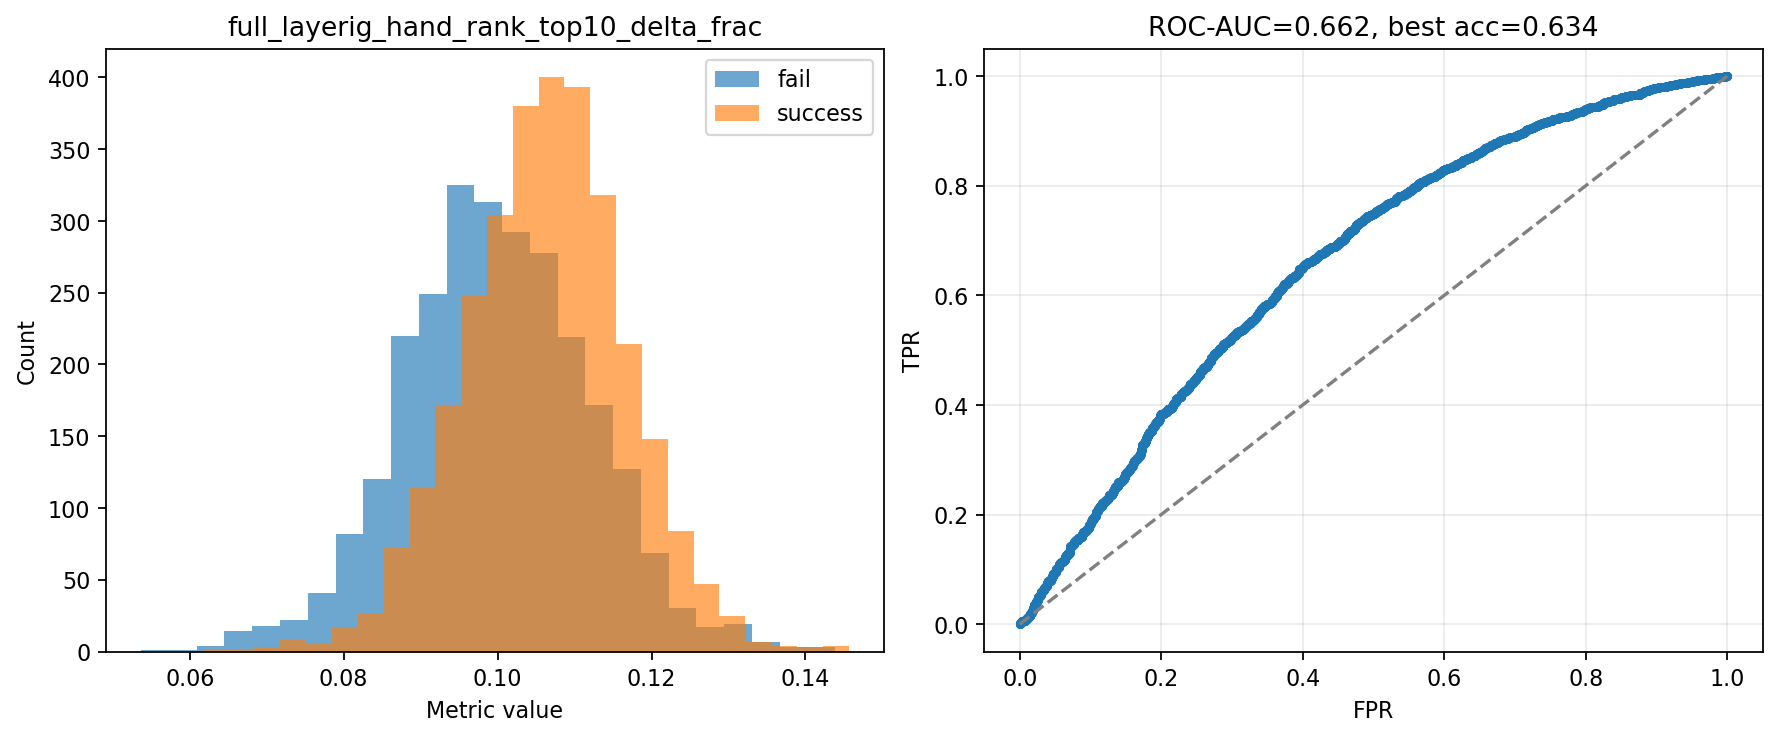

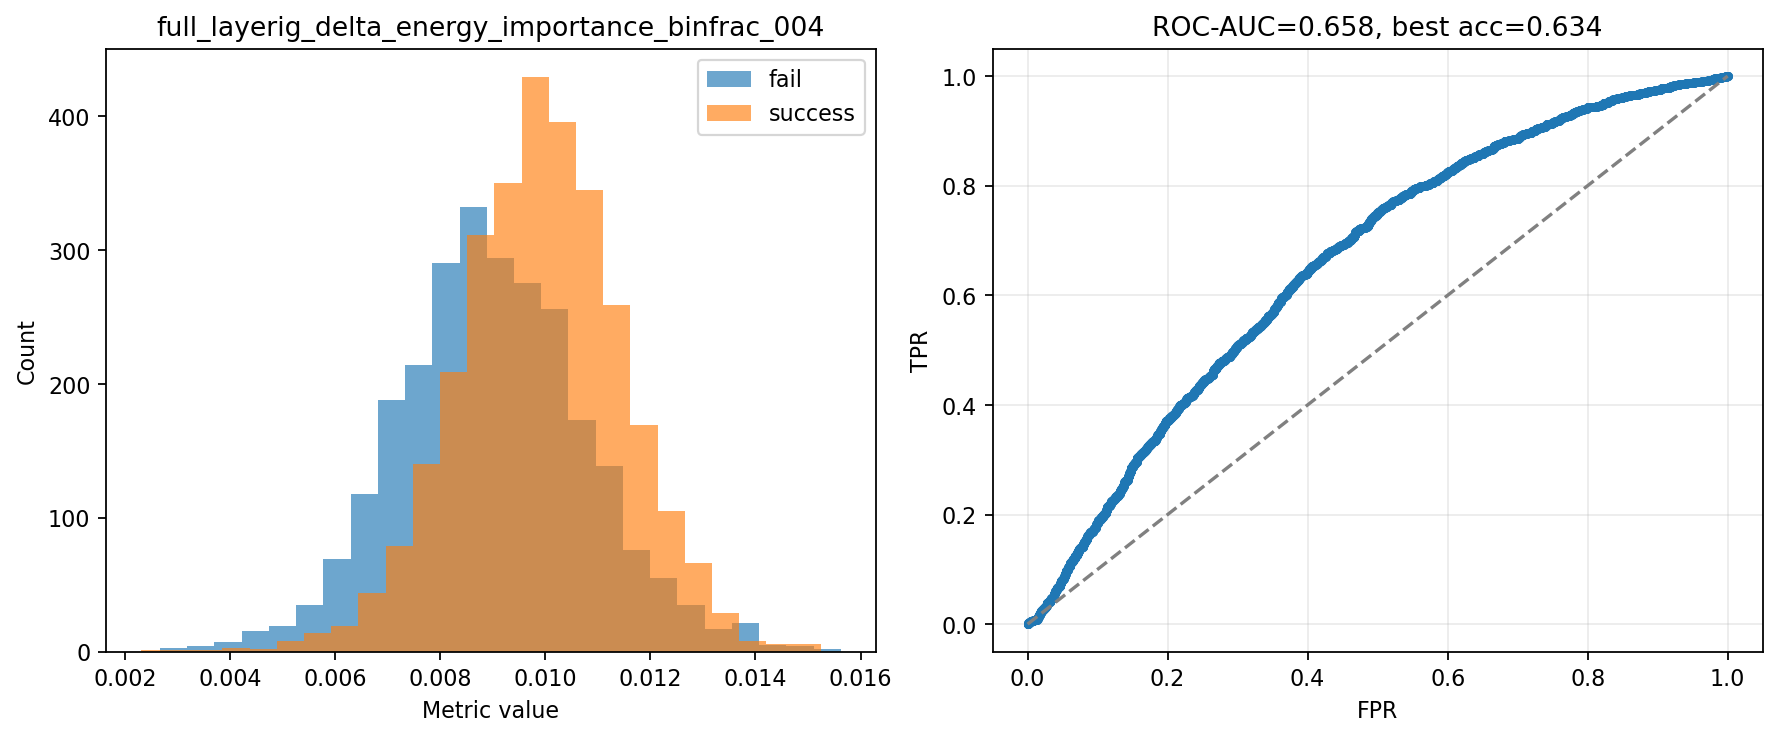

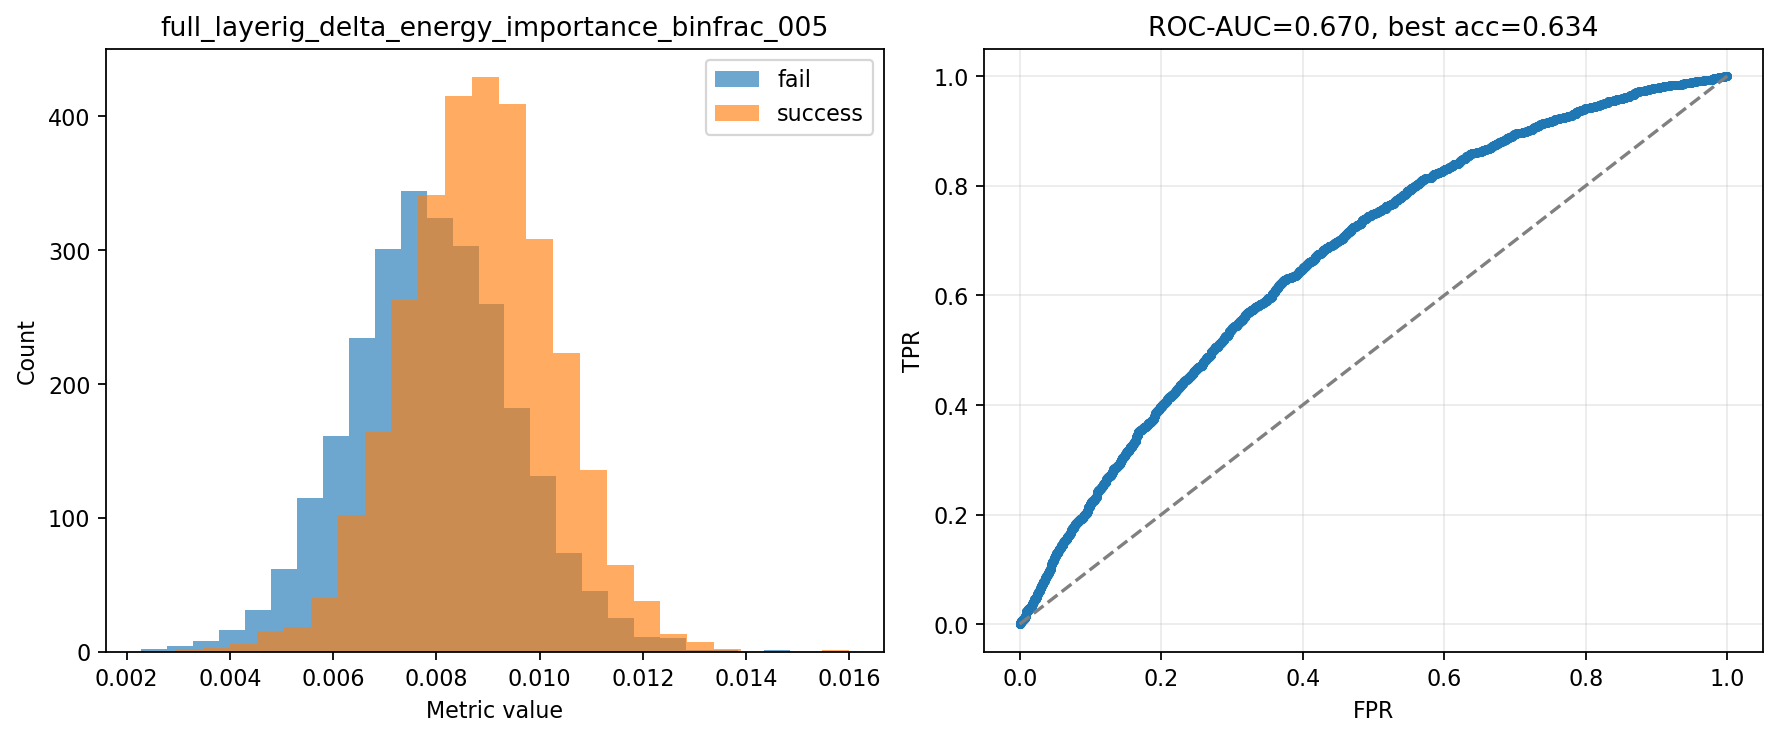

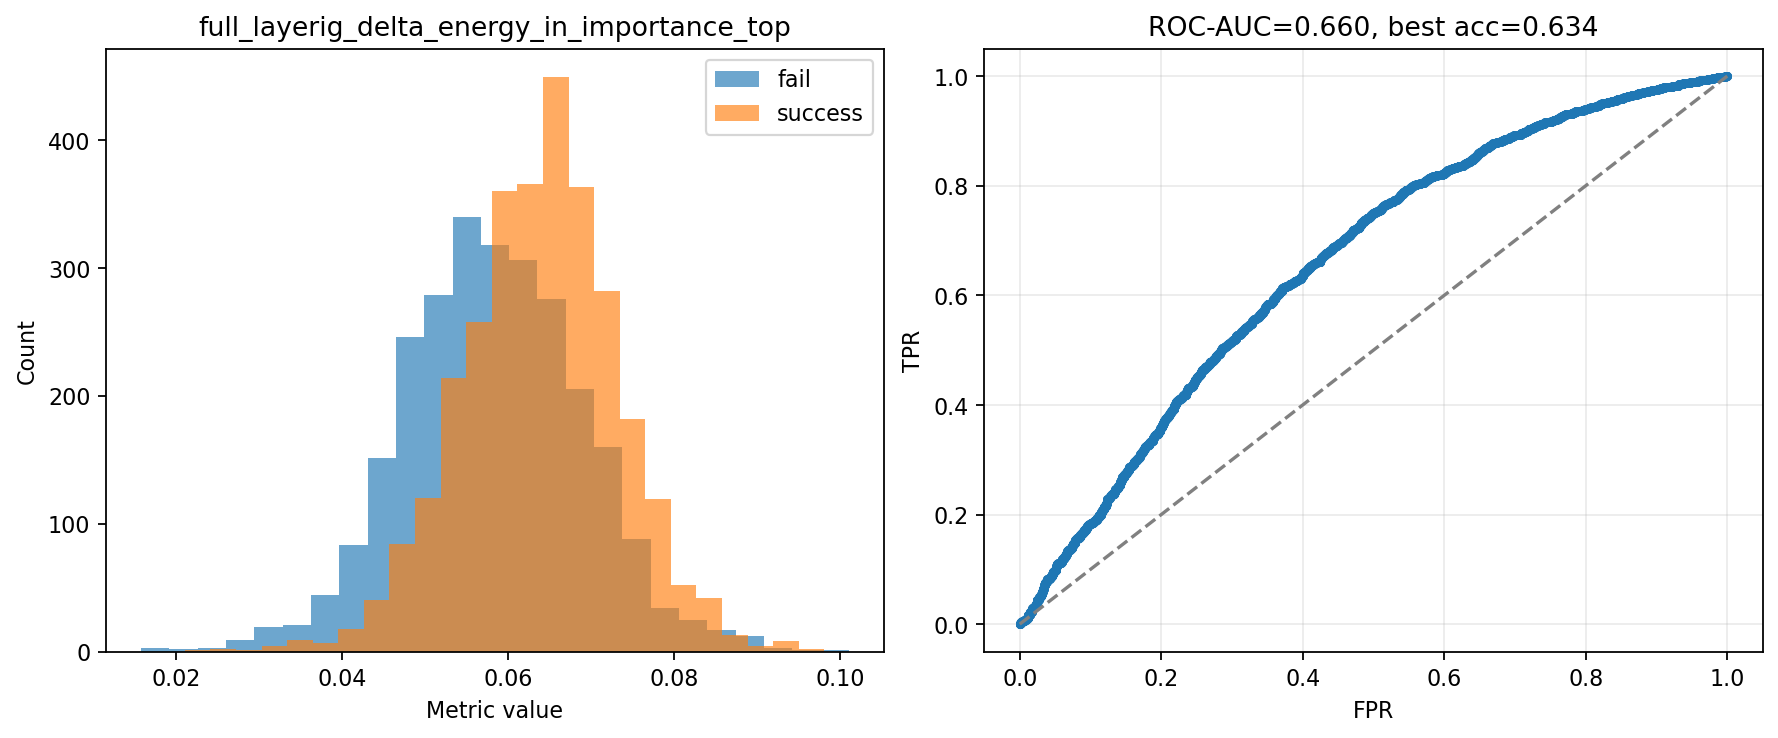

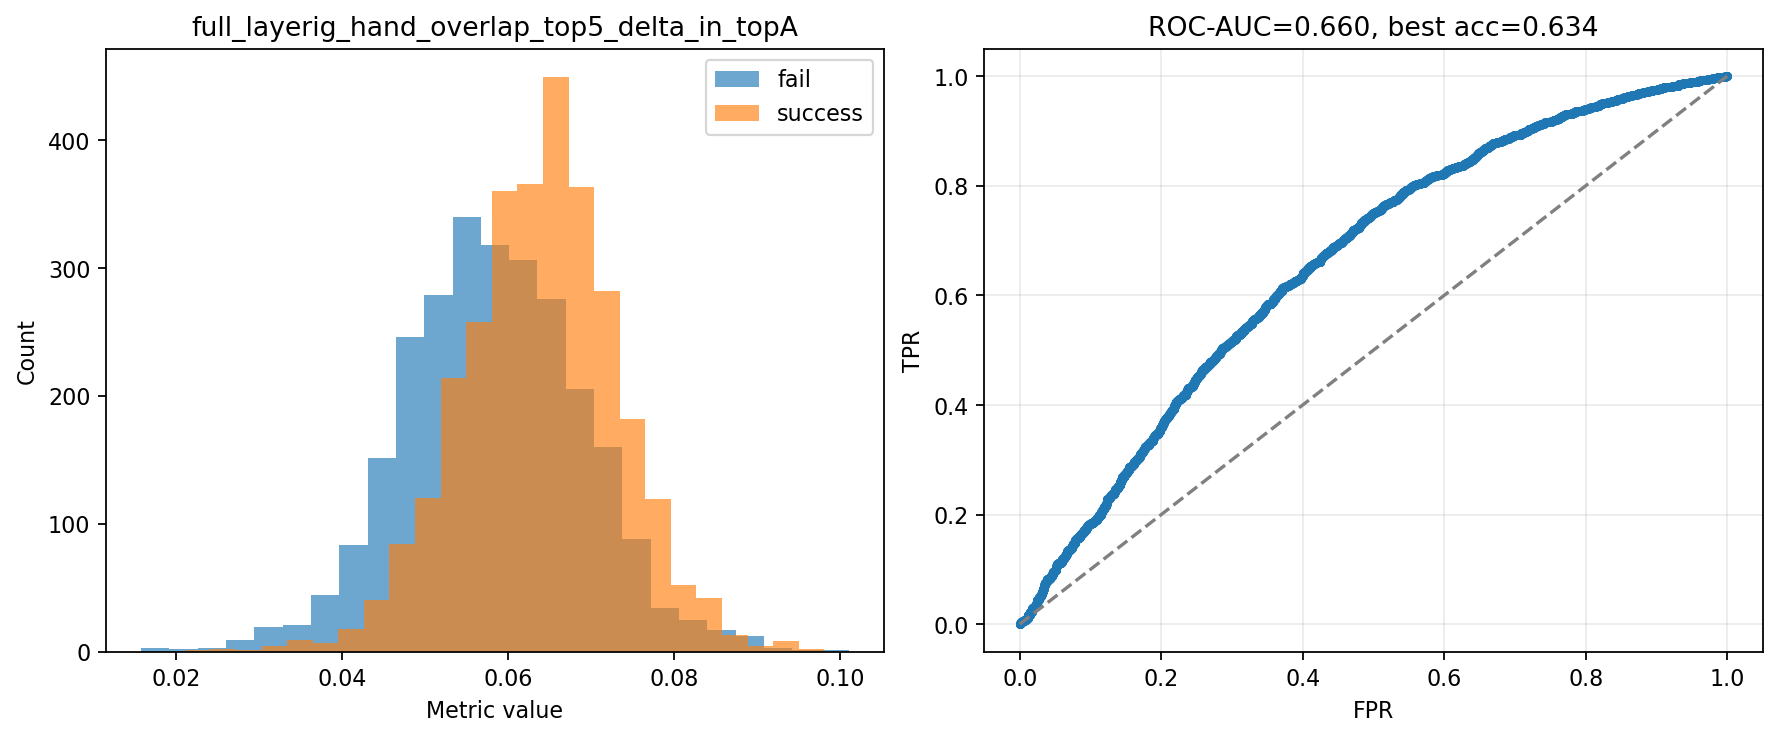

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,full_layerig_delta_energy_importance_binfrac_006,5646,1.0,0.267119,0.270477,0.188356,0.267119,0.270477,0.188356,0.126293,...,0.339241,58.380641,-0.006436,0.071353,0.283956,0.326885,0.963663,0.964579,0.509252,0.363994
1,full_layerig_delta_energy_importance_binfrac_005,5646,1.0,0.256944,0.254978,0.178293,0.256944,0.254978,0.178293,0.130931,...,0.339241,54.756720,-0.027088,0.066020,0.285309,0.327823,0.966426,1.000000,0.508537,0.360140
2,full_layerig_hand_rank_top10_delta_frac,5646,1.0,0.254343,0.260874,0.181973,0.254343,0.260874,0.181973,0.125415,...,0.339241,7.383447,-0.329864,0.064690,0.286599,0.328056,0.967114,0.957874,0.508359,0.352587
3,full_layerig_hand_rank_top6_delta_frac,5646,1.0,0.259384,0.266683,0.185929,0.259384,0.266683,0.185929,0.119874,...,0.339241,7.479272,-0.081343,0.067280,0.285954,0.327602,0.965774,0.915552,0.508705,0.350304
4,full_layerig_hand_overlap_top10_jaccard,5646,1.0,0.247103,0.252350,0.175808,0.247103,0.252350,0.175808,0.113827,...,0.339241,9.257342,-0.103574,0.061060,0.287405,0.328692,0.968989,0.869370,0.507875,0.337310
5,full_layerig_delta_energy_importance_binfrac_004,5646,1.0,0.232759,0.235629,0.165475,0.232759,0.235629,0.165475,0.119581,...,0.339241,45.407022,0.002055,0.054177,0.288707,0.329895,0.972534,0.913317,0.506962,0.336655
6,full_layerig_hand_overlap_top5_jaccard,5646,1.0,0.254062,0.263470,0.183309,0.254062,0.263470,0.183309,0.108862,...,0.339241,7.458932,0.114858,0.064547,0.287312,0.328081,0.967188,0.831447,0.508340,0.335575
7,full_layerig_align_top_jaccard,5646,1.0,0.254062,0.263470,0.183309,0.254062,0.263470,0.183309,0.108526,...,0.339241,7.458932,0.114858,0.064547,0.287312,0.328081,0.967188,0.828878,0.508340,0.335208
8,full_layerig_delta_energy_importance_binfrac_003,5646,1.0,0.246680,0.249015,0.173065,0.246680,0.249015,0.173065,0.112083,...,0.339241,45.182734,-0.056931,0.060851,0.287322,0.328729,0.969097,0.856049,0.507847,0.333098
9,full_layerig_hand_rank_ratio_top5_top25,5646,1.0,0.253700,0.255297,0.177965,0.253700,0.255297,0.177965,0.108088,...,0.339241,2.595221,-0.189685,0.064363,0.286933,0.328113,0.967283,0.825532,0.508315,0.331536


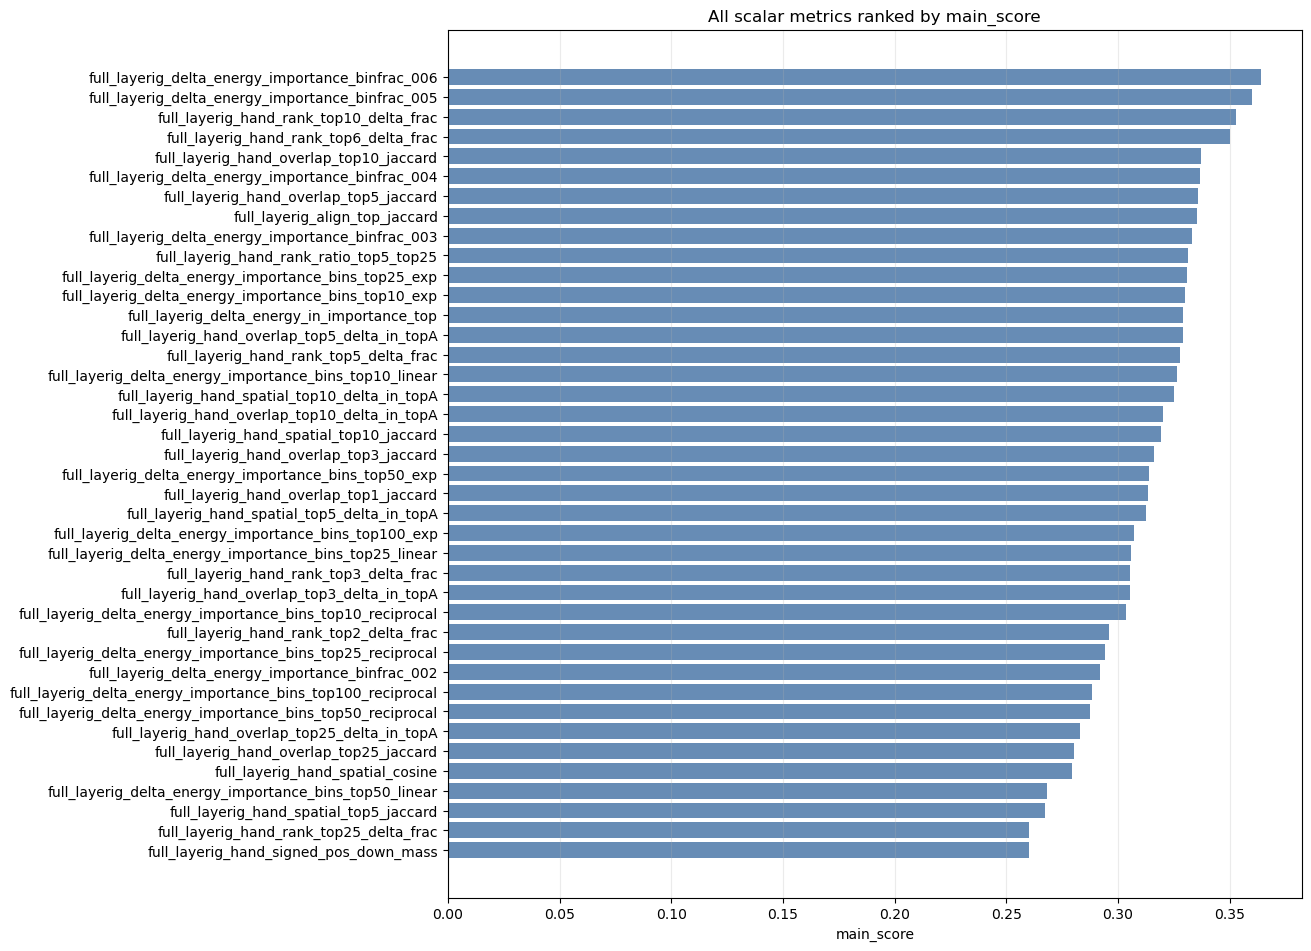

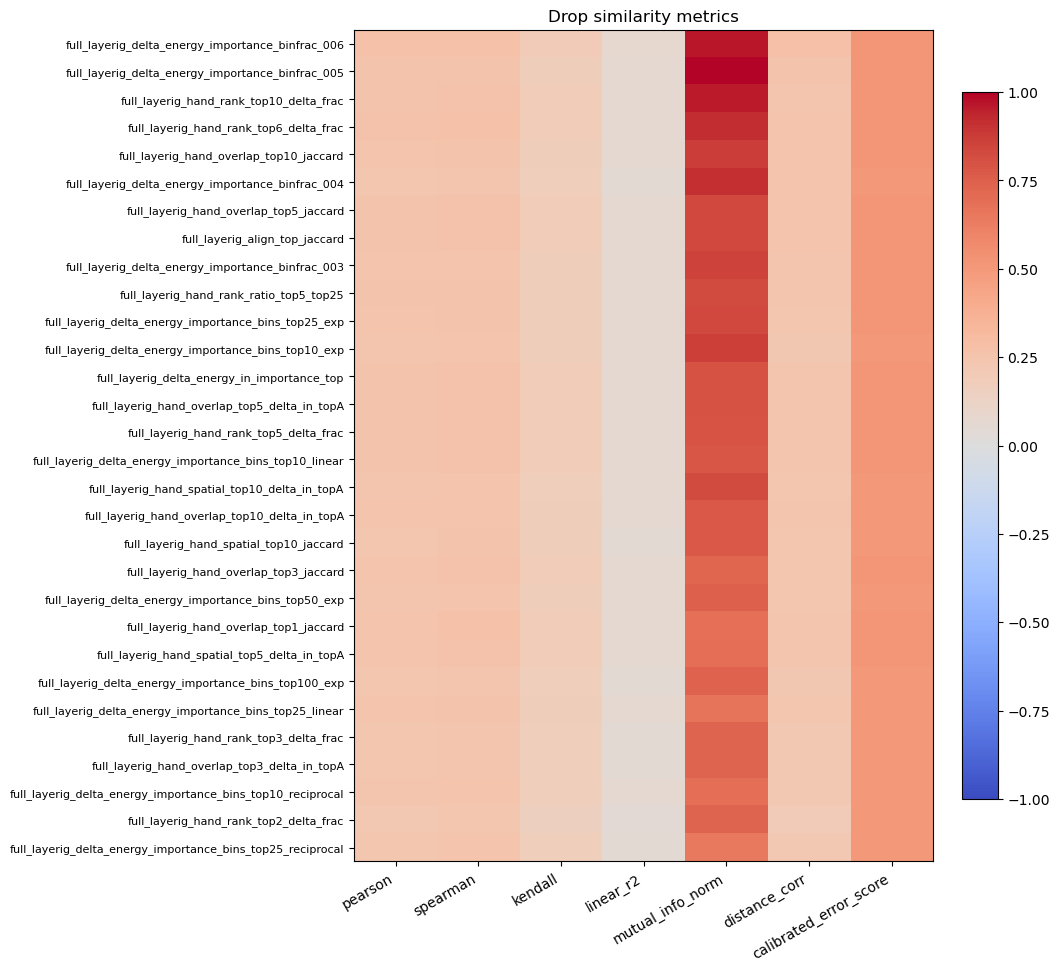

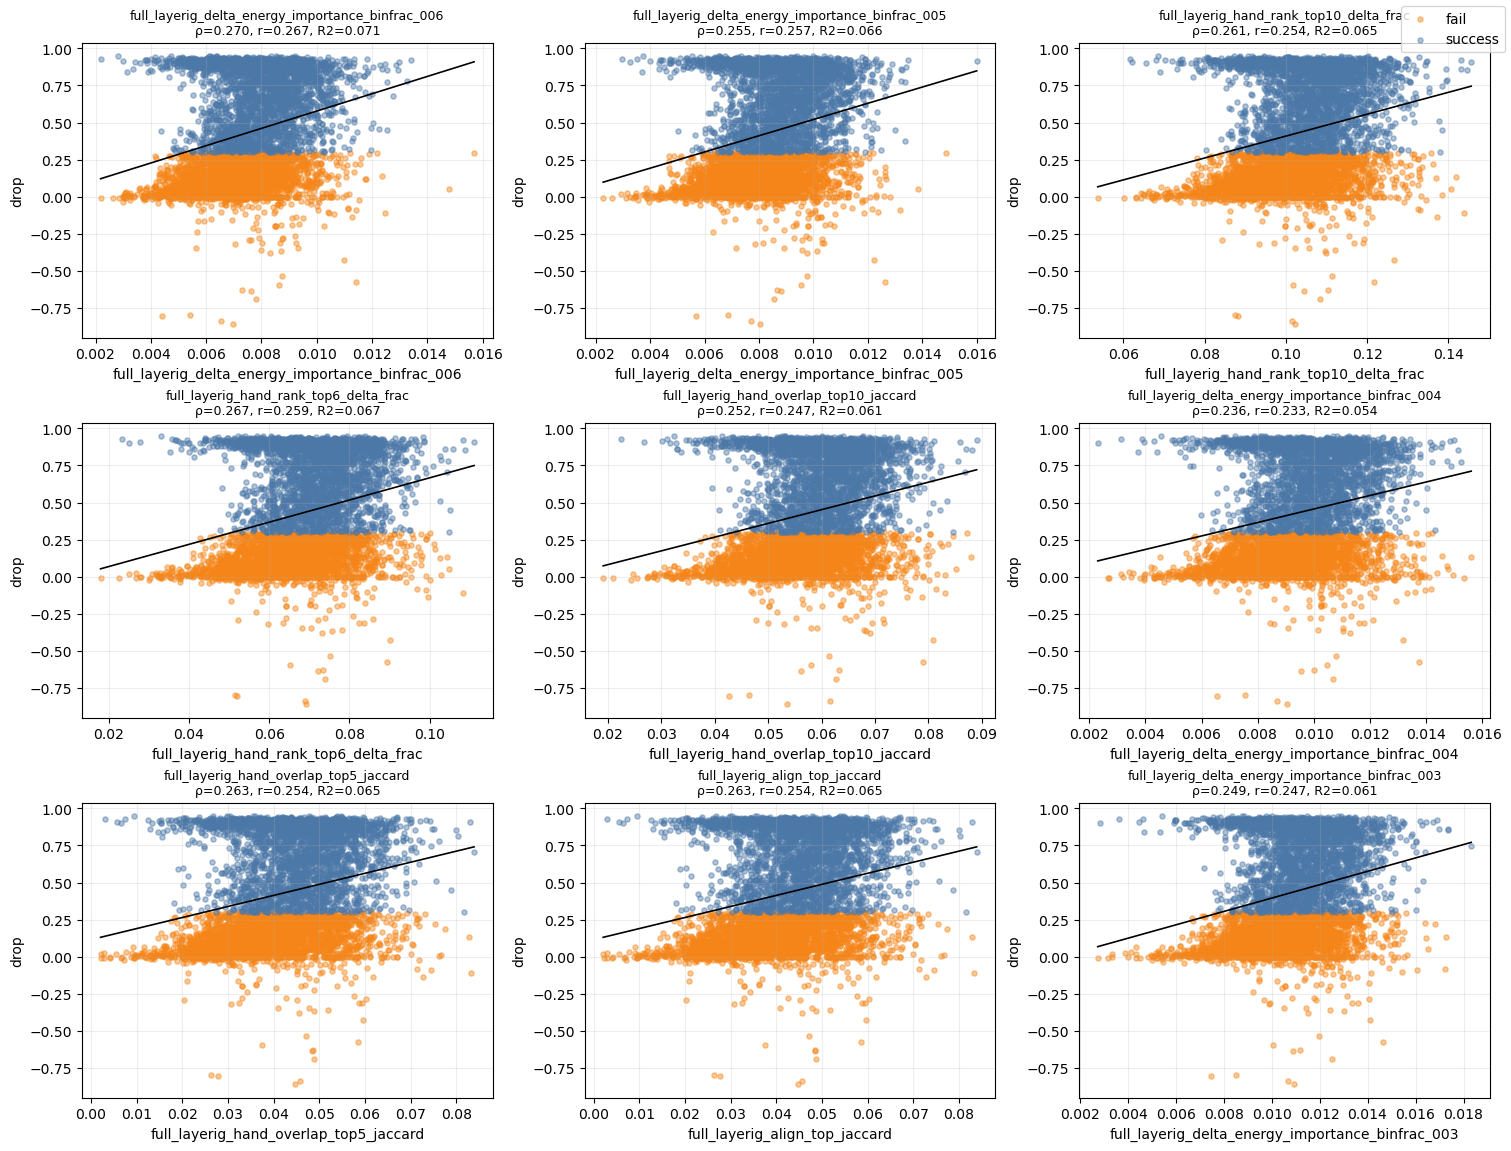

In [7]:
method = "full_layerig"
q = suite["quality_by_method"][method]
r = suite["regression_by_method"][method]
display(q.head(30))
for path in q.get("figure_path", pd.Series(dtype=str)).dropna().head(8):
    display(Image(filename=path))
display(r.head(30))
fig = regression_metrics.plot_similarity_score_bars(r.head(40), score_col="main_score")
plt.show()
fig = regression_metrics.plot_similarity_heatmap(r, top_n=30)
plt.show()
fig = regression_metrics.plot_top_metric_scatter(rows_df, r, target_col="drop", top_n=9)
plt.show()

## Overall: лучшие classification метрики

,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path,method
0,layercam_hand_signed_correct_minus_wrong,0.713254,0.673220,0.851913,1,new_experiments/outputs/patch_success_analysis...,layercam
1,layercam_hand_signed_correct_mass_ratio,0.713233,0.673220,0.925957,1,new_experiments/outputs/patch_success_analysis...,layercam
2,layercam_hand_signed_pos_down_mass,0.717315,0.671277,0.931727,1,new_experiments/outputs/patch_success_analysis...,layercam
3,layercam_align_cosine,0.703595,0.661176,0.074093,1,new_experiments/outputs/patch_success_analysis...,layercam
4,layercam_hand_flat_abs_cosine,0.703595,0.661176,0.074093,1,new_experiments/outputs/patch_success_analysis...,layercam
5,odam_align_cosine,0.698937,0.659051,0.095622,1,new_experiments/outputs/patch_success_analysis...,odam
6,odam_hand_flat_abs_cosine,0.698937,0.659051,0.095622,1,new_experiments/outputs/patch_success_analysis...,odam
7,layercam_hand_overlap_top1_jaccard,0.689302,0.647538,0.019793,1,new_experiments/outputs/patch_success_analysis...,layercam
8,odam_hand_overlap_top1_jaccard,0.683918,0.647361,0.027210,1,new_experiments/outputs/patch_success_analysis...,odam
9,odam_hand_spatial_cosine,0.682482,0.646298,0.245820,1,new_experiments/outputs/patch_success_analysis...,odam


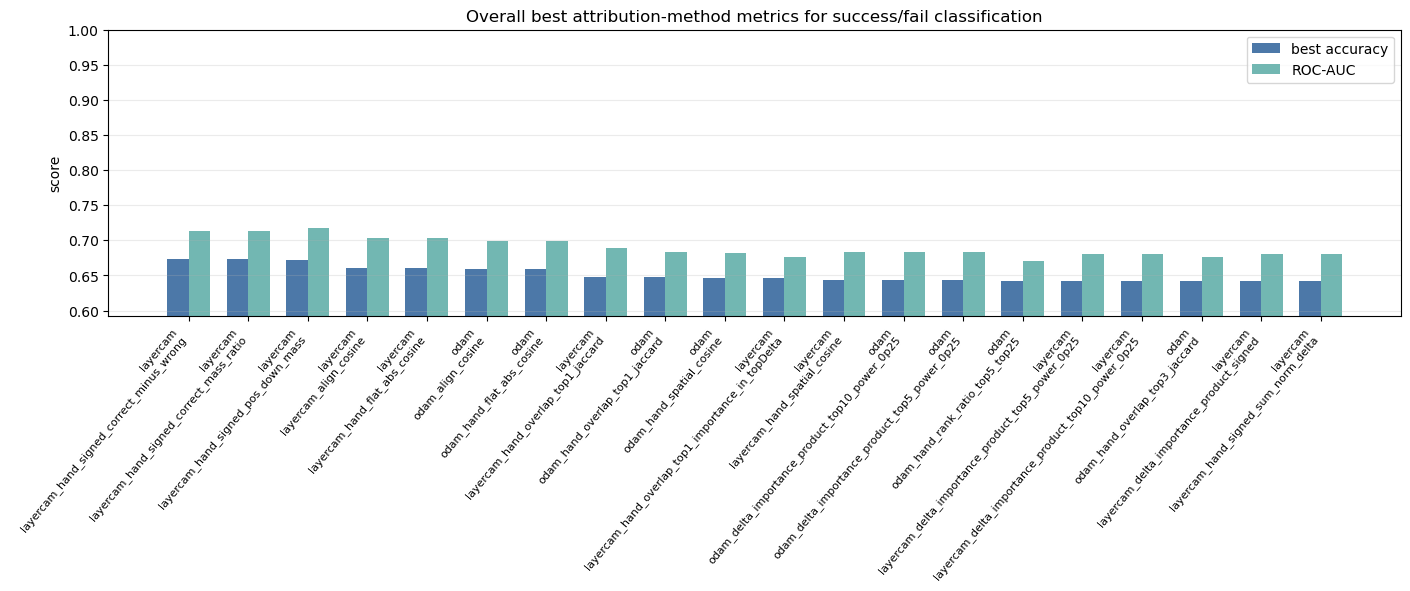

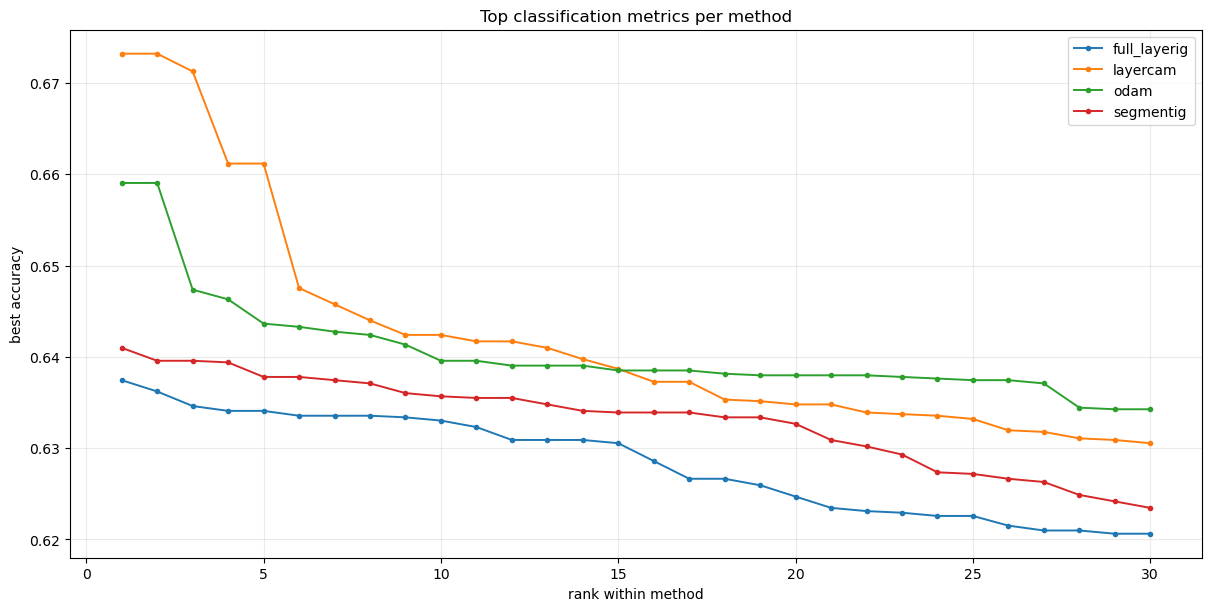

In [8]:
display(all_quality.head(50))
fig = attribution_suite.plot_method_classification_summary(all_quality, top_n=20)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
for method, sub in all_quality.groupby("method"):
    sub = sub.sort_values("best_accuracy", ascending=False).head(30).reset_index(drop=True)
    ax.plot(range(1, len(sub) + 1), sub["best_accuracy"], marker="o", linewidth=1.4, markersize=3, label=method)
ax.set_title("Top classification metrics per method")
ax.set_xlabel("rank within method")
ax.set_ylabel("best accuracy")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Overall: лучшие regression/drop метрики

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score,method
0,layercam_hand_signed_pos_down_mass,5567,0.986008,0.307226,0.352504,0.251071,0.307226,0.352504,0.251071,0.164236,...,1.541608,-0.991712,0.094388,0.280148,0.322070,0.951636,0.943461,0.512390,0.402989,layercam
1,layercam_hand_signed_correct_minus_wrong,5646,1.000000,0.284964,0.348021,0.247594,0.284964,0.348021,0.247594,0.174078,...,0.596410,-0.059493,0.081205,0.285579,0.325147,0.958538,1.000000,0.510585,0.398201,layercam
2,odam_align_cosine,5646,1.000000,0.318566,0.341009,0.238360,0.318566,0.341009,0.238360,0.122455,...,3.837077,0.054440,0.101484,0.278764,0.321539,0.947901,0.875268,0.513373,0.386759,odam
3,odam_hand_flat_abs_cosine,5646,1.000000,0.318566,0.341009,0.238360,0.318566,0.341009,0.238360,0.122451,...,3.837077,0.054440,0.101484,0.278764,0.321539,0.947901,0.875235,0.513373,0.386754,odam
4,layercam_hand_signed_correct_mass_ratio,5646,1.000000,0.218044,0.347963,0.247545,0.218044,0.347963,0.247545,0.174076,...,0.588602,-0.100344,0.047543,0.295597,0.331049,0.975939,0.999984,0.506089,0.380336,layercam
5,layercam_align_cosine,5646,1.000000,0.328620,0.353633,0.247669,0.328620,0.353633,0.247669,0.121697,...,4.899369,0.056736,0.107991,0.277355,0.320372,0.944462,0.699096,0.514281,0.368937,layercam
6,layercam_hand_flat_abs_cosine,5646,1.000000,0.328620,0.353633,0.247669,0.328620,0.353633,0.247669,0.121688,...,4.899369,0.056736,0.107991,0.277355,0.320372,0.944462,0.699043,0.514281,0.368930,layercam
7,odam_hand_overlap_top1_jaccard,5646,1.000000,0.300530,0.321203,0.224396,0.300530,0.321203,0.224396,0.115873,...,7.025360,0.207993,0.090318,0.281592,0.323530,0.953772,0.828217,0.511830,0.367393,odam
8,odam_hand_rank_ratio_top5_top25,5646,1.000000,0.270616,0.272667,0.190746,0.270616,0.272667,0.190746,0.139906,...,2.747109,-0.192590,0.073233,0.284139,0.326554,0.962687,1.000000,0.509506,0.367107,odam
9,odam_delta_importance_product_top10_power_0p25,5646,1.000000,0.294288,0.316332,0.220063,0.294288,0.316332,0.220063,0.117567,...,23.529460,0.010827,0.086605,0.283066,0.324190,0.955717,0.840328,0.511321,0.365542,odam


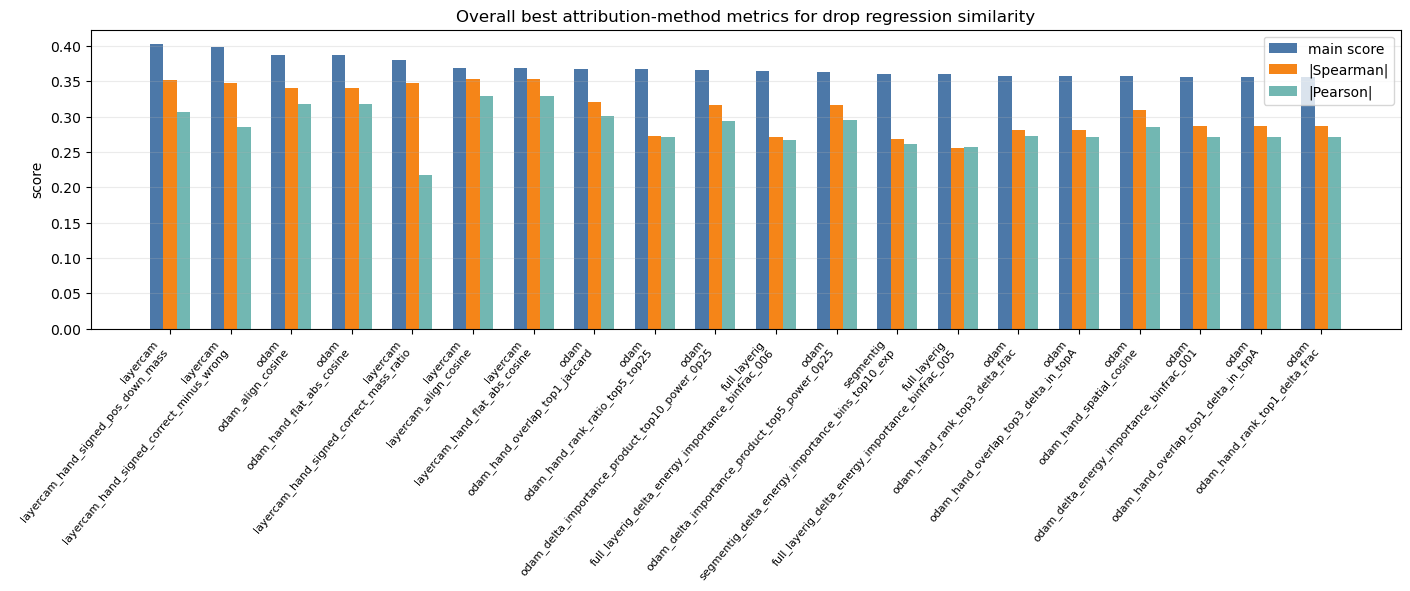

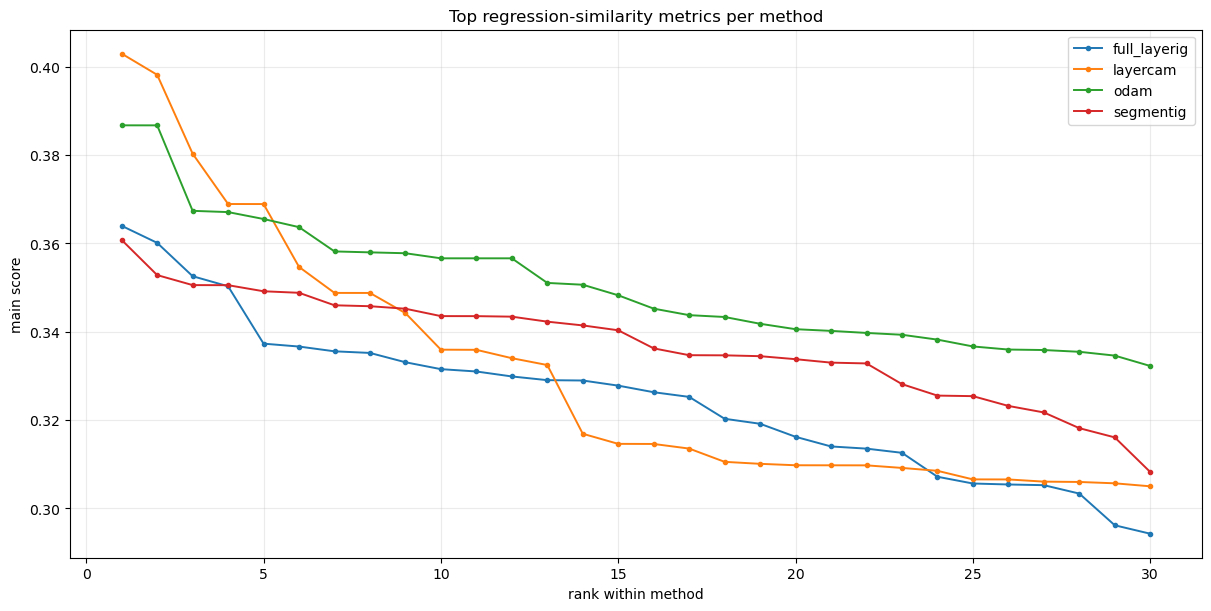

In [9]:
display(all_regression.head(50))
fig = attribution_suite.plot_method_regression_summary(all_regression, top_n=20)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
for method, sub in all_regression.groupby("method"):
    sub = sub.sort_values("main_score", ascending=False).head(30).reset_index(drop=True)
    ax.plot(range(1, len(sub) + 1), sub["main_score"], marker="o", linewidth=1.4, markersize=3, label=method)
ax.set_title("Top regression-similarity metrics per method")
ax.set_xlabel("rank within method")
ax.set_ylabel("main score")
ax.grid(alpha=0.25)
ax.legend()
plt.show()